In [1]:
import os

#add the root directory
os.chdir('../')

# Supplementary material S3.8: A posteriori simulations using tabulation

Normalize all trajectories with PVs ranging from 0 to 1

In [2]:
import numpy as np
import pandas as pd
from ANN_regression import *
import pickle
from datetime import datetime
from loader import *
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D
import h5py
from sklearn.metrics import mean_squared_error
from scipy.integrate import odeint
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator
from matplotlib.patches import Rectangle
import matplotlib.cm as cm
import matplotlib.lines as mlines
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from matplotlib.legend_handler import HandlerBase

### Load the data

In [3]:
filename_autoignition = "isochoric-adiabatic-closed-HR-H2-air-lin_Z_0.015_0.035_100-T0_900-"
path_data_autoignition = "data-files/autoignition/"
path_data = "data-files/"

#create all the datasets
mixture_fractions_train = np.loadtxt(f"{path_data_autoignition}{filename_autoignition}mixture-fraction.csv") #1 x nbr_timesteps
mixture_fractions_test = np.loadtxt(f"{path_data_autoignition}{filename_autoignition}mixture-fractions-test-trajectories.csv") #1 x nbr_test_trajectories
state_space_names = np.genfromtxt(f"{path_data_autoignition}{filename_autoignition}state-space-names.csv", delimiter=",", dtype=str)
state_space_train = pd.read_csv(f"{path_data_autoignition}{filename_autoignition}state-space.csv", names = state_space_names)
state_space_source_train = pd.read_csv(f"{path_data_autoignition}{filename_autoignition}state-space-sources.csv", names = state_space_names)
time_train = np.loadtxt(f"{path_data_autoignition}{filename_autoignition}time.csv") #1 x nbr_timesteps

In [4]:
PV_Xu_train = state_space_train["H2O"] - state_space_train["H2"] - state_space_train["O2"]

PV_Xu_train = PV_Xu_train.to_numpy().reshape(-1,1)
PV_Xu_source_train = state_space_source_train["H2O"] - state_space_source_train["H2"] - state_space_source_train["O2"]
PV_Xu_source_train = PV_Xu_source_train.to_numpy().reshape(-1,1)

In [5]:
# Rescale every trajectory from 0 to 1 (each having its own mixture fraction)

df = pd.DataFrame({
    'PV Xu': PV_Xu_train.squeeze(),
    'mixture_fraction': mixture_fractions_train
})

# Normalize PV within each mixture_fraction group
df['PV_Xu_scaled'] = df.groupby('mixture_fraction')['PV Xu'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0.0
)

# Get the PV back to numpy
PV_Xu_scaled = df['PV_Xu_scaled'].to_numpy()

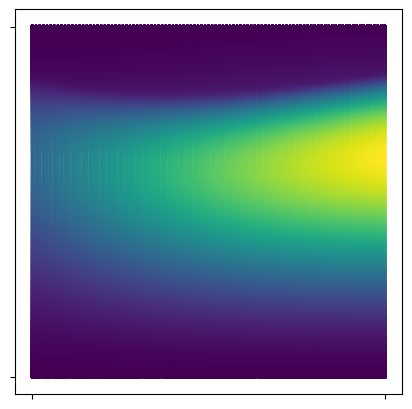

In [6]:
save = False
scaled = True
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/f-PV manifold/"
name = f"Heuristic PV - {'Scaled ' if scaled else ''} f-PV manifold - PV source as color - PRESENTATION - v2"

PV_data = (PV_Xu_train - PV_Xu_train.min())/(PV_Xu_train.max() - PV_Xu_train.min())
if(scaled):
    PV_data = PV_Xu_scaled

fig, ax = plt.subplots(figsize = (5, 5))
# Ensure the the processing has been done correctly
plt.scatter(mixture_fractions_train, PV_data, c=PV_Xu_source_train, s=3)
# cbar = plt.colorbar()
# cbar.set_ticks([0, 100000])
# cbar.ax.tick_params(labelsize = 12)
# cbar.set_label(r'$\dot{\omega}_{PV} / \rho$ [1/s]', fontsize=17, labelpad = -7)
# class CustomScalarFormatter(ScalarFormatter):
#     def __init__(self, useOffset=True, useMathText=False):
#         super().__init__(useOffset=useOffset, useMathText=useMathText)

#     def __call__(self, x, pos=None):
#         # If the value is zero, format it as "0" instead of "0.00"
#         if x == 0:
#             return "0"
#         else:
#             return super().__call__(x, pos)

# formatter2 = CustomScalarFormatter(useMathText=True)
# formatter2.set_powerlimits((0, 0))
# cbar.ax.yaxis.set_major_formatter(formatter2)
# offset_text = cbar.ax.yaxis.get_offset_text()
# offset_text.set_x(offset_text.get_position()[0] + 0.5)
#plt.xlabel("f [\u2014]", fontsize = 20, labelpad=-13)
plt.xticks([0.015, 0.035], fontsize = 15)
ax.set_xticklabels([])
plt.yticks([0, 1], fontsize = 15)
if(not scaled):
    plt.ylabel("Heuristic PV [\u2014]", fontsize = 20, labelpad=-13)
else:
    ax.set_yticklabels([])
if(save):
    plt.savefig(pathSave + name, dpi = 300, bbox_inches = "tight")
plt.show()

## Tabulation method

In [7]:
def get_PVsource_in_mask(mf_data, mf_limit, PV_target, PV_data, PV_source_data):

    mask_mf_around_target = (mf_data == mf_limit)

    PV_source_mask = PV_source_data[mask_mf_around_target]

    PV_mask = PV_data[mask_mf_around_target]

    PV_lower_than_target_mask = PV_mask[PV_mask < PV_target]

    boolNoBelow = False
    boolNoAbove = False

    if PV_lower_than_target_mask.size > 0:
        PV_max_lower_mask = PV_lower_than_target_mask.max()
        idx_lowPV_in_mask = np.where(PV_mask == PV_max_lower_mask)[0][0]
        #print(f"idx below {idx_lowPV_in_mask} and PVsource {PV_source_mask[idx_lowPV_in_mask]} and PV {PV_max_lower_mask}")
    else:
        boolNoBelow = True

    PV_larger_than_target_mask = PV_mask[PV_mask > PV_target]

    if PV_larger_than_target_mask.size > 0:
        PV_min_higher_mask = PV_larger_than_target_mask.min()
        idx_highPV_in_mask = np.where(PV_mask == PV_min_higher_mask)[0][0]
        #print(f"idx high {idx_highPV_in_mask} and PVsource {PV_source_mask[idx_highPV_in_mask]} and PV {PV_min_higher_mask}")
    else:
        boolNoAbove = True

    if(boolNoBelow and boolNoAbove):
        raise ValueError("No PV above or below.")
    elif(boolNoBelow):
        PVsource_on_mf = PV_source_mask[idx_highPV_in_mask]
    elif(boolNoAbove):
        PVsource_on_mf = PV_source_mask[idx_lowPV_in_mask]
    else:
        PVsource_on_mf = (PV_source_mask[idx_highPV_in_mask] - PV_source_mask[idx_lowPV_in_mask])/(PV_min_higher_mask - PV_max_lower_mask) * (PV_target - PV_max_lower_mask) + PV_source_mask[idx_lowPV_in_mask]

    #print(PVsource_on_mf)
    
    return PVsource_on_mf

def predict_PVsource(mf_target, PV_target, mf_data, PV_data, PVsource_data):
    unique_mf = np.unique(mf_data)
    less_than_maf_target = unique_mf[unique_mf < mf_target]
    largest_mf_below = less_than_maf_target.max() if less_than_maf_target.size > 0 else None

    greater_than_mf_target = unique_mf[unique_mf > mf_target]
    smallest_mf_above = greater_than_mf_target.min() if greater_than_mf_target.size > 0 else None

    #print("left mf trajectory")
    PVsource_on_mf1 = get_PVsource_in_mask(mf_data, largest_mf_below, PV_target, PV_data, PVsource_data)
    #print("right mf trajectory")
    PVsource_on_mf2 = get_PVsource_in_mask(mf_data, smallest_mf_above, PV_target, PV_data, PVsource_data)

    PVsource_predicted = (PVsource_on_mf2 - PVsource_on_mf1)/(smallest_mf_above - largest_mf_below) * (mf_target - largest_mf_below) + PVsource_on_mf1

    return PVsource_predicted

In [8]:
prediction_test_trajectories = []

for i in range(10):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_Xu_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
        PV_Xu_test = PV_Xu_test.to_numpy().reshape(-1,1)
        PV_Xu_test = (PV_Xu_test - PV_Xu_test.min())/(PV_Xu_test.max() - PV_Xu_test.min())
        
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_Xu_source_test = test_trajectory_source["H2O"] - test_trajectory_source["H2"] - test_trajectory_source["O2"]
        PV_Xu_source_test = PV_Xu_source_test.to_numpy()
    
    vectorized_predict_PVsource = np.vectorize(
        lambda pv_target: predict_PVsource(mixture_fractions_test[i], pv_target, mixture_fractions_train, PV_Xu_scaled, PV_Xu_source_train)
    )

    PV_Xu_source_test_predicted = vectorized_predict_PVsource(PV_Xu_test)
    
    prediction_test_trajectories.append(PV_Xu_source_test_predicted)

    MSE_Xu_test = mean_squared_error(PV_Xu_source_test, PV_Xu_source_test_predicted)

    print(f"MSE of Xu for test trajectory {i}: {MSE_Xu_test}")

MSE of Xu for test trajectory 0: 0.3066966637486941
MSE of Xu for test trajectory 1: 0.18230684824262625
MSE of Xu for test trajectory 2: 0.27136589644174847
MSE of Xu for test trajectory 3: 0.41381022849152455
MSE of Xu for test trajectory 4: 0.7120621884829998
MSE of Xu for test trajectory 5: 0.8638635094168867
MSE of Xu for test trajectory 6: 1.2146255629558942
MSE of Xu for test trajectory 7: 1.5600792442496352
MSE of Xu for test trajectory 8: 2.2111233890085735
MSE of Xu for test trajectory 9: 6.471949409577837


C:\Windows\Temp\ipykernel_1704\3148817820.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  greys = cm.get_cmap('Greys')


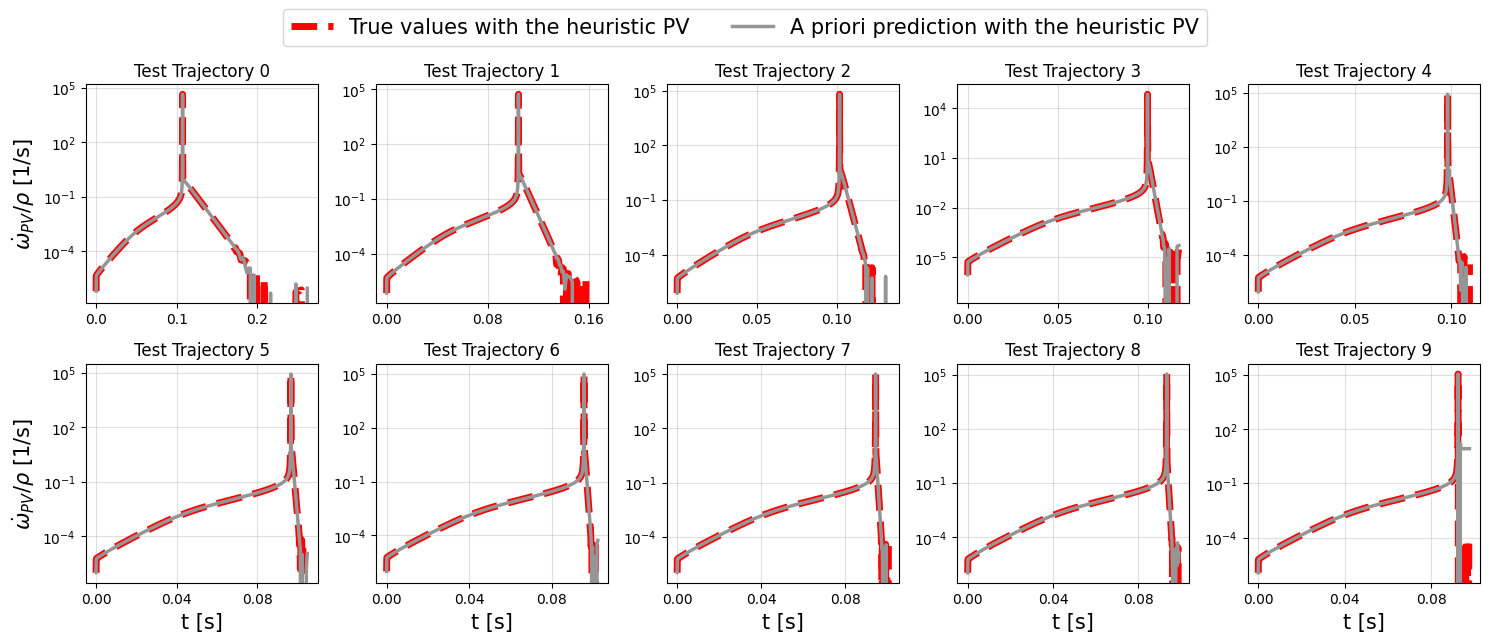

In [9]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled Tabulation/"
name = "Heuristic PV - A priori - Scaled tabulation"
namePdf = "Heuristic PV - A priori - Scaled tabulation.pdf"

num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

greys = cm.get_cmap('Greys')

for i in range(num_test_trajectories):  
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_Xu_source_test = test_trajectory_source["H2O"] - test_trajectory_source["H2"] - test_trajectory_source["O2"]
        PV_Xu_source_test = PV_Xu_source_test.to_numpy()
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    #print(PV_Xu_source_test)
    #print(prediction_test_trajectories[i])
    ax = axes[i]
    ax.plot(test_trajectory_time, PV_Xu_source_test, label="True values with the heuristic PV", color = "red", linestyle = "--", linewidth = 5)
    ax.plot(test_trajectory_time, prediction_test_trajectories[i], label="A priori prediction with the heuristic PV", color = greys(0.5), linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    ax.set_yscale("log")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.grid(True, linestyle='-', alpha=0.4)
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel(r'$\dot{\omega}_{PV} / \rho$ [1/s]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

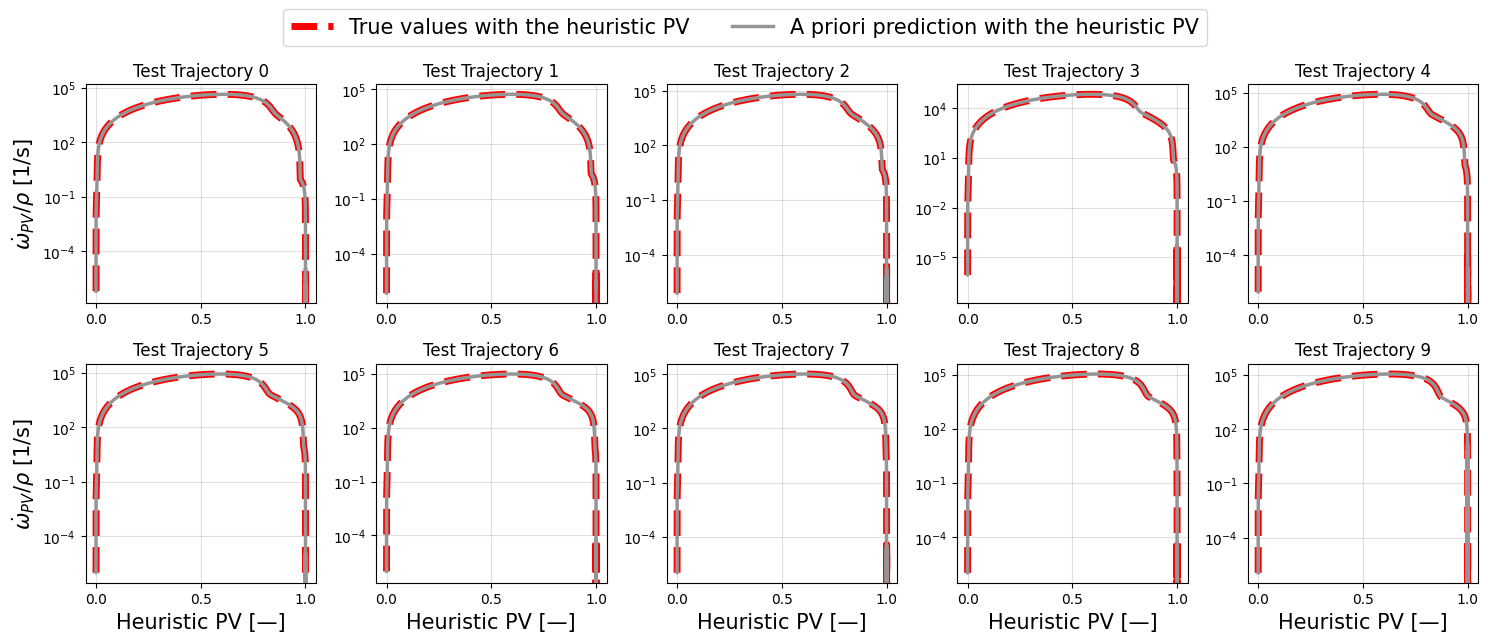

In [10]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled Tabulation/"
name = "Heuristic PV - A priori - PV on x-axis - Scaled tabulation"


num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(num_test_trajectories): 

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_Xu_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
        PV_Xu_test = PV_Xu_test.to_numpy().reshape(-1,1)
        PV_Xu_test = (PV_Xu_test - PV_Xu_test.min())/(PV_Xu_test.max() - PV_Xu_test.min())

    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_Xu_source_test = test_trajectory_source["H2O"] - test_trajectory_source["H2"] - test_trajectory_source["O2"]
        PV_Xu_source_test = PV_Xu_source_test.to_numpy()
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    #print(PV_Xu_source_test)
    #print(prediction_test_trajectories[i])
    ax = axes[i]
    ax.plot(PV_Xu_test, PV_Xu_source_test, label="True values with the heuristic PV", color = "red", linestyle = "--", linewidth = 5)
    ax.plot(PV_Xu_test, prediction_test_trajectories[i], label="A priori prediction with the heuristic PV", color = greys(0.5), linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    ax.set_yscale("log")
    ax.set_xticks([0, 0.5, 1])
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.grid(True, linestyle='-', alpha=0.4)
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"Heuristic PV [\u2014]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel(r'$\dot{\omega}_{PV} / \rho$ [1/s]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
plt.show()

In [11]:
def compute_logScaledMSE(data_true, data_pred):
    data_true_mask = data_true>0

    data_true = data_true[data_true_mask]
    data_pred = data_pred[data_true_mask]

    data_pred_mask = data_pred>0

    data_true = data_true[data_pred_mask]
    data_pred = data_pred[data_pred_mask]

    data_true = np.log10(data_true)
    data_pred = np.log10(data_pred)

    data_true = (data_true - data_true.min())/(data_true.max() - data_true.min())
    data_pred = (data_pred - data_pred.min())/(data_pred.max() - data_pred.min())

    loss = np.mean((data_pred - data_true) ** 2)

    return loss

In [12]:
num_test_trajectories = 9
start_of_traj = False

prediction_Xu = []
true_Xu = []

for i in range(num_test_trajectories): 

    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_Xu_source_test = test_trajectory_source["H2O"] - test_trajectory_source["H2"] - test_trajectory_source["O2"]
        PV_Xu_source_test = PV_Xu_source_test.to_numpy()

    H2O_array = test_trajectory["H2O"].to_numpy()

    max_perc = 0.995
    
    max_val = H2O_array.max()
    upper_threshold = max_perc * max_val
    idx_99 = np.searchsorted(H2O_array, upper_threshold, side='left')

    if(not start_of_traj):
        idx_99 = len(prediction_test_trajectories[i])

    prediction_Xu.append(prediction_test_trajectories[i][:idx_99])
    true_Xu.append(PV_Xu_source_test.reshape((-1, 1))[:idx_99])

prediction_Xu = np.vstack(prediction_Xu)
true_Xu = np.vstack(true_Xu)

print(f"Loss (logScaledMSE) for the heuristic PV - A priori prediction of PV source: {compute_logScaledMSE(true_Xu, prediction_Xu)}")

PV_source_Xu_min = true_Xu.min()
PV_source_Xu_max = true_Xu.max()

prediction_Xu = (prediction_Xu - PV_source_Xu_min)/(PV_source_Xu_max - PV_source_Xu_min)
true_Xu = (true_Xu - PV_source_Xu_min)/(PV_source_Xu_max - PV_source_Xu_min)

MSE_Xu = np.mean((prediction_Xu - true_Xu) ** 2)

print(f"Loss (MSE) for the heuristic PV - A priori prediction of PV source: {MSE_Xu}")

mask = true_Xu>0

relative_error_Xu = np.abs(prediction_Xu[mask] - true_Xu[mask]) / np.abs(true_Xu[mask])
mean_relative_error_Xu = np.mean(relative_error_Xu)

print(f"Loss (relative error) for the heuristic PV - A priori prediction of PV source: {mean_relative_error_Xu}")

Loss (logScaledMSE) for the heuristic PV - A priori prediction of PV source: 0.0007812016417555096
Loss (MSE) for the heuristic PV - A priori prediction of PV source: 7.415883544332238e-11
Loss (relative error) for the heuristic PV - A priori prediction of PV source: 0.003899262508857156


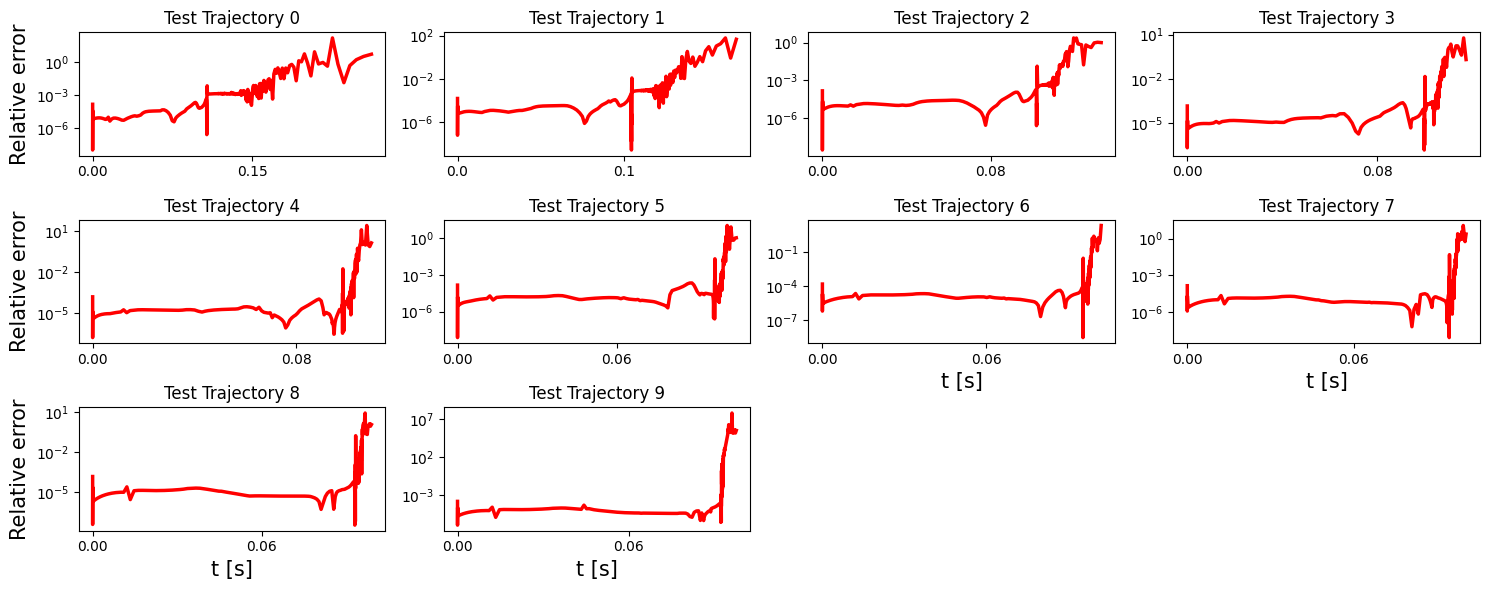

In [13]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled Tabulation/"
name = f"Heuristic PV - A priori - Relative error - scaled tabulation.png"


num_test_trajectories = 10
rows, cols = 3,4  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(10):  
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_Xu_source_test = test_trajectory_source["H2O"] - test_trajectory_source["H2"] - test_trajectory_source["O2"]
        PV_Xu_source_test = PV_Xu_source_test.to_numpy()
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    #print(PV_Xu_source_test)
    #print(prediction_test_trajectories[i])
    ax = axes[i]
    relativeError = np.abs(PV_Xu_source_test.flatten() - prediction_test_trajectories[i].flatten())/np.abs(PV_Xu_source_test.flatten())
    ax.plot(test_trajectory_time, relativeError, color = "red", linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    #ax.set_xscale('log')
    #ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=3))
    #ax.set_xticks([1e-1])  # Define specific tick positions
    #ax.get_xaxis().set_major_formatter(ticker.LogFormatter())
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    ax.set_yscale("log")
    
    if(i>=6):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel("Relative error", fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300)
plt.show()

### A posteriori simulation with PV of Xu

In [14]:
class RHS_ODE:
    def __init__(self, mf_data, PV_data, PV_source_data, PV_min, PV_max):
        self.mf_data = mf_data
        self.PV_data = PV_data
        self.PV_source_data = PV_source_data
        self.PV_min = PV_min
        self.PV_max = PV_max

        self.t_pred = []
        self.PV_pred = []
        self.PV_source_pred = []

    def __call__(self, X, t):
        PV_scaled = (X[1] - self.PV_min) / (self.PV_max - self.PV_min)
        predicted = predict_PVsource(X[0], PV_scaled, self.mf_data, self.PV_data, self.PV_source_data)

        self.t_pred.append(t)
        self.PV_pred.append(X[1])
        self.PV_source_pred.append(predicted[0])

        dZdt = np.array([0, predicted[0]])
        return dZdt.ravel()

In [15]:
idx_start_simulation = 0
list_simulations_Xu = []

list_predicted_timesteps_Xu = []
list_predicted_PV_Xu = []
list_predicted_PV_source_Xu = []

#Get current date and time
now = datetime.now()
date_str = now.strftime("%Y-%m-%d")
time_str = now.strftime("%Hh%M")

print("Date:", date_str)
print("Hour:", time_str)

for i in range(10):

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_Xu_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
        PV_Xu_test = PV_Xu_test.to_numpy().reshape(-1,1)
        f_PV_Xu_test = np.hstack((np.full(PV_Xu_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_Xu_test))
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    initial_condition = f_PV_Xu_test[idx_start_simulation,:]
    t_coordinates = test_trajectory_time[idx_start_simulation:].to_numpy().ravel()
    
    rhs = RHS_ODE(mixture_fractions_train, PV_Xu_scaled, PV_Xu_source_train, PV_Xu_test.min(), PV_Xu_test.max())
    
    numerical_solution_Xu, info = odeint(rhs, initial_condition.ravel(), t_coordinates, full_output=1)
    list_simulations_Xu.append(numerical_solution_Xu)

    predicted_timesteps = np.array(rhs.t_pred)
    list_predicted_timesteps_Xu.append(predicted_timesteps)

    predicted_PV = np.array(rhs.PV_pred)
    list_predicted_PV_Xu.append(predicted_PV)

    predicted_source_terms = np.array(rhs.PV_source_pred)
    list_predicted_PV_source_Xu.append(predicted_source_terms)

    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_Xu_source_test = test_trajectory_source["H2O"] - test_trajectory_source["H2"] - test_trajectory_source["O2"]
        PV_Xu_source_test = PV_Xu_source_test.to_numpy()

    MSE_Xu_test_simulation = mean_squared_error(PV_Xu_test[idx_start_simulation:], numerical_solution_Xu[:,1])

    print(f"MSE for test trajectory {i}: {MSE_Xu_test_simulation}")

Date: 2026-05-20
Hour: 12h24
MSE for test trajectory 0: 0.017097657580751425
MSE for test trajectory 1: 0.02223419478303833
MSE for test trajectory 2: 0.030235981379922183
MSE for test trajectory 3: 0.03292046341298104
MSE for test trajectory 4: 0.0377437291172202
MSE for test trajectory 5: 0.042142266784120336
MSE for test trajectory 6: 0.045611463352035767
MSE for test trajectory 7: 0.048190329139626974
MSE for test trajectory 8: 0.05030799811125601
MSE for test trajectory 9: 0.051802393319907124


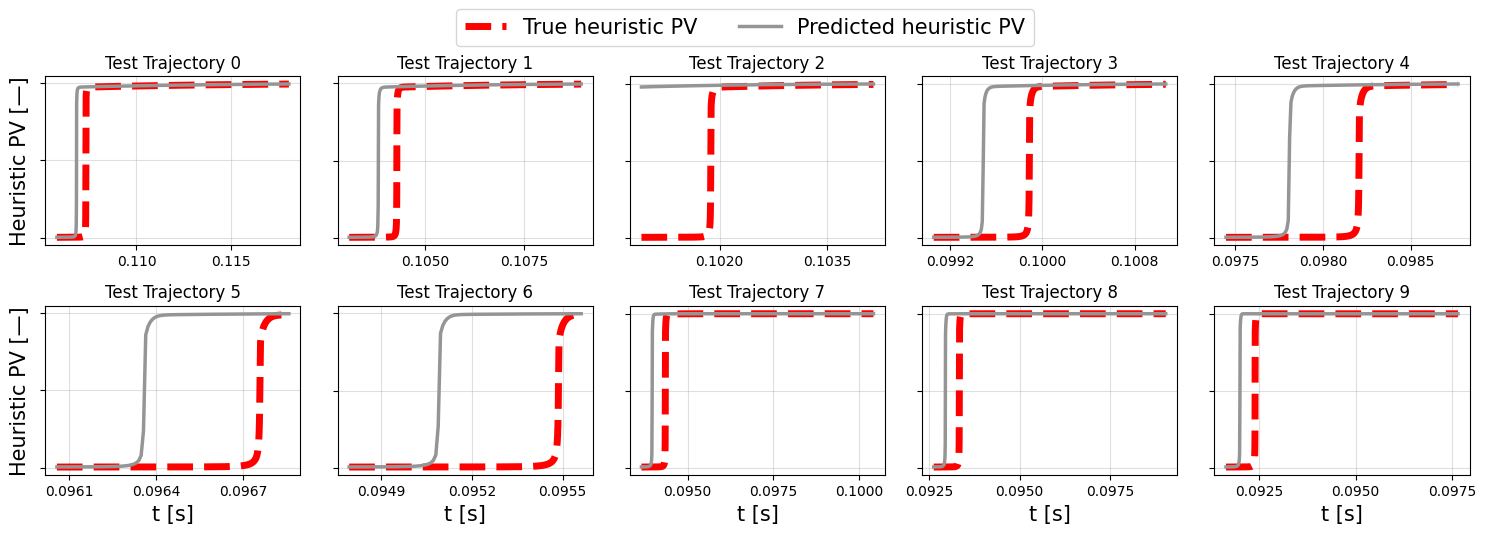

In [16]:
save = False
zoom = True
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled tabulation/"

idx_start_simulation = 0

num_test_trajectories = 10
rows, cols = 2, 5 # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 5))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(num_test_trajectories):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_Xu_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
        PV_Xu_test = PV_Xu_test.to_numpy().reshape(-1,1)
        #PV_Xu_test = (PV_Xu_test - PV_Xu_test.min())/(PV_Xu_test.max() - PV_Xu_test.min())
        f_PV_Xu_test = np.hstack((np.full(PV_Xu_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_Xu_test))
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
        
    ax = axes[i]

    PV_Xu_test_min = PV_Xu_test.min()
    PV_Xu_test_max = PV_Xu_test.max()

    if(zoom):
        ##############################################
        # Get the first and last index of the ignition
        ##############################################

        H2O_array = test_trajectory["H2O"].to_numpy()

        min_perc = 0.0028
        max_perc = 0.999
        
        max_val = H2O_array.max()
        lower_threshold = min_perc * max_val
        upper_threshold = max_perc * max_val

        idx_1 = np.searchsorted(H2O_array, lower_threshold, side='left')
        idx_99 = np.searchsorted(H2O_array, upper_threshold, side='left')

        ax.plot(test_trajectory_time[idx_1:idx_99], (PV_Xu_test[idx_1:idx_99] - PV_Xu_test_min)/(PV_Xu_test_max - PV_Xu_test_min), label="True heuristic PV", color = "red", linestyle = "--", linewidth = 5)
        ax.plot(test_trajectory_time[idx_1:idx_99], (list_simulations_Xu[i][idx_1:idx_99,1] - PV_Xu_test_min)/(PV_Xu_test_max - PV_Xu_test_min), label="Predicted heuristic PV", color = greys(0.5), linewidth = 2.5)

    else:
        ax.plot(test_trajectory_time[idx_start_simulation:], (PV_Xu_test[idx_start_simulation:] - PV_Xu_test_min)/(PV_Xu_test_max - PV_Xu_test_min), label="True heuristic PV", color = "red", linestyle = "--", linewidth = 5)
        ax.plot(test_trajectory_time[idx_start_simulation:], (list_simulations_Xu[i][:,1] - PV_Xu_test_min)/(PV_Xu_test_max - PV_Xu_test_min), label="Predicted heuristic PV", color = greys(0.5), linewidth = 2.5)
    
    ax.set_title(f"Test Trajectory {i}")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    #ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels([])
    ax.grid(True, linestyle='-', alpha=0.4)
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel('Heuristic PV [\u2014]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

name = f"Heuristic vs optimized - A posteriori - Heuristic PV - Scaled tabulation{f' - zoom {min_perc}-{max_perc}' if zoom else ''}.png"
namePdf = f"Heuristic vs optimized - A posteriori - Heuristic PV - Scaled tabulation{f' - zoom {min_perc}-{max_perc}' if zoom else ''}.pdf"

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

## Heuristic: H2O

In [17]:
PV_heuH2O_train = state_space_train["H2O"]

PV_heuH2O_train = PV_heuH2O_train.to_numpy().reshape(-1,1)
PV_heuH2O_source_train = state_space_source_train["H2O"]
PV_heuH2O_source_train = PV_heuH2O_source_train.to_numpy().reshape(-1,1)

In [18]:
# Rescale every trajectory from 0 to 1 (each having its own mixture fraction)

df = pd.DataFrame({
    'PV heuH2O': PV_heuH2O_train.squeeze(),
    'mixture_fraction': mixture_fractions_train
})

# Normalize PV within each mixture_fraction group
df['PV_heuH2O_scaled'] = df.groupby('mixture_fraction')['PV heuH2O'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0.0
)

# Get the PV back to numpy
PV_heuH2O_scaled = df['PV_heuH2O_scaled'].to_numpy()

In [19]:
prediction_test_trajectories_heuH2O = []

for i in range(10):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heuH2O_test = test_trajectory["H2O"]
        PV_heuH2O_test = PV_heuH2O_test.to_numpy().reshape(-1,1)
        PV_heuH2O_test = (PV_heuH2O_test - PV_heuH2O_test.min())/(PV_heuH2O_test.max() - PV_heuH2O_test.min())
        
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heuH2O_source_test = test_trajectory_source["H2O"]
        PV_heuH2O_source_test = PV_heuH2O_source_test.to_numpy()
    
    vectorized_predict_PVsource = np.vectorize(
        lambda pv_target: predict_PVsource(mixture_fractions_test[i], pv_target, mixture_fractions_train, PV_heuH2O_scaled, PV_heuH2O_source_train)
    )

    PV_heuH2O_source_test_predicted = vectorized_predict_PVsource(PV_heuH2O_test)
    
    prediction_test_trajectories_heuH2O.append(PV_heuH2O_source_test_predicted)

    MSE_heuH2O_test = mean_squared_error(PV_heuH2O_source_test, PV_heuH2O_source_test_predicted)

    print(f"MSE of heuH2O for test trajectory {i}: {MSE_heuH2O_test}")

MSE of heuH2O for test trajectory 0: 0.004917646863340444
MSE of heuH2O for test trajectory 1: 0.005293026671865234
MSE of heuH2O for test trajectory 2: 0.029693238711892857
MSE of heuH2O for test trajectory 3: 0.05877619297799103
MSE of heuH2O for test trajectory 4: 0.10462980829502423
MSE of heuH2O for test trajectory 5: 0.13854425167617798
MSE of heuH2O for test trajectory 6: 3.4208555682840807
MSE of heuH2O for test trajectory 7: 22.99561954167784
MSE of heuH2O for test trajectory 8: 34.4480381139964
MSE of heuH2O for test trajectory 9: 52.75815477059856


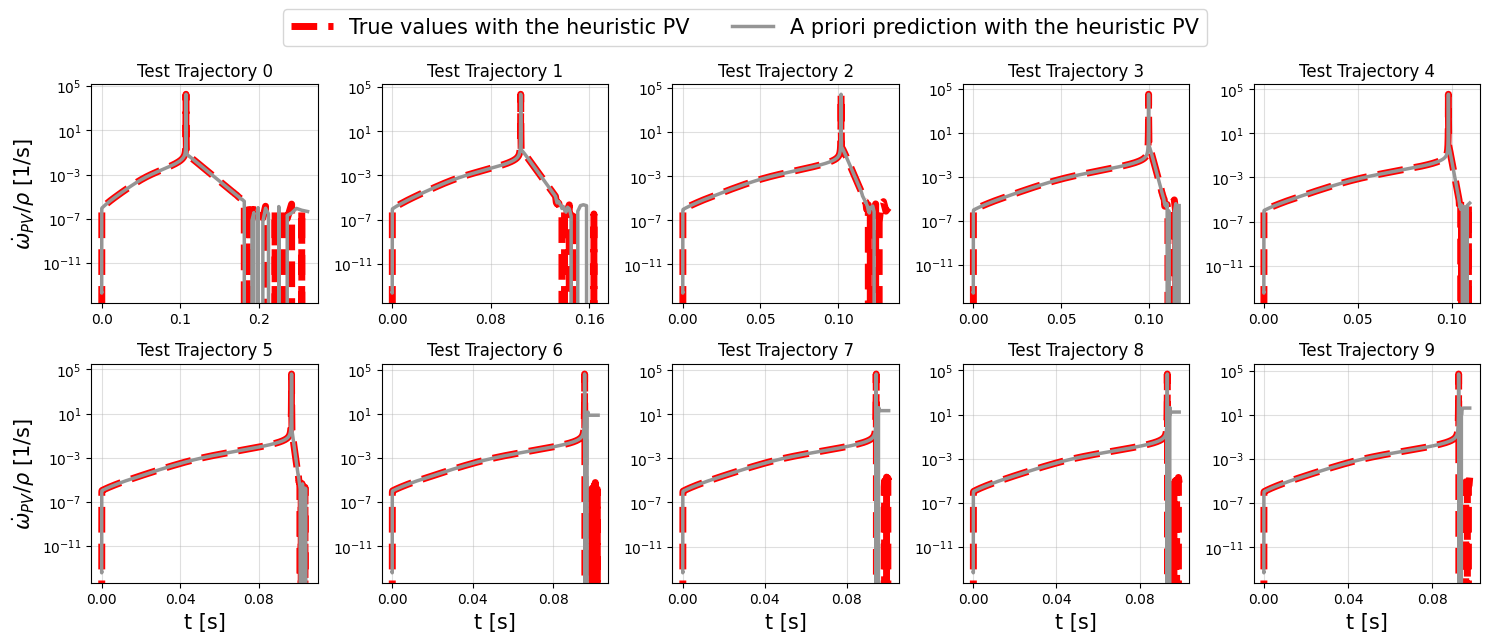

In [20]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled Tabulation/"
name = "Heuristic PV heuH2O - A priori - Scaled tabulation"
namePdf = "Heuristic PV heuH2O - A priori - Scaled tabulation.pdf"

num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(num_test_trajectories):  
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heuH2O_source_test = test_trajectory_source["H2O"]
        PV_heuH2O_source_test = PV_heuH2O_source_test.to_numpy()
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    #print(PV_Xu_source_test)
    #print(prediction_test_trajectories[i])
    ax = axes[i]
    ax.plot(test_trajectory_time, PV_heuH2O_source_test, label="True values with the heuristic PV", color = "red", linestyle = "--", linewidth = 5)
    ax.plot(test_trajectory_time, prediction_test_trajectories_heuH2O[i], label="A priori prediction with the heuristic PV", color = greys(0.5), linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    ax.set_yscale("log")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.grid(True, linestyle='-', alpha=0.4)
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel(r'$\dot{\omega}_{PV} / \rho$ [1/s]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

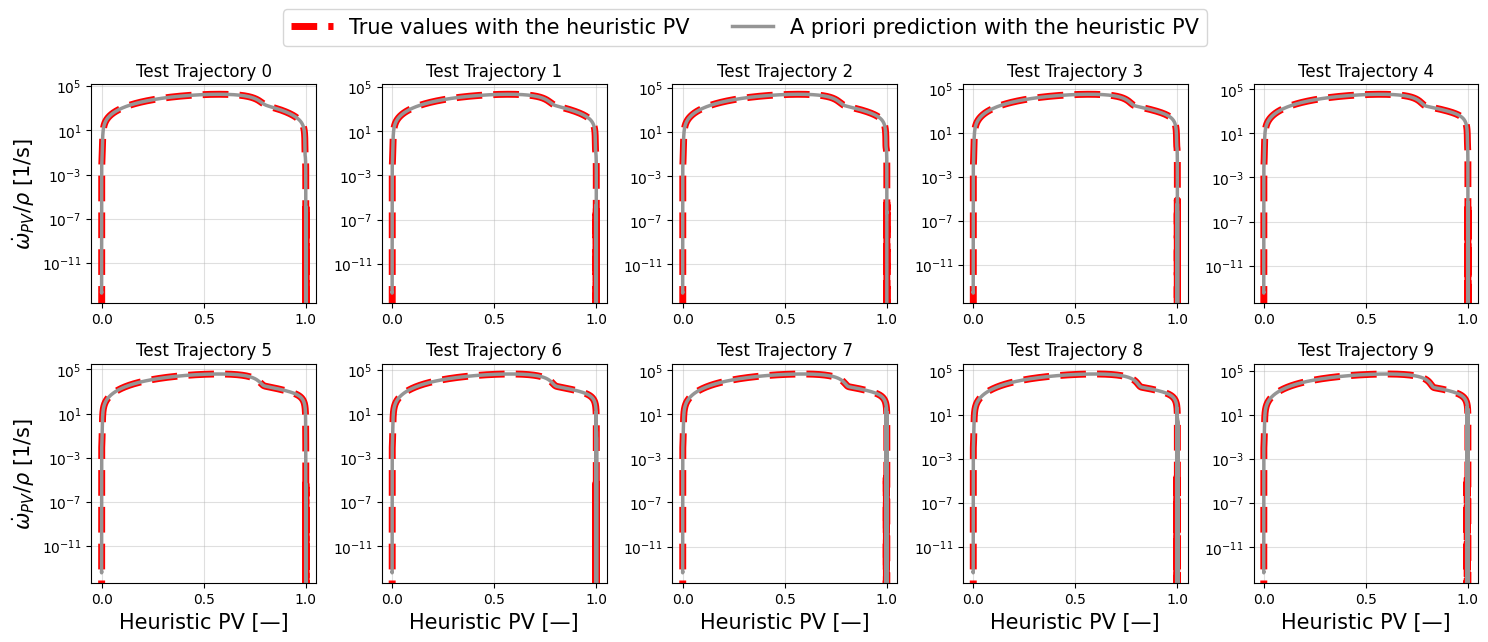

In [21]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled Tabulation/"
name = "Heuristic PV heuH2O - A priori - PV on x-axis - Scaled tabulation"


num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(num_test_trajectories): 

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heuH2O_test = test_trajectory["H2O"]
        PV_heuH2O_test = PV_heuH2O_test.to_numpy().reshape(-1,1)
        PV_heuH2O_test = (PV_heuH2O_test - PV_heuH2O_test.min())/(PV_heuH2O_test.max() - PV_heuH2O_test.min())

    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heuH2O_source_test = test_trajectory_source["H2O"]
        PV_heuH2O_source_test = PV_heuH2O_source_test.to_numpy()
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    #print(PV_Xu_source_test)
    #print(prediction_test_trajectories[i])
    ax = axes[i]
    ax.plot(PV_heuH2O_test, PV_heuH2O_source_test, label="True values with the heuristic PV", color = "red", linestyle = "--", linewidth = 5)
    ax.plot(PV_heuH2O_test, prediction_test_trajectories_heuH2O[i], label="A priori prediction with the heuristic PV", color = greys(0.5), linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    ax.set_yscale("log")
    ax.set_xticks([0, 0.5, 1])
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.grid(True, linestyle='-', alpha=0.4)
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"Heuristic PV [\u2014]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel(r'$\dot{\omega}_{PV} / \rho$ [1/s]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
plt.show()

In [22]:
num_test_trajectories = 9
start_of_traj = False

prediction_heuH2O = []
true_heuH2O = []

for i in range(num_test_trajectories): 

    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heuH2O_source_test = test_trajectory_source["H2O"]
        PV_heuH2O_source_test = PV_heuH2O_source_test.to_numpy()

    H2O_array = test_trajectory["H2O"].to_numpy()

    max_perc = 0.995
    
    max_val = H2O_array.max()
    upper_threshold = max_perc * max_val
    idx_99 = np.searchsorted(H2O_array, upper_threshold, side='left')

    if(not start_of_traj):
        idx_99 = len(prediction_test_trajectories_heuH2O[i])

    prediction_heuH2O.append(prediction_test_trajectories_heuH2O[i][:idx_99])
    true_heuH2O.append(PV_heuH2O_source_test.reshape((-1, 1))[:idx_99])

prediction_heuH2O = np.vstack(prediction_heuH2O)
true_heuH2O = np.vstack(true_heuH2O)

print(f"Loss (logScaledMSE) for the heuristic PV - A priori prediction of PV source: {compute_logScaledMSE(true_heuH2O, prediction_heuH2O)}")

PV_source_heuH2O_min = true_heuH2O.min()
PV_source_heuH2O_max = true_heuH2O.max()

prediction_heuH2O = (prediction_heuH2O - PV_source_heuH2O_min)/(PV_source_heuH2O_max - PV_source_heuH2O_min)
true_heuH2O = (true_heuH2O - PV_source_heuH2O_min)/(PV_source_heuH2O_max - PV_source_heuH2O_min)

MSE_heuH2O = np.mean((prediction_heuH2O - true_heuH2O) ** 2)

print(f"Loss (MSE) for the heuristic PV - A priori prediction of PV source: {MSE_heuH2O}")

mask = true_heuH2O>0

relative_error_heuH2O = np.abs(prediction_heuH2O[mask] - true_heuH2O[mask]) / np.abs(true_heuH2O[mask])
mean_relative_error_heuH2O = np.mean(relative_error_heuH2O)

print(f"Loss (relative error) for the heuristic PV heuH2O - A priori prediction of PV source: {mean_relative_error_heuH2O}")

Loss (logScaledMSE) for the heuristic PV - A priori prediction of PV source: 0.00012412774198358357
Loss (MSE) for the heuristic PV - A priori prediction of PV source: 2.9672550641635047e-09
Loss (relative error) for the heuristic PV heuH2O - A priori prediction of PV source: 0.5644274139281119


C:\Windows\Temp\ipykernel_1704\1907780465.py:26: RuntimeWarning: divide by zero encountered in divide
  relativeError = np.abs(PV_heuH2O_source_test.flatten() - prediction_test_trajectories_heuH2O[i].flatten())/np.abs(PV_heuH2O_source_test.flatten())
C:\Windows\Temp\ipykernel_1704\1907780465.py:26: RuntimeWarning: divide by zero encountered in divide
  relativeError = np.abs(PV_heuH2O_source_test.flatten() - prediction_test_trajectories_heuH2O[i].flatten())/np.abs(PV_heuH2O_source_test.flatten())
C:\Windows\Temp\ipykernel_1704\1907780465.py:26: RuntimeWarning: divide by zero encountered in divide
  relativeError = np.abs(PV_heuH2O_source_test.flatten() - prediction_test_trajectories_heuH2O[i].flatten())/np.abs(PV_heuH2O_source_test.flatten())
C:\Windows\Temp\ipykernel_1704\1907780465.py:26: RuntimeWarning: divide by zero encountered in divide
  relativeError = np.abs(PV_heuH2O_source_test.flatten() - prediction_test_trajectories_heuH2O[i].flatten())/np.abs(PV_heuH2O_source_test.flatten

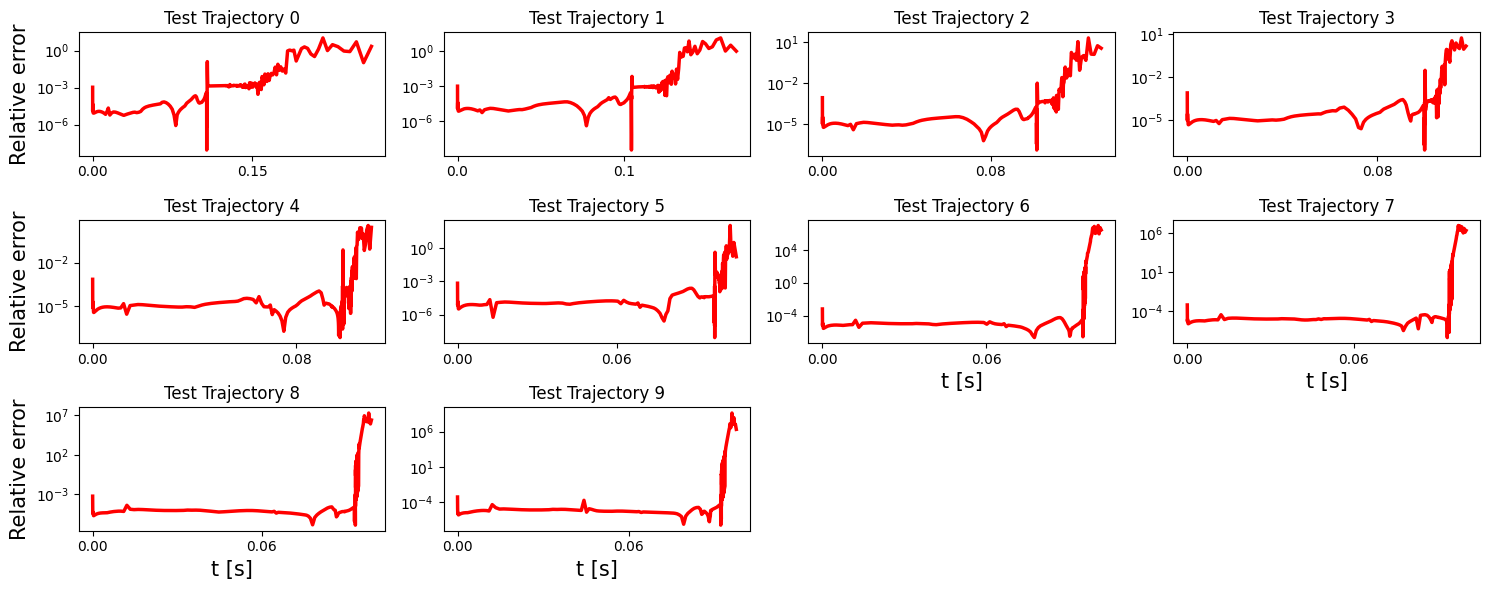

In [23]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled Tabulation/"
name = f"Heuristic PV heuH2O - A priori - Relative error - scaled tabulation.png"


num_test_trajectories = 10
rows, cols = 3,4  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(10):  
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heuH2O_source_test = test_trajectory_source["H2O"]
        PV_heuH2O_source_test = PV_heuH2O_source_test.to_numpy()
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    #print(PV_Xu_source_test)
    #print(prediction_test_trajectories[i])
    ax = axes[i]
    relativeError = np.abs(PV_heuH2O_source_test.flatten() - prediction_test_trajectories_heuH2O[i].flatten())/np.abs(PV_heuH2O_source_test.flatten())
    ax.plot(test_trajectory_time, relativeError, color = "red", linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    #ax.set_xscale('log')
    #ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=3))
    #ax.set_xticks([1e-1])  # Define specific tick positions
    #ax.get_xaxis().set_major_formatter(ticker.LogFormatter())
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    ax.set_yscale("log")
    
    if(i>=6):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel("Relative error", fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300)
plt.show()

In [24]:
idx_start_simulation = 0
list_simulations_heuH2O = []

list_predicted_timesteps_heuH2O = []
list_predicted_PV_heuH2O = []
list_predicted_PV_source_heuH2O = []

#Get current date and time
now = datetime.now()
date_str = now.strftime("%Y-%m-%d")
time_str = now.strftime("%Hh%M")

print("Date:", date_str)
print("Hour:", time_str)

for i in range(10):

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heuH2O_test = test_trajectory["H2O"]
        PV_heuH2O_test = PV_heuH2O_test.to_numpy().reshape(-1,1)
        f_PV_heuH2O_test = np.hstack((np.full(PV_heuH2O_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_heuH2O_test))
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    initial_condition = f_PV_heuH2O_test[idx_start_simulation,:]
    t_coordinates = test_trajectory_time[idx_start_simulation:].to_numpy().ravel()
    
    rhs = RHS_ODE(mixture_fractions_train, PV_heuH2O_scaled, PV_heuH2O_source_train, PV_heuH2O_test.min(), PV_heuH2O_test.max())
    
    numerical_solution_heuH2O, info = odeint(rhs, initial_condition.ravel(), t_coordinates, full_output=1)
    list_simulations_heuH2O.append(numerical_solution_heuH2O)

    predicted_timesteps = np.array(rhs.t_pred)
    list_predicted_timesteps_heuH2O.append(predicted_timesteps)

    predicted_PV = np.array(rhs.PV_pred)
    list_predicted_PV_heuH2O.append(predicted_PV)

    predicted_source_terms = np.array(rhs.PV_source_pred)
    list_predicted_PV_source_heuH2O.append(predicted_source_terms)

    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heuH2O_source_test = test_trajectory_source["H2O"]
        PV_heuH2O_source_test = PV_heuH2O_source_test.to_numpy()

    MSE_heuH2O_test_simulation = mean_squared_error(PV_heuH2O_test[idx_start_simulation:], numerical_solution_heuH2O[:,1])

    print(f"MSE for test trajectory {i}: {MSE_heuH2O_test_simulation}")

Date: 2026-05-20
Hour: 12h26
MSE for test trajectory 0: 0.004763499926295444
MSE for test trajectory 1: 0.006078381857850164
MSE for test trajectory 2: 0.007416519423791844
MSE for test trajectory 3: 0.008701167250764813
MSE for test trajectory 4: 0.009819164207421065
MSE for test trajectory 5: 0.010853266900782248
MSE for test trajectory 6: 0.011793258033155235
MSE for test trajectory 7: 0.012309865489632567
MSE for test trajectory 8: 0.01296118100872383
MSE for test trajectory 9: 0.013469283881410384


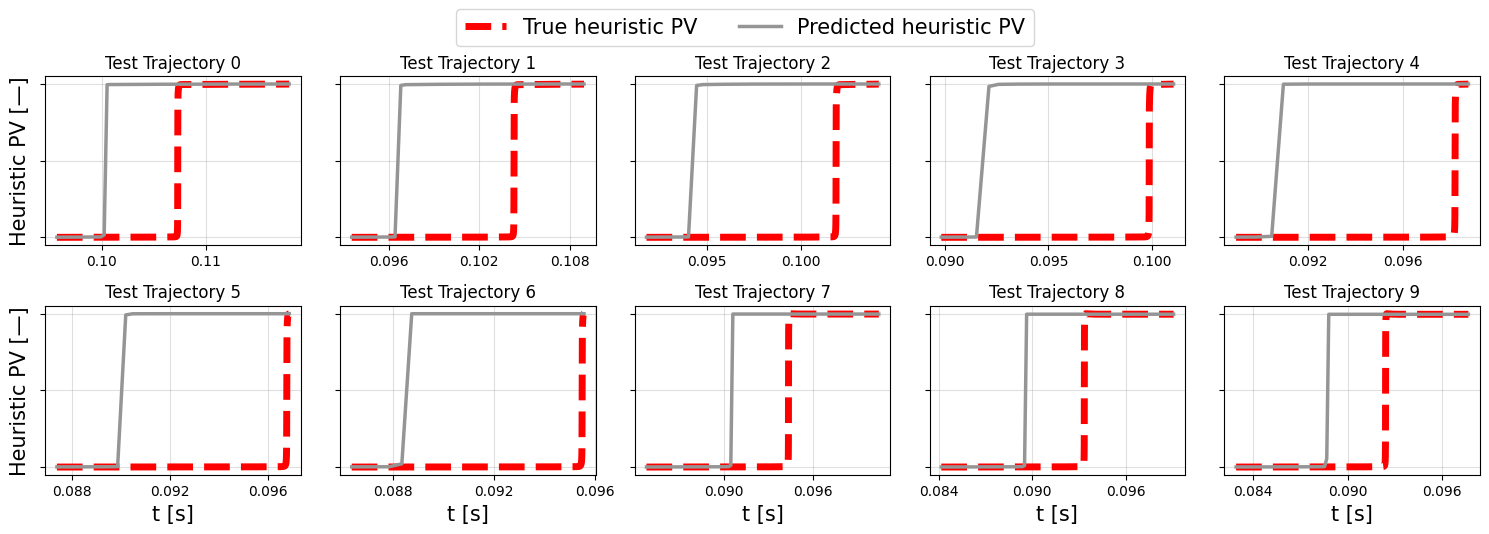

In [25]:
save = False
zoom = True
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled tabulation/"

idx_start_simulation = 0

num_test_trajectories = 10
rows, cols = 2, 5 # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 5))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(num_test_trajectories):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heuH2O_test = test_trajectory["H2O"]
        PV_heuH2O_test = PV_heuH2O_test.to_numpy().reshape(-1,1)
        #PV_Xu_test = (PV_Xu_test - PV_Xu_test.min())/(PV_Xu_test.max() - PV_Xu_test.min())
        f_PV_heuH2O_test = np.hstack((np.full(PV_heuH2O_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_heuH2O_test))
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
        
    ax = axes[i]

    PV_heuH2O_test_min = PV_heuH2O_test.min()
    PV_heuH2O_test_max = PV_heuH2O_test.max()

    if(zoom):
        ##############################################
        # Get the first and last index of the ignition
        ##############################################

        H2O_array = test_trajectory["H2O"].to_numpy()

        min_perc = 0.001
        max_perc = 0.999
        
        max_val = H2O_array.max()
        lower_threshold = min_perc * max_val
        upper_threshold = max_perc * max_val

        idx_1 = np.searchsorted(H2O_array, lower_threshold, side='left')
        idx_99 = np.searchsorted(H2O_array, upper_threshold, side='left')

        ax.plot(test_trajectory_time[idx_1:idx_99], (PV_heuH2O_test[idx_1:idx_99] - PV_heuH2O_test_min)/(PV_heuH2O_test_max - PV_heuH2O_test_min), label="True heuristic PV", color = "red", linestyle = "--", linewidth = 5)
        ax.plot(test_trajectory_time[idx_1:idx_99], (list_simulations_heuH2O[i][idx_1:idx_99,1] - PV_heuH2O_test_min)/(PV_heuH2O_test_max - PV_heuH2O_test_min), label="Predicted heuristic PV", color = greys(0.5), linewidth = 2.5)

    else:
        ax.plot(test_trajectory_time[idx_start_simulation:], (PV_heuH2O_test[idx_start_simulation:] - PV_heuH2O_test_min)/(PV_heuH2O_test_max - PV_heuH2O_test_min), label="True heuristic PV", color = "red", linestyle = "--", linewidth = 5)
        ax.plot(test_trajectory_time[idx_start_simulation:], (list_simulations_heuH2O[i][:,1] - PV_heuH2O_test_min)/(PV_heuH2O_test_max - PV_heuH2O_test_min), label="Predicted heuristic PV", color = greys(0.5), linewidth = 2.5)
    
    ax.set_title(f"Test Trajectory {i}")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    #ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels([])
    ax.grid(True, linestyle='-', alpha=0.4)
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel('Heuristic PV [\u2014]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

name = f"Heuristic vs optimized - A posteriori - Heuristic PV heu10HO2 - Scaled tabulation{f' - zoom {min_perc}-{max_perc}' if zoom else ''}.png"
namePdf = f"Heuristic vs optimized - A posteriori - Heuristic PV heu10HO2 - Scaled tabulation{f' - zoom {min_perc}-{max_perc}' if zoom else ''}.pdf"

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

## Heuristic PV: H2O + 10 HO2

In [26]:
PV_heu10HO2_train = state_space_train["H2O"] + 10 * state_space_train["HO2"]

PV_heu10HO2_train = PV_heu10HO2_train.to_numpy().reshape(-1,1)
PV_heu10HO2_source_train = state_space_source_train["H2O"] + 10 * state_space_source_train["HO2"]
PV_heu10HO2_source_train = PV_heu10HO2_source_train.to_numpy().reshape(-1,1)

In [27]:
# Rescale every trajectory from 0 to 1 (each having its own mixture fraction)

df = pd.DataFrame({
    'PV heu10HO2': PV_heu10HO2_train.squeeze(),
    'mixture_fraction': mixture_fractions_train
})

# Normalize PV within each mixture_fraction group
df['PV_heu10HO2_scaled'] = df.groupby('mixture_fraction')['PV heu10HO2'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0.0
)

# Get the PV back to numpy
PV_heu10HO2_scaled = df['PV_heu10HO2_scaled'].to_numpy()

In [28]:
prediction_test_trajectories_heu10HO2 = []

for i in range(10):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu10HO2_test = test_trajectory["H2O"] + 10 * test_trajectory["HO2"]
        PV_heu10HO2_test = PV_heu10HO2_test.to_numpy().reshape(-1,1)
        PV_heu10HO2_test = (PV_heu10HO2_test - PV_heu10HO2_test.min())/(PV_heu10HO2_test.max() - PV_heu10HO2_test.min())
        
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu10HO2_source_test = test_trajectory_source["H2O"] + 10 * test_trajectory_source["HO2"]
        PV_heu10HO2_source_test = PV_heu10HO2_source_test.to_numpy()
    
    vectorized_predict_PVsource = np.vectorize(
        lambda pv_target: predict_PVsource(mixture_fractions_test[i], pv_target, mixture_fractions_train, PV_heu10HO2_scaled, PV_heu10HO2_source_train)
    )

    PV_heu10HO2_source_test_predicted = vectorized_predict_PVsource(PV_heu10HO2_test)
    
    prediction_test_trajectories_heu10HO2.append(PV_heu10HO2_source_test_predicted)

    MSE_heu10HO2_test = mean_squared_error(PV_heu10HO2_source_test, PV_heu10HO2_source_test_predicted)

    print(f"MSE of heu10HO2 for test trajectory {i}: {MSE_heu10HO2_test}")

MSE of heu10HO2 for test trajectory 0: 0.0067156794284251725
MSE of heu10HO2 for test trajectory 1: 0.005557899339167537
MSE of heu10HO2 for test trajectory 2: 0.02979932377834241
MSE of heu10HO2 for test trajectory 3: 0.05881655172513993
MSE of heu10HO2 for test trajectory 4: 0.10471022071818523
MSE of heu10HO2 for test trajectory 5: 0.13906264795893208
MSE of heu10HO2 for test trajectory 6: 3.7930665296384345
MSE of heu10HO2 for test trajectory 7: 23.726308063194313
MSE of heu10HO2 for test trajectory 8: 55.56069735100583
MSE of heu10HO2 for test trajectory 9: 29.175857459994702


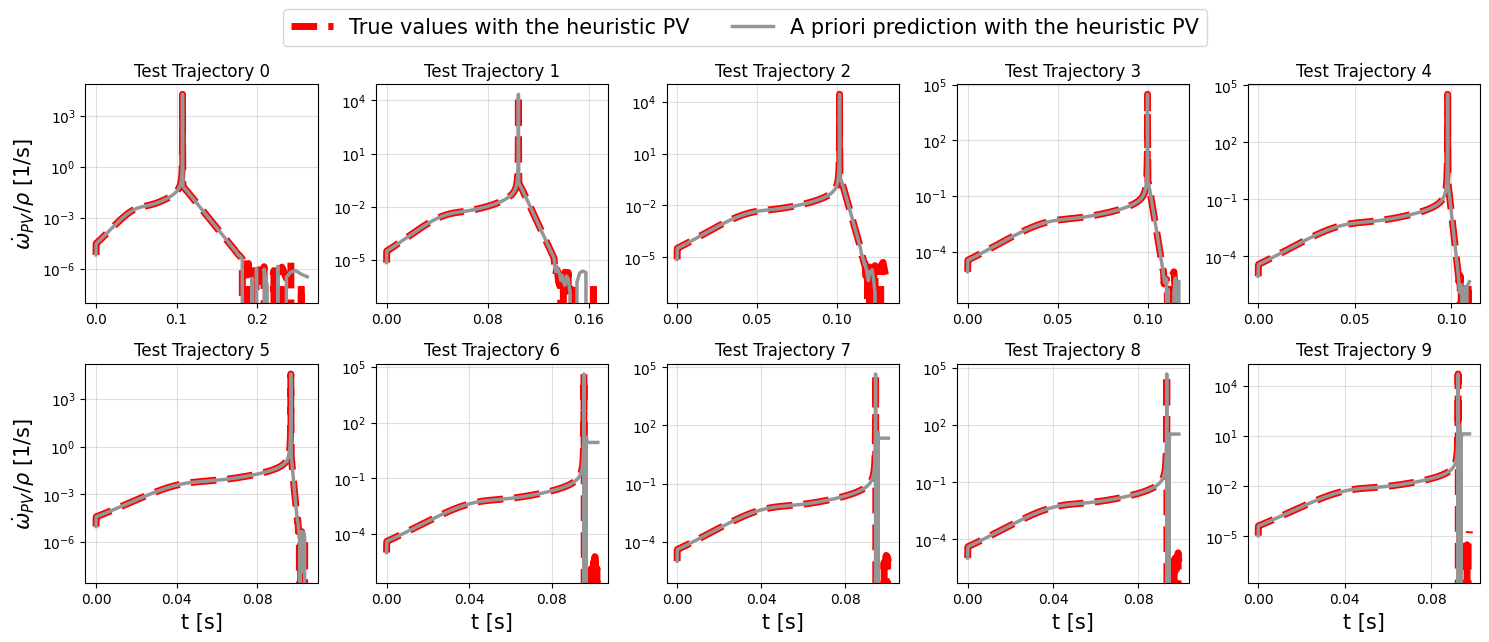

In [29]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled Tabulation/"
name = "Heuristic PV heu10HO2 - A priori - Scaled tabulation"
namePdf = "Heuristic PV heu10HO2 - A priori - Scaled tabulation.pdf"

num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(num_test_trajectories):  
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu10HO2_source_test = test_trajectory_source["H2O"] + 10 * test_trajectory_source["HO2"]
        PV_heu10HO2_source_test = PV_heu10HO2_source_test.to_numpy()
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    #print(PV_Xu_source_test)
    #print(prediction_test_trajectories[i])
    ax = axes[i]
    ax.plot(test_trajectory_time, PV_heu10HO2_source_test, label="True values with the heuristic PV", color = "red", linestyle = "--", linewidth = 5)
    ax.plot(test_trajectory_time, prediction_test_trajectories_heu10HO2[i], label="A priori prediction with the heuristic PV", color = greys(0.5), linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    ax.set_yscale("log")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.grid(True, linestyle='-', alpha=0.4)
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel(r'$\dot{\omega}_{PV} / \rho$ [1/s]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

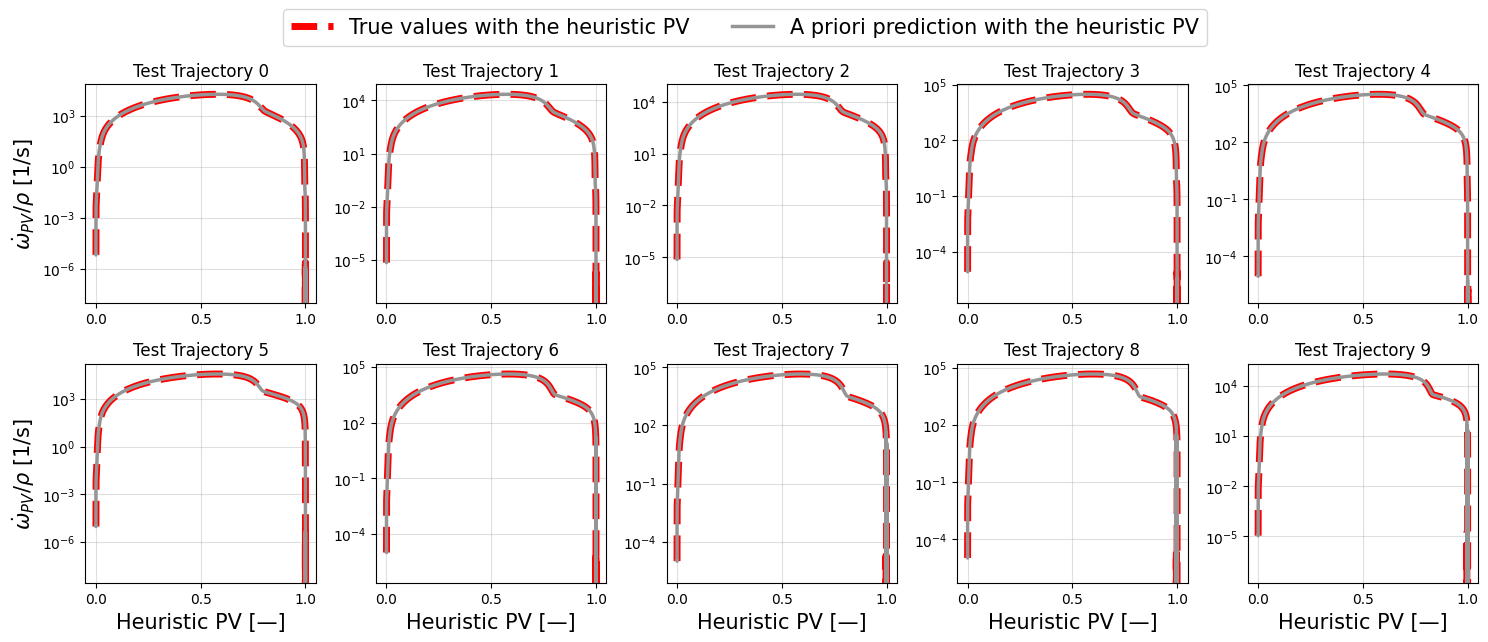

In [30]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled Tabulation/"
name = "Heuristic PV heu10HO2 - A priori - PV on x-axis - Scaled tabulation"


num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(num_test_trajectories): 

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu10HO2_test = test_trajectory["H2O"] + 10 * test_trajectory["HO2"]
        PV_heu10HO2_test = PV_heu10HO2_test.to_numpy().reshape(-1,1)
        PV_heu10HO2_test = (PV_heu10HO2_test - PV_heu10HO2_test.min())/(PV_heu10HO2_test.max() - PV_heu10HO2_test.min())

    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu10HO2_source_test = test_trajectory_source["H2O"] + 10 * test_trajectory_source["HO2"]
        PV_heu10HO2_source_test = PV_heu10HO2_source_test.to_numpy()
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    #print(PV_Xu_source_test)
    #print(prediction_test_trajectories[i])
    ax = axes[i]
    ax.plot(PV_heu10HO2_test, PV_heu10HO2_source_test, label="True values with the heuristic PV", color = "red", linestyle = "--", linewidth = 5)
    ax.plot(PV_heu10HO2_test, prediction_test_trajectories_heu10HO2[i], label="A priori prediction with the heuristic PV", color = greys(0.5), linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    ax.set_yscale("log")
    ax.set_xticks([0, 0.5, 1])
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.grid(True, linestyle='-', alpha=0.4)
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"Heuristic PV [\u2014]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel(r'$\dot{\omega}_{PV} / \rho$ [1/s]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
plt.show()

In [31]:
num_test_trajectories = 9
start_of_traj = False

prediction_heu10HO2 = []
true_heu10HO2 = []

for i in range(num_test_trajectories): 

    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu10HO2_source_test = test_trajectory_source["H2O"] + 10 * test_trajectory_source["HO2"]
        PV_heu10HO2_source_test = PV_heu10HO2_source_test.to_numpy()

    H2O_array = test_trajectory["H2O"].to_numpy()

    max_perc = 0.995
    
    max_val = H2O_array.max()
    upper_threshold = max_perc * max_val
    idx_99 = np.searchsorted(H2O_array, upper_threshold, side='left')

    if(not start_of_traj):
        idx_99 = len(prediction_test_trajectories_heu10HO2[i])

    prediction_heu10HO2.append(prediction_test_trajectories_heu10HO2[i][:idx_99])
    true_heu10HO2.append(PV_heu10HO2_source_test.reshape((-1, 1))[:idx_99])

prediction_heu10HO2 = np.vstack(prediction_heu10HO2)
true_heu10HO2 = np.vstack(true_heu10HO2)

print(f"Loss (logScaledMSE) for the heuristic PV - A priori prediction of PV source: {compute_logScaledMSE(true_heu10HO2, prediction_heu10HO2)}")

PV_source_heu10HO2_min = true_heu10HO2.min()
PV_source_heu10HO2_max = true_heu10HO2.max()

prediction_heu10HO2 = (prediction_heu10HO2 - PV_source_heu10HO2_min)/(PV_source_heu10HO2_max - PV_source_heu10HO2_min)
true_heu10HO2 = (true_heu10HO2 - PV_source_heu10HO2_min)/(PV_source_heu10HO2_max - PV_source_heu10HO2_min)

MSE_heu10HO2 = np.mean((prediction_heu10HO2 - true_heu10HO2) ** 2)

print(f"Loss (MSE) for the heuristic PV - A priori prediction of PV source: {MSE_heu10HO2}")

mask = true_heu10HO2>0

relative_error_heu10HO2 = np.abs(prediction_heu10HO2[mask] - true_heu10HO2[mask]) / np.abs(true_heu10HO2[mask])
mean_relative_error_heu10HO2 = np.mean(relative_error_heu10HO2)

print(f"Loss (relative error) for the heuristic PV heu10HO2 - A priori prediction of PV source: {mean_relative_error_heu10HO2}")

Loss (logScaledMSE) for the heuristic PV - A priori prediction of PV source: 0.000464125646618042
Loss (MSE) for the heuristic PV - A priori prediction of PV source: 4.110789086553851e-09
Loss (relative error) for the heuristic PV heu10HO2 - A priori prediction of PV source: 1.1629785128607062


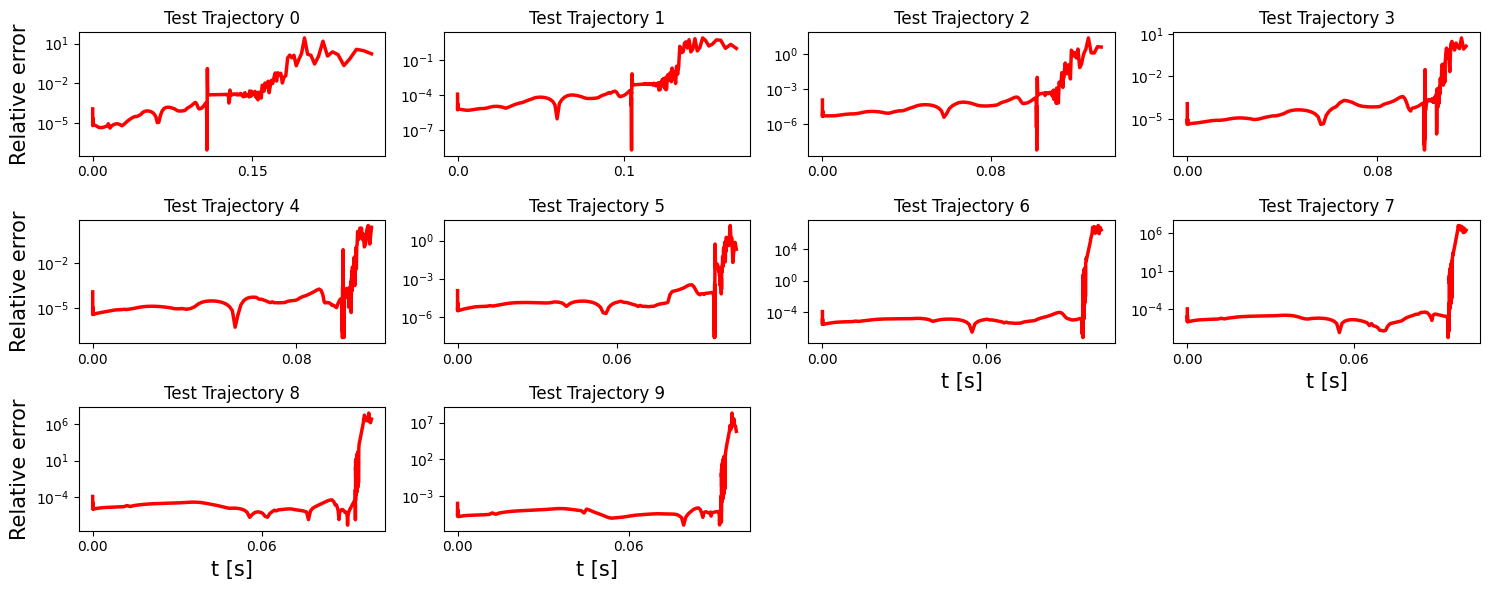

In [32]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled Tabulation/"
name = f"Heuristic PV heu10HO2 - A priori - Relative error - scaled tabulation.png"


num_test_trajectories = 10
rows, cols = 3,4  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(10):  
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu10HO2_source_test = test_trajectory_source["H2O"] + 10 * test_trajectory_source["HO2"]
        PV_heu10HO2_source_test = PV_heu10HO2_source_test.to_numpy()
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    #print(PV_Xu_source_test)
    #print(prediction_test_trajectories[i])
    ax = axes[i]
    relativeError = np.abs(PV_heu10HO2_source_test.flatten() - prediction_test_trajectories_heu10HO2[i].flatten())/np.abs(PV_heu10HO2_source_test.flatten())
    ax.plot(test_trajectory_time, relativeError, color = "red", linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    #ax.set_xscale('log')
    #ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=3))
    #ax.set_xticks([1e-1])  # Define specific tick positions
    #ax.get_xaxis().set_major_formatter(ticker.LogFormatter())
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    ax.set_yscale("log")
    
    if(i>=6):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel("Relative error", fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300)
plt.show()

In [33]:
idx_start_simulation = 0
list_simulations_heu10HO2 = []

list_predicted_timesteps_heu10HO2 = []
list_predicted_PV_heu10HO2 = []
list_predicted_PV_source_heu10HO2 = []

#Get current date and time
now = datetime.now()
date_str = now.strftime("%Y-%m-%d")
time_str = now.strftime("%Hh%M")

print("Date:", date_str)
print("Hour:", time_str)

for i in range(10):

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu10HO2_test = test_trajectory["H2O"] + 10 * test_trajectory["HO2"]
        PV_heu10HO2_test = PV_heu10HO2_test.to_numpy().reshape(-1,1)
        f_PV_heu10HO2_test = np.hstack((np.full(PV_heu10HO2_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_heu10HO2_test))
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    initial_condition = f_PV_heu10HO2_test[idx_start_simulation,:]
    t_coordinates = test_trajectory_time[idx_start_simulation:].to_numpy().ravel()
    
    rhs = RHS_ODE(mixture_fractions_train, PV_heu10HO2_scaled, PV_heu10HO2_source_train, PV_heu10HO2_test.min(), PV_heu10HO2_test.max())
    
    numerical_solution_heu10HO2, info = odeint(rhs, initial_condition.ravel(), t_coordinates, full_output=1)
    list_simulations_heu10HO2.append(numerical_solution_heu10HO2)

    predicted_timesteps = np.array(rhs.t_pred)
    list_predicted_timesteps_heu10HO2.append(predicted_timesteps)

    predicted_PV = np.array(rhs.PV_pred)
    list_predicted_PV_heu10HO2.append(predicted_PV)

    predicted_source_terms = np.array(rhs.PV_source_pred)
    list_predicted_PV_source_heu10HO2.append(predicted_source_terms)

    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu10HO2_source_test = test_trajectory_source["H2O"] + 10 * test_trajectory_source["HO2"]
        PV_heu10HO2_source_test = PV_heu10HO2_source_test.to_numpy()

    MSE_heu10HO2_test_simulation = mean_squared_error(PV_heu10HO2_test[idx_start_simulation:], numerical_solution_heu10HO2[:,1])

    print(f"MSE for test trajectory {i}: {MSE_heu10HO2_test_simulation}")

Date: 2026-05-20
Hour: 12h27
MSE for test trajectory 0: 0.00382003522635447
MSE for test trajectory 1: 0.00492358425666816
MSE for test trajectory 2: 0.0060220613060359765
MSE for test trajectory 3: 0.007067929215075555
MSE for test trajectory 4: 0.008021245503530547
MSE for test trajectory 5: 0.008929528533022847
MSE for test trajectory 6: 0.009667320006005176
MSE for test trajectory 7: 0.010276909781435624
MSE for test trajectory 8: 0.010814459575201689
MSE for test trajectory 9: 0.011437562321806089


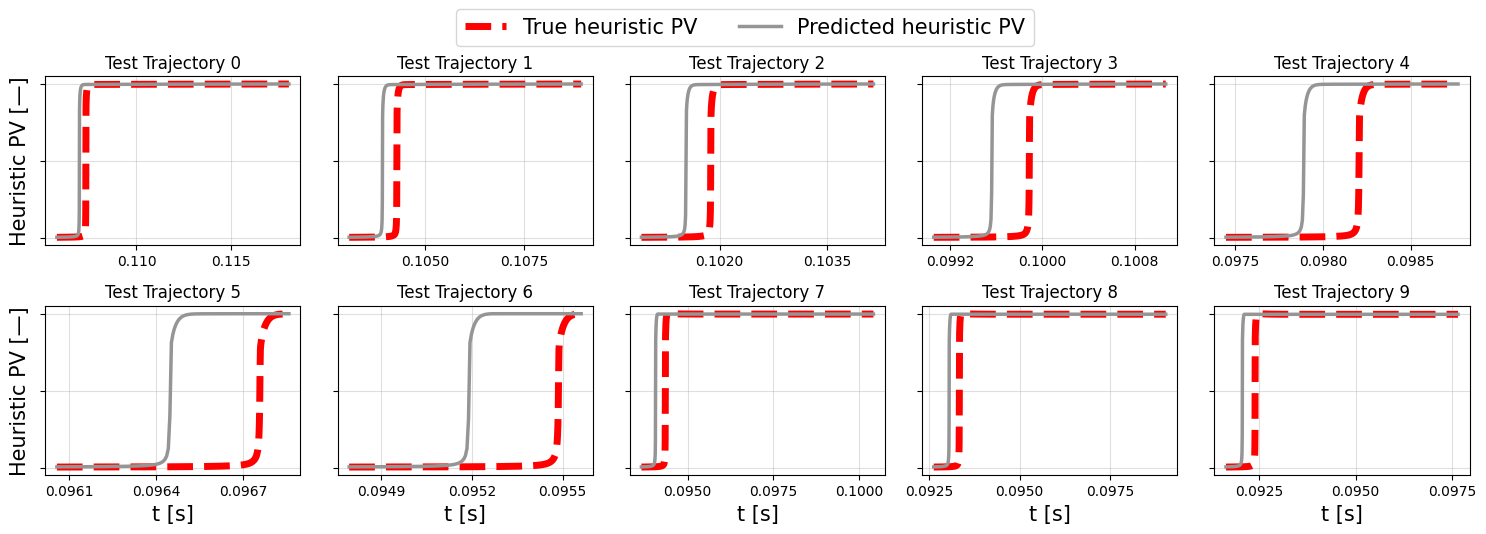

In [34]:
save = False
zoom = True
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled tabulation/"

idx_start_simulation = 0

num_test_trajectories = 10
rows, cols = 2, 5 # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 5))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(num_test_trajectories):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu10HO2_test = test_trajectory["H2O"] + 10 * test_trajectory["HO2"]
        PV_heu10HO2_test = PV_heu10HO2_test.to_numpy().reshape(-1,1)
        #PV_Xu_test = (PV_Xu_test - PV_Xu_test.min())/(PV_Xu_test.max() - PV_Xu_test.min())
        f_PV_heu10HO2_test = np.hstack((np.full(PV_heu10HO2_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_heu10HO2_test))
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
        
    ax = axes[i]

    PV_heu10HO2_test_min = PV_heu10HO2_test.min()
    PV_heu10HO2_test_max = PV_heu10HO2_test.max()

    if(zoom):
        ##############################################
        # Get the first and last index of the ignition
        ##############################################

        H2O_array = test_trajectory["H2O"].to_numpy()

        min_perc = 0.0028
        max_perc = 0.999
        
        max_val = H2O_array.max()
        lower_threshold = min_perc * max_val
        upper_threshold = max_perc * max_val

        idx_1 = np.searchsorted(H2O_array, lower_threshold, side='left')
        idx_99 = np.searchsorted(H2O_array, upper_threshold, side='left')

        ax.plot(test_trajectory_time[idx_1:idx_99], (PV_heu10HO2_test[idx_1:idx_99] - PV_heu10HO2_test_min)/(PV_heu10HO2_test_max - PV_heu10HO2_test_min), label="True heuristic PV", color = "red", linestyle = "--", linewidth = 5)
        ax.plot(test_trajectory_time[idx_1:idx_99], (list_simulations_heu10HO2[i][idx_1:idx_99,1] - PV_heu10HO2_test_min)/(PV_heu10HO2_test_max - PV_heu10HO2_test_min), label="Predicted heuristic PV", color = greys(0.5), linewidth = 2.5)

    else:
        ax.plot(test_trajectory_time[idx_start_simulation:], (PV_heu10HO2_test[idx_start_simulation:] - PV_heu10HO2_test_min)/(PV_heu10HO2_test_max - PV_heu10HO2_test_min), label="True heuristic PV", color = "red", linestyle = "--", linewidth = 5)
        ax.plot(test_trajectory_time[idx_start_simulation:], (list_simulations_heu10HO2[i][:,1] - PV_heu10HO2_test_min)/(PV_heu10HO2_test_max - PV_heu10HO2_test_min), label="Predicted heuristic PV", color = greys(0.5), linewidth = 2.5)
    
    ax.set_title(f"Test Trajectory {i}")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    #ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels([])
    ax.grid(True, linestyle='-', alpha=0.4)
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel('Heuristic PV [\u2014]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

name = f"Heuristic vs optimized - A posteriori - Heuristic PV heu10HO2 - Scaled tabulation{f' - zoom {min_perc}-{max_perc}' if zoom else ''}.png"
namePdf = f"Heuristic vs optimized - A posteriori - Heuristic PV heu10HO2 - Scaled tabulation{f' - zoom {min_perc}-{max_perc}' if zoom else ''}.pdf"

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

## Heuristic PV: H2O + NO

In [35]:
PV_heu1NO_train = state_space_train["H2O"] + state_space_train["NO"]

PV_heu1NO_train = PV_heu1NO_train.to_numpy().reshape(-1,1)
PV_heu1NO_source_train = state_space_source_train["H2O"] + state_space_source_train["NO"]
PV_heu1NO_source_train = PV_heu1NO_source_train.to_numpy().reshape(-1,1)

In [36]:
# Rescale every trajectory from 0 to 1 (each having its own mixture fraction)

df = pd.DataFrame({
    'PV heu1NO': PV_heu1NO_train.squeeze(),
    'mixture_fraction': mixture_fractions_train
})

# Normalize PV within each mixture_fraction group
df['PV_heu1NO_scaled'] = df.groupby('mixture_fraction')['PV heu1NO'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0.0
)

# Get the PV back to numpy
PV_heu1NO_scaled = df['PV_heu1NO_scaled'].to_numpy()

In [37]:
prediction_test_trajectories_heu1NO = []

for i in range(10):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu1NO_test = test_trajectory["H2O"] + test_trajectory["NO"]
        PV_heu1NO_test = PV_heu1NO_test.to_numpy().reshape(-1,1)
        PV_heu1NO_test = (PV_heu1NO_test - PV_heu1NO_test.min())/(PV_heu1NO_test.max() - PV_heu1NO_test.min())
        
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu1NO_source_test = test_trajectory_source["H2O"] + test_trajectory_source["NO"]
        PV_heu1NO_source_test = PV_heu1NO_source_test.to_numpy()
    
    vectorized_predict_PVsource = np.vectorize(
        lambda pv_target: predict_PVsource(mixture_fractions_test[i], pv_target, mixture_fractions_train, PV_heu1NO_scaled, PV_heu1NO_source_train)
    )

    PV_heu1NO_source_test_predicted = vectorized_predict_PVsource(PV_heu1NO_test)
    
    prediction_test_trajectories_heu1NO.append(PV_heu1NO_source_test_predicted)

    MSE_heu1NO_test = mean_squared_error(PV_heu1NO_source_test, PV_heu1NO_source_test_predicted)

    print(f"MSE of heu1NO for test trajectory {i}: {MSE_heu1NO_test}")

MSE of heu1NO for test trajectory 0: 0.0212940635496398
MSE of heu1NO for test trajectory 1: 0.05461310027262512
MSE of heu1NO for test trajectory 2: 0.11082998168790613
MSE of heu1NO for test trajectory 3: 0.1936442569168339
MSE of heu1NO for test trajectory 4: 0.34061616522272886
MSE of heu1NO for test trajectory 5: 0.5144226924746075
MSE of heu1NO for test trajectory 6: 0.7764886183764134
MSE of heu1NO for test trajectory 7: 1.083190501437379
MSE of heu1NO for test trajectory 8: 1.422818239460425
MSE of heu1NO for test trajectory 9: 1.7137159984403412


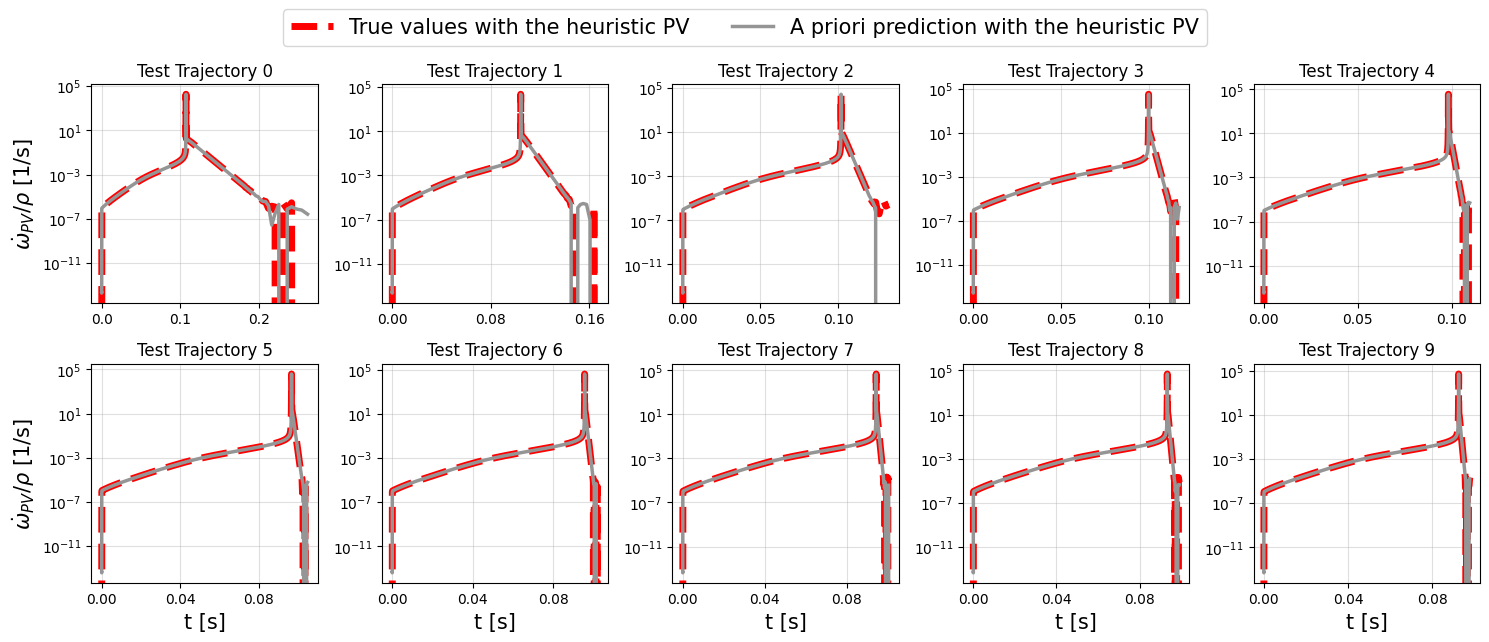

In [38]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled Tabulation/"
name = "Heuristic PV heu1NO - A priori - Scaled tabulation"
namePdf = "Heuristic PV heu1NO - A priori - Scaled tabulation.pdf"

num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(num_test_trajectories):  
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu1NO_source_test = test_trajectory_source["H2O"] + test_trajectory_source["NO"]
        PV_heu1NO_source_test = PV_heu1NO_source_test.to_numpy()
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    #print(PV_Xu_source_test)
    #print(prediction_test_trajectories[i])
    ax = axes[i]
    ax.plot(test_trajectory_time, PV_heu1NO_source_test, label="True values with the heuristic PV", color = "red", linestyle = "--", linewidth = 5)
    ax.plot(test_trajectory_time, prediction_test_trajectories_heu1NO[i], label="A priori prediction with the heuristic PV", color = greys(0.5), linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    ax.set_yscale("log")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.grid(True, linestyle='-', alpha=0.4)
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel(r'$\dot{\omega}_{PV} / \rho$ [1/s]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

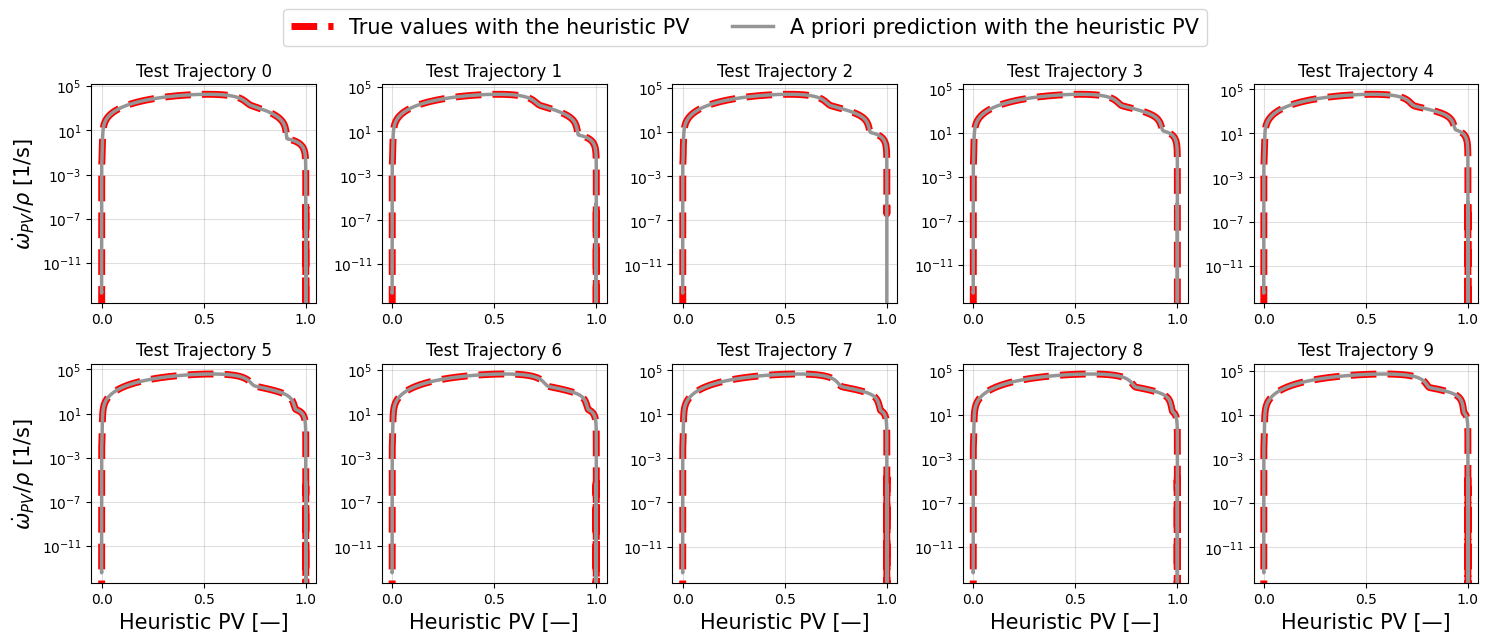

In [39]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled Tabulation/"
name = "Heuristic PV heu1NO - A priori - PV on x-axis - Scaled tabulation"


num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(num_test_trajectories): 

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu1NO_test = test_trajectory["H2O"] + test_trajectory["NO"]
        PV_heu1NO_test = PV_heu1NO_test.to_numpy().reshape(-1,1)
        PV_heu1NO_test = (PV_heu1NO_test - PV_heu1NO_test.min())/(PV_heu1NO_test.max() - PV_heu1NO_test.min())

    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu1NO_source_test = test_trajectory_source["H2O"] + test_trajectory_source["NO"]
        PV_heu1NO_source_test = PV_heu1NO_source_test.to_numpy()
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    #print(PV_Xu_source_test)
    #print(prediction_test_trajectories[i])
    ax = axes[i]
    ax.plot(PV_heu1NO_test, PV_heu1NO_source_test, label="True values with the heuristic PV", color = "red", linestyle = "--", linewidth = 5)
    ax.plot(PV_heu1NO_test, prediction_test_trajectories_heu1NO[i], label="A priori prediction with the heuristic PV", color = greys(0.5), linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    ax.set_yscale("log")
    ax.set_xticks([0, 0.5, 1])
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.grid(True, linestyle='-', alpha=0.4)
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"Heuristic PV [\u2014]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel(r'$\dot{\omega}_{PV} / \rho$ [1/s]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
plt.show()

In [40]:
num_test_trajectories = 9
start_of_traj = False

prediction_heu1NO = []
true_heu1NO = []

for i in range(num_test_trajectories): 

    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu1NO_source_test = test_trajectory_source["H2O"] + test_trajectory_source["NO"]
        PV_heu1NO_source_test = PV_heu1NO_source_test.to_numpy()

    H2O_array = test_trajectory["H2O"].to_numpy()

    max_perc = 0.995
    
    max_val = H2O_array.max()
    upper_threshold = max_perc * max_val
    idx_99 = np.searchsorted(H2O_array, upper_threshold, side='left')

    if(not start_of_traj):
        idx_99 = len(prediction_test_trajectories_heu1NO[i])

    prediction_heu1NO.append(prediction_test_trajectories_heu1NO[i][:idx_99])
    true_heu1NO.append(PV_heu1NO_source_test.reshape((-1, 1))[:idx_99])

prediction_heu1NO = np.vstack(prediction_heu1NO)
true_heu1NO = np.vstack(true_heu1NO)

print(f"Loss (logScaledMSE) for the heuristic PV - A priori prediction of PV source: {compute_logScaledMSE(true_heu1NO, prediction_heu1NO)}")

PV_source_heu1NO_min = true_heu1NO.min()
PV_source_heu1NO_max = true_heu1NO.max()

prediction_heu1NO = (prediction_heu1NO - PV_source_heu1NO_min)/(PV_source_heu1NO_max - PV_source_heu1NO_min)
true_heu1NO = (true_heu1NO - PV_source_heu1NO_min)/(PV_source_heu1NO_max - PV_source_heu1NO_min)

MSE_heu1NO = np.mean((prediction_heu1NO - true_heu1NO) ** 2)

print(f"Loss (MSE) for the heuristic PV - A priori prediction of PV source: {MSE_heu1NO}")

mask = true_heu1NO>0

relative_error_heu1NO = np.abs(prediction_heu1NO[mask] - true_heu1NO[mask]) / np.abs(true_heu1NO[mask])
mean_relative_error_heu1NO = np.mean(relative_error_heu1NO)

print(f"Loss (relative error) for the heuristic PV heu1NO - A priori prediction of PV source: {mean_relative_error_heu1NO}")

Loss (logScaledMSE) for the heuristic PV - A priori prediction of PV source: 1.5932261926571461e-06
Loss (MSE) for the heuristic PV - A priori prediction of PV source: 2.1890222668113466e-10
Loss (relative error) for the heuristic PV heu1NO - A priori prediction of PV source: 0.002770623598733372


C:\Windows\Temp\ipykernel_1704\2487335992.py:26: RuntimeWarning: divide by zero encountered in divide
  relativeError = np.abs(PV_heu1NO_source_test.flatten() - prediction_test_trajectories_heu1NO[i].flatten())/np.abs(PV_heu1NO_source_test.flatten())
C:\Windows\Temp\ipykernel_1704\2487335992.py:26: RuntimeWarning: divide by zero encountered in divide
  relativeError = np.abs(PV_heu1NO_source_test.flatten() - prediction_test_trajectories_heu1NO[i].flatten())/np.abs(PV_heu1NO_source_test.flatten())
C:\Windows\Temp\ipykernel_1704\2487335992.py:26: RuntimeWarning: divide by zero encountered in divide
  relativeError = np.abs(PV_heu1NO_source_test.flatten() - prediction_test_trajectories_heu1NO[i].flatten())/np.abs(PV_heu1NO_source_test.flatten())
C:\Windows\Temp\ipykernel_1704\2487335992.py:26: RuntimeWarning: divide by zero encountered in divide
  relativeError = np.abs(PV_heu1NO_source_test.flatten() - prediction_test_trajectories_heu1NO[i].flatten())/np.abs(PV_heu1NO_source_test.flatten

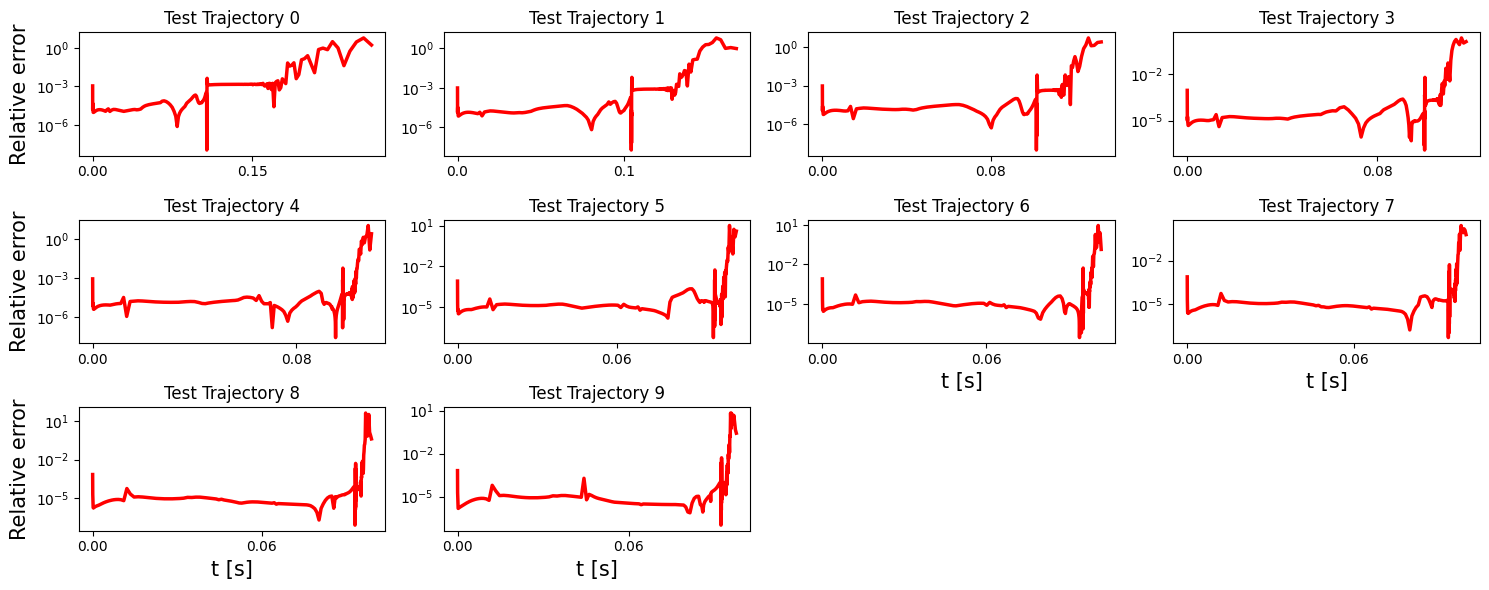

In [41]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled Tabulation/"
name = f"Heuristic PV heu1NO - A priori - Relative error - scaled tabulation.png"


num_test_trajectories = 10
rows, cols = 3,4  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(10):  
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu1NO_source_test = test_trajectory_source["H2O"] + test_trajectory_source["NO"]
        PV_heu1NO_source_test = PV_heu1NO_source_test.to_numpy()
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    #print(PV_Xu_source_test)
    #print(prediction_test_trajectories[i])
    ax = axes[i]
    relativeError = np.abs(PV_heu1NO_source_test.flatten() - prediction_test_trajectories_heu1NO[i].flatten())/np.abs(PV_heu1NO_source_test.flatten())
    ax.plot(test_trajectory_time, relativeError, color = "red", linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    #ax.set_xscale('log')
    #ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=3))
    #ax.set_xticks([1e-1])  # Define specific tick positions
    #ax.get_xaxis().set_major_formatter(ticker.LogFormatter())
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    ax.set_yscale("log")
    
    if(i>=6):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel("Relative error", fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300)
plt.show()

In [42]:
idx_start_simulation = 0
list_simulations_heu1NO = []

list_predicted_timesteps_heu1NO = []
list_predicted_PV_heu1NO = []
list_predicted_PV_source_heu1NO = []

#Get current date and time
now = datetime.now()
date_str = now.strftime("%Y-%m-%d")
time_str = now.strftime("%Hh%M")

print("Date:", date_str)
print("Hour:", time_str)

for i in range(10):

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu1NO_test = test_trajectory["H2O"] + test_trajectory["NO"]
        PV_heu1NO_test = PV_heu1NO_test.to_numpy().reshape(-1,1)
        f_PV_heu1NO_test = np.hstack((np.full(PV_heu1NO_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_heu1NO_test))
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    initial_condition = f_PV_heu1NO_test[idx_start_simulation,:]
    t_coordinates = test_trajectory_time[idx_start_simulation:].to_numpy().ravel()
    
    rhs = RHS_ODE(mixture_fractions_train, PV_heu1NO_scaled, PV_heu1NO_source_train, PV_heu1NO_test.min(), PV_heu1NO_test.max())
    
    numerical_solution_heu1NO, info = odeint(rhs, initial_condition.ravel(), t_coordinates, full_output=1)
    list_simulations_heu1NO.append(numerical_solution_heu1NO)

    predicted_timesteps = np.array(rhs.t_pred)
    list_predicted_timesteps_heu1NO.append(predicted_timesteps)

    predicted_PV = np.array(rhs.PV_pred)
    list_predicted_PV_heu1NO.append(predicted_PV)

    predicted_source_terms = np.array(rhs.PV_source_pred)
    list_predicted_PV_source_heu1NO.append(predicted_source_terms)

    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu1NO_source_test = test_trajectory_source["H2O"] + test_trajectory_source["NO"]
        PV_heu1NO_source_test = PV_heu1NO_source_test.to_numpy()

    MSE_heu1NO_test_simulation = mean_squared_error(PV_heu1NO_test[idx_start_simulation:], numerical_solution_heu1NO[:,1])

    print(f"MSE for test trajectory {i}: {MSE_heu1NO_test_simulation}")

Date: 2026-05-20
Hour: 12h29
MSE for test trajectory 0: 0.005540911577287372
MSE for test trajectory 1: 0.0076482249678839
MSE for test trajectory 2: 0.009356537126318292
MSE for test trajectory 3: 0.010749184449773633
MSE for test trajectory 4: 0.011826172111068208
MSE for test trajectory 5: 0.012729072740380779
MSE for test trajectory 6: 0.01348847235497269
MSE for test trajectory 7: 0.01377009566828461
MSE for test trajectory 8: 0.014218869371794205
MSE for test trajectory 9: 0.014537250974605257


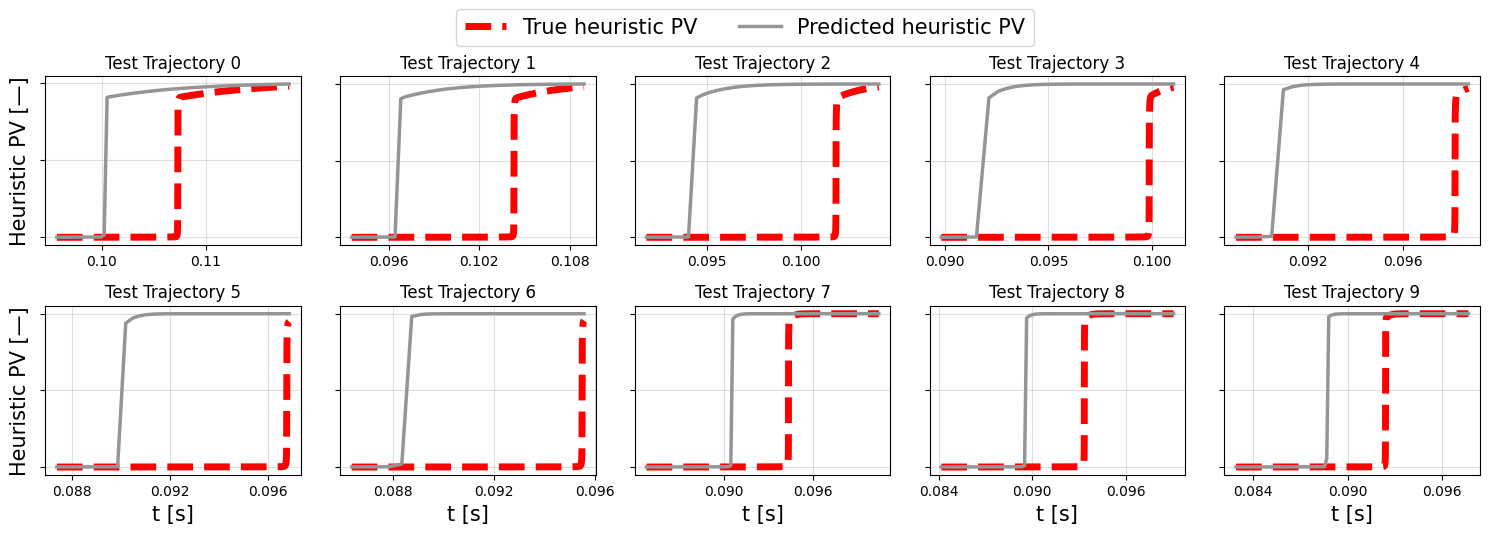

In [43]:
save = False
zoom = True
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled tabulation/"

idx_start_simulation = 0

num_test_trajectories = 10
rows, cols = 2, 5 # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 5))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(num_test_trajectories):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_heu1NO_test = test_trajectory["H2O"] + test_trajectory["NO"]
        PV_heu1NO_test = PV_heu1NO_test.to_numpy().reshape(-1,1)
        #PV_Xu_test = (PV_Xu_test - PV_Xu_test.min())/(PV_Xu_test.max() - PV_Xu_test.min())
        f_PV_heu1NO_test = np.hstack((np.full(PV_heu1NO_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_heu1NO_test))
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
        
    ax = axes[i]

    PV_heu1NO_test_min = PV_heu1NO_test.min()
    PV_heu1NO_test_max = PV_heu1NO_test.max()

    if(zoom):
        ##############################################
        # Get the first and last index of the ignition
        ##############################################

        H2O_array = test_trajectory["H2O"].to_numpy()

        min_perc = 0.001 #0.0028
        max_perc = 0.999
        
        max_val = H2O_array.max()
        lower_threshold = min_perc * max_val
        upper_threshold = max_perc * max_val

        idx_1 = np.searchsorted(H2O_array, lower_threshold, side='left')
        idx_99 = np.searchsorted(H2O_array, upper_threshold, side='left')

        ax.plot(test_trajectory_time[idx_1:idx_99], (PV_heu1NO_test[idx_1:idx_99] - PV_heu1NO_test_min)/(PV_heu1NO_test_max - PV_heu1NO_test_min), label="True heuristic PV", color = "red", linestyle = "--", linewidth = 5)
        ax.plot(test_trajectory_time[idx_1:idx_99], (list_simulations_heu1NO[i][idx_1:idx_99,1] - PV_heu1NO_test_min)/(PV_heu1NO_test_max - PV_heu1NO_test_min), label="Predicted heuristic PV", color = greys(0.5), linewidth = 2.5)

    else:
        ax.plot(test_trajectory_time[idx_start_simulation:], (PV_heu1NO_test[idx_start_simulation:] - PV_heu1NO_test_min)/(PV_heu1NO_test_max - PV_heu1NO_test_min), label="True heuristic PV", color = "red", linestyle = "--", linewidth = 5)
        ax.plot(test_trajectory_time[idx_start_simulation:], (list_simulations_heu1NO[i][:,1] - PV_heu1NO_test_min)/(PV_heu1NO_test_max - PV_heu1NO_test_min), label="Predicted heuristic PV", color = greys(0.5), linewidth = 2.5)
    
    ax.set_title(f"Test Trajectory {i}")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    #ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels([])
    ax.grid(True, linestyle='-', alpha=0.4)
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel('Heuristic PV [\u2014]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

name = f"Heuristic vs optimized - A posteriori - Heuristic PV heu1NO - Scaled tabulation{f' - zoom {min_perc}-{max_perc}' if zoom else ''}.png"
namePdf = f"Heuristic vs optimized - A posteriori - Heuristic PV heu1NO - Scaled tabulation{f' - zoom {min_perc}-{max_perc}' if zoom else ''}.pdf"

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

## Optimized PV

In [44]:
filename_model = "Xu-AE-opt_adam-epo_100000-lr_0.025-date_24Mar2025-hour_10h50_Tr0D-2s_s2"

filename_metadata = filename_model + "_metadata.pkl"
path_metadata = "metadata/"
filename_species_names = "Xu-state-space-names.csv"
path_data = "data-files/"

loader = loadData(filename_species_names, path_metadata, filename_metadata)
idx_species_removed = loader.metadata["list idx species removed source"] if loader.metadata["dataset_type"].startswith("autoignition_augm") else loader.metadata["idx species removed"]
id_model = loader.metadata["Training_id"]
PV_model = loader.loadModel()

weight_inversion = False
if(weight_inversion):
    with torch.no_grad():  # Ensures we do not track gradients for this operation
        PV_model.encoder_species.weight.mul_(-1)

state_space_names_DNS = np.genfromtxt(f"{path_data}Xu-state-space-names.csv", delimiter=",", dtype=str)

#create a np array in the format for the DNS dataset/optimized PV
state_space_train_DNS = state_space_train[state_space_names_DNS].to_numpy()
state_space_source_train_DNS = state_space_source_train[state_space_names_DNS].to_numpy()
print(state_space_source_train_DNS.shape)

PV_optimized_train = PV_model.get_PV(torch.from_numpy(np.delete(state_space_train_DNS, idx_species_removed, axis=1))).detach().numpy()

# Rescale every trajectory from 0 to 1 (each having its own mixture fraction)

df = pd.DataFrame({
    'PV optimized': PV_optimized_train.squeeze(),
    'mixture_fraction': mixture_fractions_train
})

# Normalize PV within each mixture_fraction group
df['PV_optimized_scaled'] = df.groupby('mixture_fraction')['PV optimized'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0.0
)

# Get the PV back to numpy
PV_optimized_scaled = df['PV_optimized_scaled'].to_numpy()

PV_optimized_source_train = PV_model.get_PV(torch.from_numpy(np.delete(state_space_source_train_DNS, idx_species_removed, axis=1))).detach().numpy()

(241519, 21)


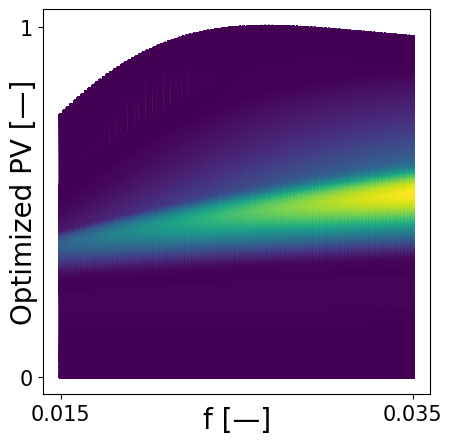

In [45]:
save = False
scaled = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/f-PV manifold/"
name = f"Optimized PV - {'Scaled ' if scaled else ''} f-PV manifold - PV source as color - PRESENTATION"

PV_data = (PV_optimized_train - PV_optimized_train.min())/(PV_optimized_train.max() - PV_optimized_train.min())
if(scaled):
    PV_data = PV_optimized_scaled

fig, ax = plt.subplots(figsize = (5, 5))
# Ensure the the processing has been done correctly
plt.scatter(mixture_fractions_train, PV_data, c=PV_optimized_source_train, s=3)
# cbar = plt.colorbar()
# cbar.set_ticks([0, 175000])
# cbar.ax.tick_params(labelsize = 12)
# cbar.set_label(r'$\dot{\omega}_{PV} / \rho$ [1/s]', fontsize=17, labelpad = -7)
# class CustomScalarFormatter(ScalarFormatter):
#     def __init__(self, useOffset=True, useMathText=False):
#         super().__init__(useOffset=useOffset, useMathText=useMathText)

#     def __call__(self, x, pos=None):
#         # If the value is zero, format it as "0" instead of "0.00"
#         if x == 0:
#             return "0"
#         else:
#             return super().__call__(x, pos)

# formatter2 = CustomScalarFormatter(useMathText=True)
# formatter2.set_powerlimits((0, 0))
# cbar.ax.yaxis.set_major_formatter(formatter2)
# offset_text = cbar.ax.yaxis.get_offset_text()
# offset_text.set_x(offset_text.get_position()[0] + 0.5)
plt.xlabel("f [\u2014]", fontsize = 20, labelpad=-13)
plt.xticks([0.015, 0.035], fontsize = 15)
if(not scaled):
    plt.ylabel("Optimized PV [\u2014]", fontsize = 20, labelpad=-13)
else:
    ax.set_yticklabels([])
plt.yticks([0, 1], fontsize = 15)
if(save):
    plt.savefig(pathSave + name, dpi = 300, bbox_inches = "tight")
plt.show()

In [46]:
prediction_test_trajectories_optimized = []

for i in range(10):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_test_DNS = test_trajectory[state_space_names_DNS].to_numpy()
        
        PV_optimized_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_test_DNS, idx_species_removed, axis=1))).detach().numpy()
        PV_optimized_test = (PV_optimized_test - PV_optimized_test.min())/(PV_optimized_test.max() - PV_optimized_test.min())
    
         
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_source_test_DNS = test_trajectory_source[state_space_names_DNS].to_numpy()
        PV_optimized_source_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_source_test_DNS, idx_species_removed, axis=1))).detach().numpy()
    
    vectorized_predict_PVsource = np.vectorize(
        lambda pv_target: predict_PVsource(mixture_fractions_test[i], pv_target, mixture_fractions_train, PV_optimized_scaled, PV_optimized_source_train)
    )

    PV_optimized_source_test_predicted = vectorized_predict_PVsource(PV_optimized_test)
    
    prediction_test_trajectories_optimized.append(PV_optimized_source_test_predicted)

    MSE_optimized_test = mean_squared_error(PV_optimized_source_test, PV_optimized_source_test_predicted)

    print(f"MSE of optimized PV for test trajectory {i}: {MSE_optimized_test}")

MSE of optimized PV for test trajectory 0: 8950.768711002545
MSE of optimized PV for test trajectory 1: 966.3528983897475
MSE of optimized PV for test trajectory 2: 405.4816585705686
MSE of optimized PV for test trajectory 3: 421.3531319310963
MSE of optimized PV for test trajectory 4: 552.8684983552902
MSE of optimized PV for test trajectory 5: 798.5971693297101
MSE of optimized PV for test trajectory 6: 937.5382235002883
MSE of optimized PV for test trajectory 7: 886.675069129983
MSE of optimized PV for test trajectory 8: 721.7787963473903
MSE of optimized PV for test trajectory 9: 513.6445324144951


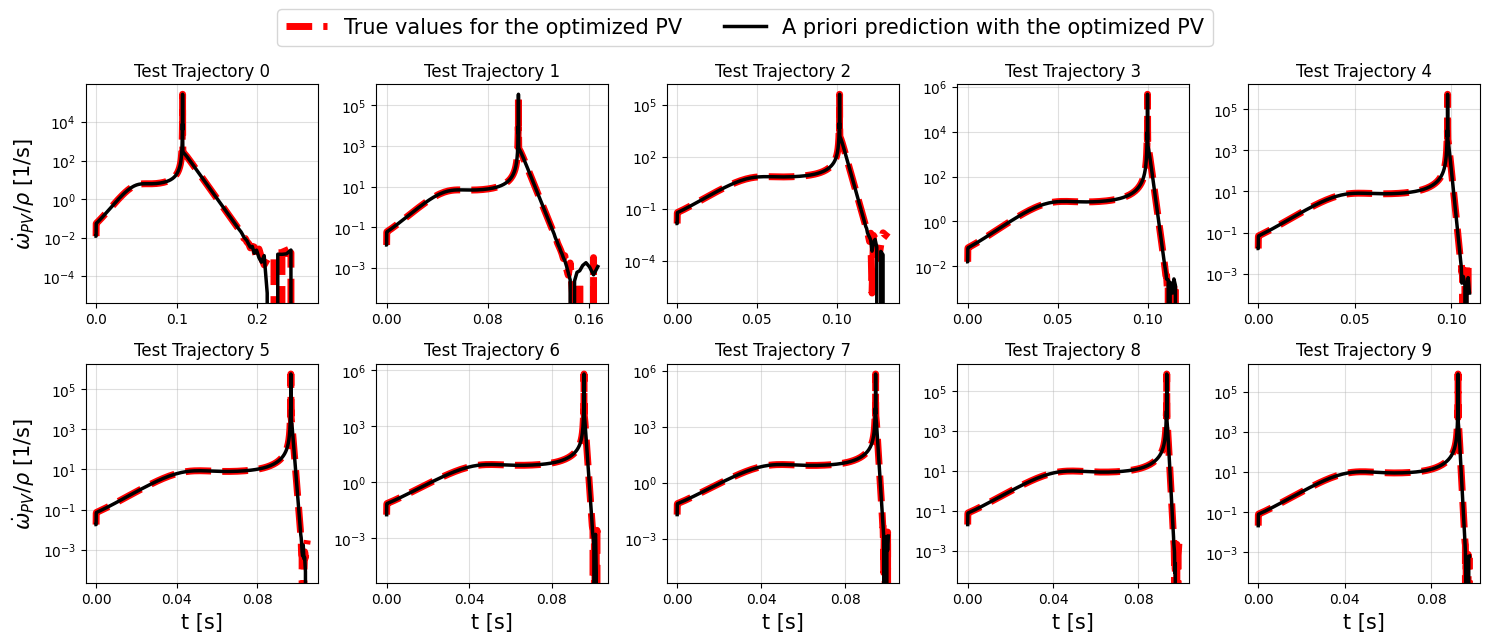

In [47]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled tabulation/"
name = f"Optimized {id_model} - A priori - Scaled abulation.png"
namePdf = f"Optimized {id_model} - A priori - Scaled abulation.pdf"

num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(num_test_trajectories):
    #print(f"\nIteration {i}")
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_source_test_DNS = test_trajectory_source[state_space_names_DNS].to_numpy()
        PV_optimized_source_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_source_test_DNS, idx_species_removed, axis=1))).detach().numpy()

    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
        
    ax = axes[i]
    ax.plot(test_trajectory_time, PV_optimized_source_test, label="True values for the optimized PV", color = "red", linestyle = "--", linewidth = 5)
    ax.plot(test_trajectory_time, prediction_test_trajectories_optimized[i], label="A priori prediction with the optimized PV", color = "k", linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    ax.set_yscale("log")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.grid(True, linestyle='-', alpha=0.4)
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel(r'$\dot{\omega}_{PV} / \rho$ [1/s]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

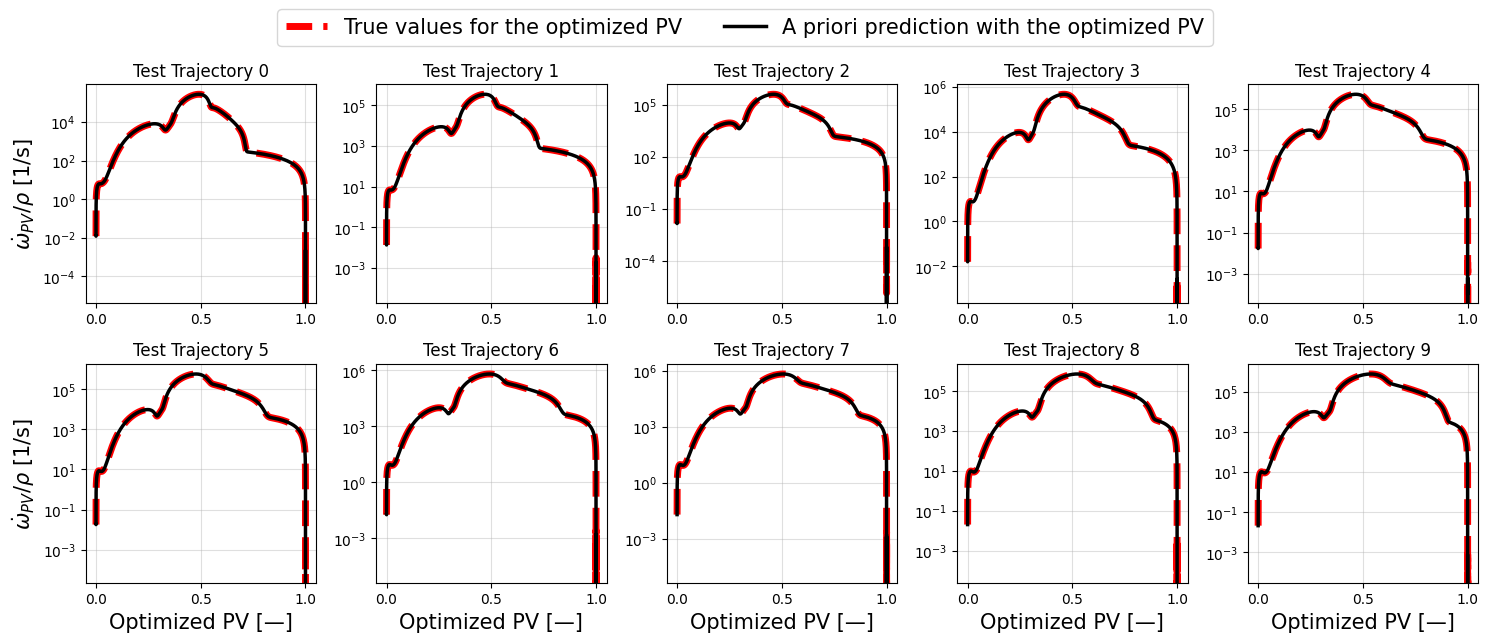

In [48]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled tabulation/"
name = "Optimized PV - A priori - PV on x-axis - Scaled tabulation"

num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(num_test_trajectories):
    #print(f"\nIteration {i}")

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_test_DNS = test_trajectory[state_space_names_DNS].to_numpy()
        
        PV_optimized_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_test_DNS, idx_species_removed, axis=1))).detach().numpy()
        PV_optimized_test = (PV_optimized_test - PV_optimized_test.min())/(PV_optimized_test.max() - PV_optimized_test.min())

    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_source_test_DNS = test_trajectory_source[state_space_names_DNS].to_numpy()
        PV_optimized_source_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_source_test_DNS, idx_species_removed, axis=1))).detach().numpy()

    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
        
    ax = axes[i]
    ax.plot(PV_optimized_test, PV_optimized_source_test, label="True values for the optimized PV", color = "red", linestyle = "--", linewidth = 5)
    ax.plot(PV_optimized_test, prediction_test_trajectories_optimized[i], label="A priori prediction with the optimized PV", color = "k", linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    ax.set_yscale("log")
    ax.set_xticks([0, 0.5, 1])
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.grid(True, linestyle='-', alpha=0.4)
    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"Optimized PV [\u2014]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel(r'$\dot{\omega}_{PV} / \rho$ [1/s]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
plt.show()

In [49]:
num_test_trajectories = 10
start_of_traj = True

prediction_optimized = []
true_optimized = []

for i in range(num_test_trajectories): 

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_source_test_DNS = test_trajectory_source[state_space_names_DNS].to_numpy()
        PV_optimized_source_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_source_test_DNS, idx_species_removed, axis=1))).detach().numpy()
    
    H2O_array = test_trajectory["H2O"].to_numpy()

    max_perc = 0.995
    
    max_val = H2O_array.max()
    upper_threshold = max_perc * max_val
    idx_99 = np.searchsorted(H2O_array, upper_threshold, side='left')

    if(not start_of_traj):
        idx_99 = len(prediction_test_trajectories_optimized[i])

    prediction_optimized.append(prediction_test_trajectories_optimized[i][:idx_99])
    true_optimized.append(PV_optimized_source_test.reshape((-1, 1))[:idx_99])

prediction_optimized = np.vstack(prediction_optimized)
true_optimized = np.vstack(true_optimized)

print(f"Loss for the optimized PV - A priori prediction of PV source: {compute_logScaledMSE(true_optimized, prediction_optimized)}")

PV_source_optimized_min = true_optimized.min()
PV_source_optimized_max = true_optimized.max()

prediction_optimized = (prediction_optimized - PV_source_optimized_min)/(PV_source_optimized_max - PV_source_optimized_min)
true_optimized = (true_optimized - PV_source_optimized_min)/(PV_source_optimized_max - PV_source_optimized_min)

MSE_optimized = np.mean((prediction_optimized - true_optimized) ** 2)

print(f"Loss (MSE) for the optimized PV - A priori prediction of PV source: {MSE_optimized}")

mask = true_optimized>0

relative_error_optimized = np.abs(prediction_optimized[mask] - true_optimized[mask]) / np.abs(true_optimized[mask])
mean_relative_error_optimized = np.mean(relative_error_optimized)

print(f"Loss (relative error) for the optimized PV - A priori prediction of PV source: {mean_relative_error_optimized}")

Loss for the optimized PV - A priori prediction of PV source: 1.942692142641306e-09
Loss (MSE) for the optimized PV - A priori prediction of PV source: 3.0025089694598614e-09
Loss (relative error) for the optimized PV - A priori prediction of PV source: 0.0002944761877653469


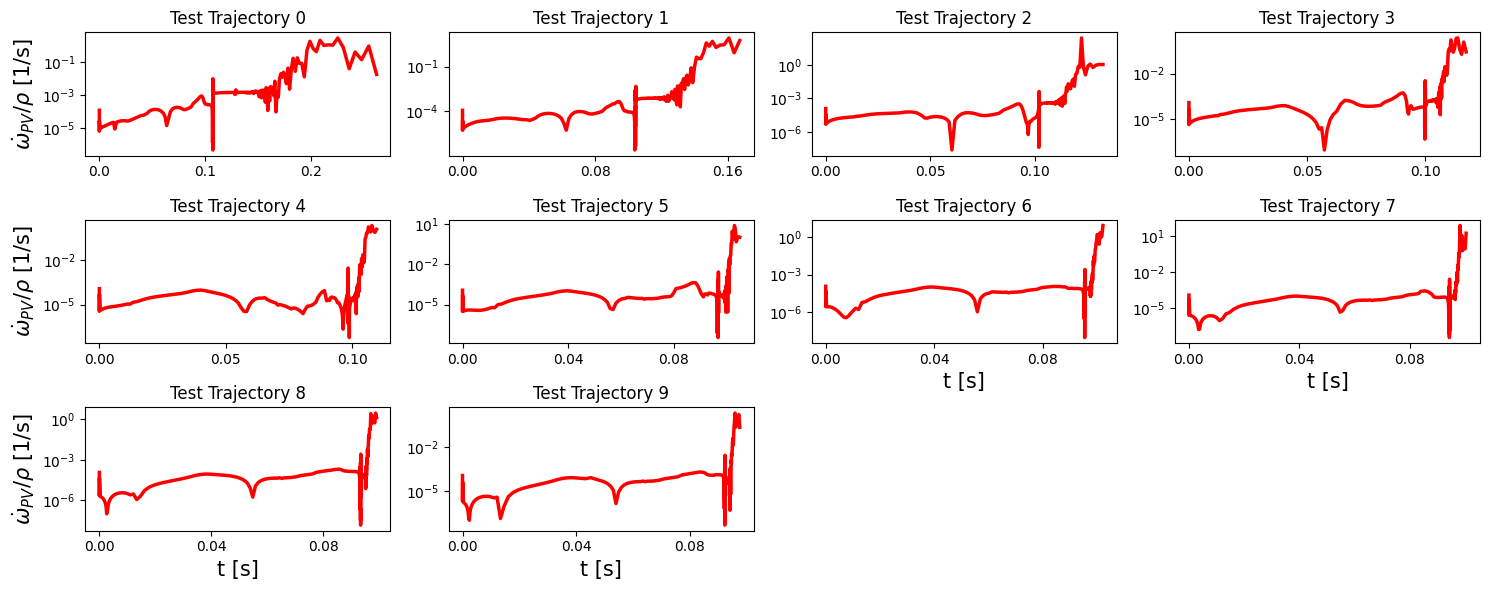

In [50]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled tabulation/"
name = f"Optimized PV {id_model} - A priori - Relative error - scaled tabulation.png"

num_test_trajectories = 10
rows, cols = 3,4  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(10):
    #print(f"\nIteration {i}")
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_source_test_DNS = test_trajectory_source[state_space_names_DNS].to_numpy()
        PV_optimized_source_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_source_test_DNS, idx_species_removed, axis=1))).detach().numpy()
        #print(f"True: {PV_optimized_source_test.min()}")
    
    #print(f"Pred: {prediction_test_trajectories_optimized[i].min()}")
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
        
    ax = axes[i]
    relError = np.abs(prediction_test_trajectories_optimized[i].flatten() - PV_optimized_source_test.flatten())/np.abs(PV_optimized_source_test.flatten())
    ax.plot(test_trajectory_time, relError, color = "red", linewidth = 2.5)
    ax.set_title(f"Test Trajectory {i}")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    ax.set_yscale("log")
    
    if(i>=6):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel(r'$\dot{\omega}_{PV} / \rho$ [1/s]', fontsize = 15)

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300)
plt.show()

C:\Windows\Temp\ipykernel_1704\35563599.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  greys = cm.get_cmap('Greys')


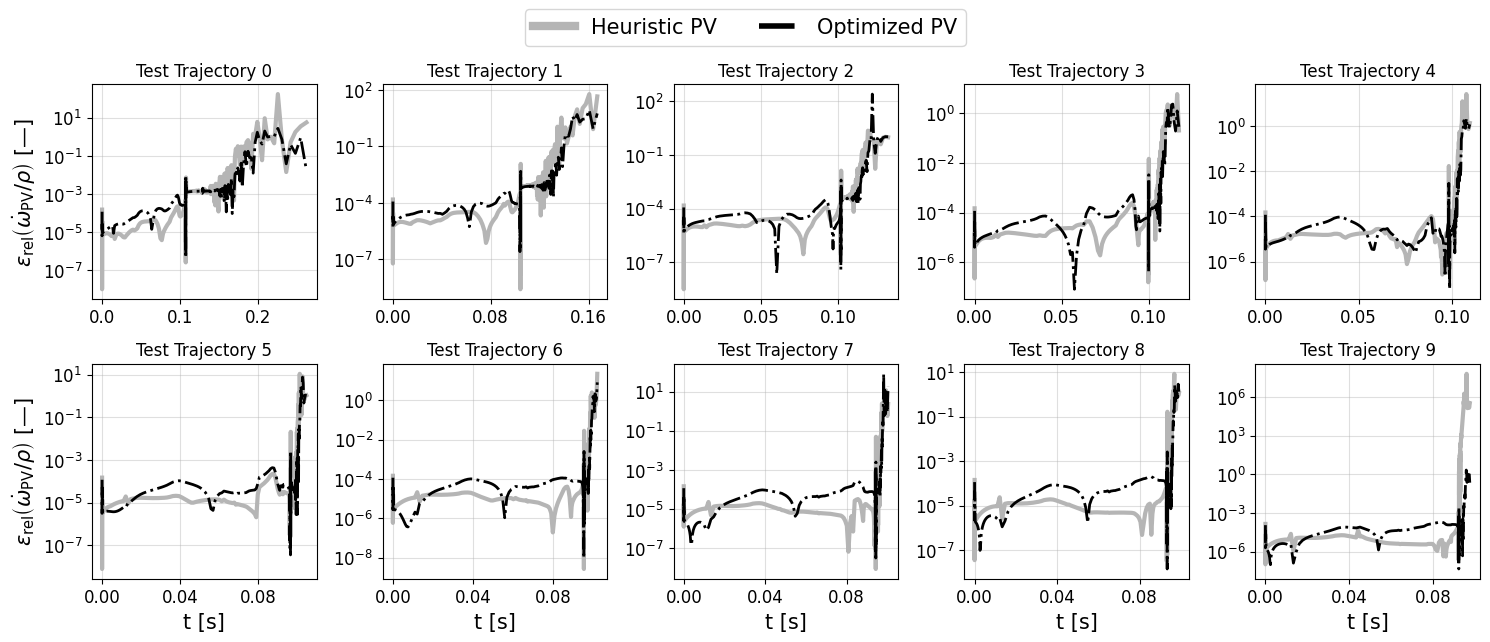

In [51]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled tabulation/"
name = f"Heuristic vs optimized {id_model} - A priori - relative Error comparison - Scaled tabulation"
namePdf = f"Heuristic vs optimized {id_model} - A priori - relative Error comparison - Scaled tabulation.pdf"

num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 6))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

greys = cm.get_cmap('Greys')

for i in range(num_test_trajectories):
    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_source_test_DNS = test_trajectory_source[state_space_names_DNS].to_numpy()
        PV_optimized_source_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_source_test_DNS, idx_species_removed, axis=1))).detach().numpy()
        
        PV_Xu_source_test = test_trajectory_source["H2O"] - test_trajectory_source["H2"] - test_trajectory_source["O2"]
        PV_Xu_source_test = PV_Xu_source_test.to_numpy()

    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
        
    ax = axes[i]
    relativeErrorXu = np.abs(PV_Xu_source_test.flatten() - prediction_test_trajectories[i].flatten())/np.abs(PV_Xu_source_test.flatten())
    relErrorOptimized = np.abs(prediction_test_trajectories_optimized[i].flatten() - PV_optimized_source_test.flatten())/np.abs(PV_optimized_source_test.flatten())
    ax.plot(test_trajectory_time, relativeErrorXu, label = "Heuristic PV", color = greys(0.4), linewidth = 3, linestyle = "-")
    ax.plot(test_trajectory_time, relErrorOptimized, label = "Optimized PV", color = "k", linewidth = 2, linestyle = "-.")
    ax.set_title(f"Test Trajectory {i}")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.set_yscale("log")
    ax.tick_params(axis='both', labelsize=12)
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
    ax.grid(True, linestyle='-', alpha=0.4)

    
    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel(r"$\epsilon_{\mathrm{rel}}\left( \dot{\omega}_{\mathrm{PV}} / \rho \right)$" + " [\u2014]", fontsize=15)

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 2,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

## A posteriori simulations

In [52]:
idx_start_simulation = 0
list_simulations_optimized = []

list_predicted_timesteps_optimized = []
list_predicted_PV_optimized = []
list_predicted_PV_source_optimized = []

#Get current date and time
now = datetime.now()
date_str = now.strftime("%Y-%m-%d")
time_str = now.strftime("%Hh%M")

for i in range(10):

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_test_DNS = test_trajectory[state_space_names_DNS].to_numpy()
        
        PV_optimized_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_test_DNS, idx_species_removed, axis=1))).detach().numpy()
        f_PV_optimized_test = np.hstack((np.full(PV_optimized_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_optimized_test.reshape(-1,1)))
    
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])

    initial_condition = f_PV_optimized_test[idx_start_simulation,:]
    t_coordinates = test_trajectory_time[idx_start_simulation:].to_numpy().ravel()
    

    rhs = RHS_ODE(
        mixture_fractions_train,
        PV_optimized_scaled,
        PV_optimized_source_train,
        PV_optimized_test.min(),
        PV_optimized_test.max()
    )

    # Run the ODE solver using the wrapped function
    numerical_solution_optimized, info = odeint(
        rhs,
        initial_condition.ravel(),
        t_coordinates,
        full_output=1
    )

    # Save the simulation result
    list_simulations_optimized.append(numerical_solution_optimized)

    predicted_timesteps = np.array(rhs.t_pred)
    list_predicted_timesteps_optimized.append(predicted_timesteps)

    predicted_PV = np.array(rhs.PV_pred)
    list_predicted_PV_optimized.append(predicted_PV)

    predicted_source_terms = np.array(rhs.PV_source_pred)
    list_predicted_PV_source_optimized.append(predicted_source_terms)

    #test source terms
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
        test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_source_test_DNS = test_trajectory_source[state_space_names_DNS].to_numpy()
        PV_optimized_source_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_source_test_DNS, idx_species_removed, axis=1))).detach().numpy()
        
    MSE_optimized_test_simulation = mean_squared_error(PV_optimized_test[idx_start_simulation:], numerical_solution_optimized[:, 1])

    print(f"MSE for test trajectory {i}: {MSE_optimized_test_simulation}")

MSE for test trajectory 0: 0.32673654021761744
MSE for test trajectory 1: 0.5694647431064624
MSE for test trajectory 2: 0.7603446777627578
MSE for test trajectory 3: 0.9737750115533644
MSE for test trajectory 4: 1.3582852017551705
MSE for test trajectory 5: 1.4179279980476038
MSE for test trajectory 6: 1.4622814688564805
MSE for test trajectory 7: 1.7521869506671168
MSE for test trajectory 8: 1.641899752862957
MSE for test trajectory 9: 1.880325203062499


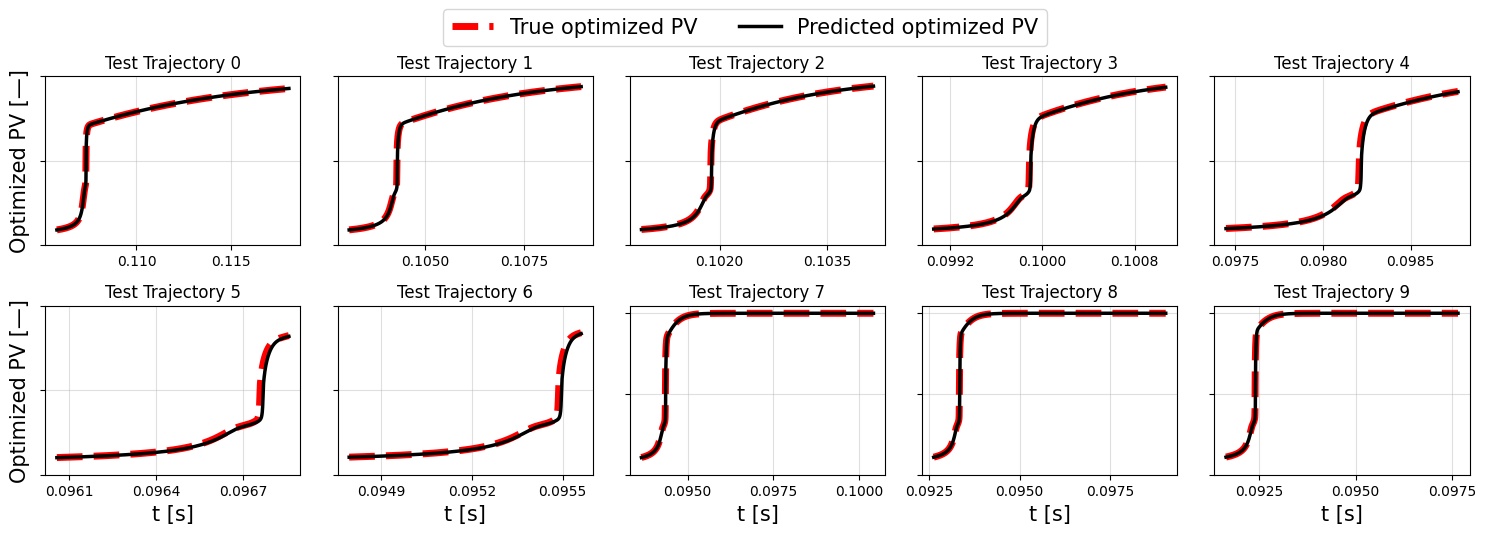

In [53]:
save = False
zoom = True
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled tabulation/"


num_test_trajectories = 10
rows, cols = 2, 5  # Arrange in a 2x5 grid

fig, axes = plt.subplots(rows, cols, figsize=(15, 5))  # Define the grid
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for i in range(num_test_trajectories):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        state_space_test_DNS = test_trajectory[state_space_names_DNS].to_numpy()
        PV_optimized_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_test_DNS, idx_species_removed, axis=1))).detach().numpy()
        #PV_optimized_test = (PV_optimized_test - PV_optimized_test.min())/(PV_optimized_test.max() - PV_optimized_test.min())

    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
        
    ax = axes[i]

    PV_min = PV_optimized_test[idx_start_simulation:].min()
    PV_max = PV_optimized_test[idx_start_simulation:].max()

    #-(list_simulations_optimized[i][:,1]-PV_min)/(PV_max - PV_min)+1

    if(zoom):
        ##############################################
        # Get the first and last index of the ignition
        ##############################################

        H2O_array = test_trajectory["H2O"].to_numpy()
        
        max_val = H2O_array.max()
        min_perc = 0.0028
        max_perc = 0.999
        lower_threshold = min_perc * max_val
        upper_threshold = max_perc * max_val

        idx_1 = np.searchsorted(H2O_array, lower_threshold, side='left')
        idx_99 = np.searchsorted(H2O_array, upper_threshold, side='left')

        ax.plot(test_trajectory_time[idx_1:idx_99], (PV_optimized_test[idx_1:idx_99]-PV_min)/(PV_max - PV_min), label="True optimized PV", color = "red", linestyle = "--", linewidth = 5) #id_end
        ax.plot(test_trajectory_time[idx_1:idx_99], (list_simulations_optimized[i][idx_1:idx_99,1]-PV_min)/(PV_max - PV_min), label="Predicted optimized PV", color = "k", linewidth = 2.5) #idx_end-idx_start_simulation
    else:
        ax.plot(test_trajectory_time[idx_start_simulation:], (PV_optimized_test[idx_start_simulation:]-PV_min)/(PV_max - PV_min), label="True optimized PV", color = "red", linestyle = "--", linewidth = 5) #id_end
        ax.plot(test_trajectory_time[idx_start_simulation:], (list_simulations_optimized[i][:,1]-PV_min)/(PV_max - PV_min), label="Predicted optimized PV", color = "k", linewidth = 2.5) #idx_end-idx_start_simulation
    
    ax.set_title(f"Test Trajectory {i}")
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    #ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels([])

    ax.grid(True, linestyle='-', alpha=0.4)

    if(i>=num_test_trajectories-cols):
            ax.set_xlabel(f"t [s]", fontsize = 15)
    
    if(i%cols == 0):
            ax.set_ylabel('Optimized PV [\u2014]', fontsize = 15)    

#hide empty figures
for j in range(num_test_trajectories, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth() * 1,  # Increase legend linewidth
           label=label)
    for handle, label in zip(handles, labels)
]
fig.legend(custom_handles, labels, loc='upper center', ncol=2, fontsize=15, frameon=True, bbox_to_anchor=(0.5, 1.08))

name = f"Heuristic vs optimized {id_model} - A posteriori - Optimized PV - Scaled tabulation{f' - zoom {min_perc}-{max_perc}' if zoom else ''}.png"
namePdf = f"Heuristic vs optimized {id_model} - A posteriori - Optimized PV - Scaled tabulation{f' - zoom {min_perc}-{max_perc}' if zoom else ''}.pdf"

# Adjust layout
plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

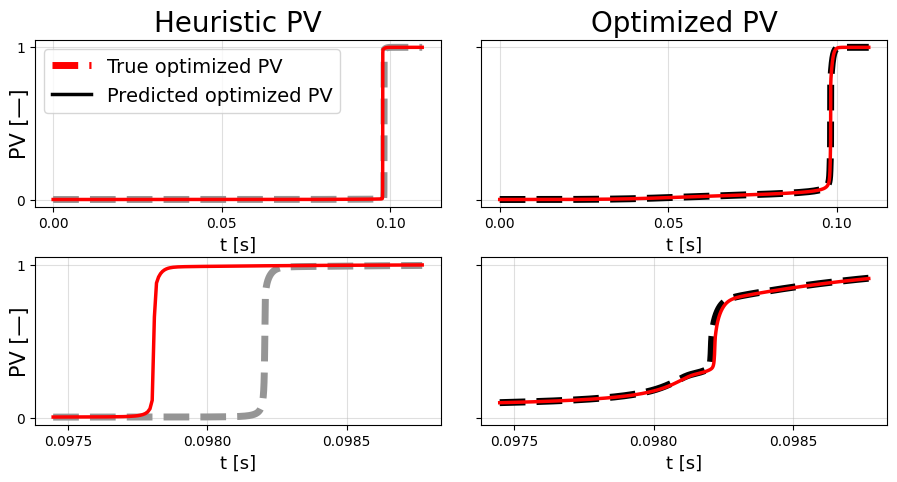

In [54]:
save = False
zoom = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled tabulation/"
idx_test = 4  # Use test trajectory 4
idx_start_simulation = 0

# === Prepare figure ===
fig, axes = plt.subplots(2, 2, figsize=(11, 5))
axes = axes.flatten()  # Flatten for easy access

# === Load test data for trajectory 4 ===
with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
    test_trajectory = pd.DataFrame(hf[f'test_trajectory_{idx_test}'][:], columns=state_space_names)
    PV_Xu_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
    PV_Xu_test = PV_Xu_test.to_numpy().reshape(-1, 1)
    PV_Xu_test_min = PV_Xu_test.min()
    PV_Xu_test_max = PV_Xu_test.max()

    state_space_test_DNS = test_trajectory[state_space_names_DNS].to_numpy()
    PV_optimized_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_test_DNS, idx_species_removed, axis=1))).detach().numpy()
    PV_min = PV_optimized_test[idx_start_simulation:].min()
    PV_max = PV_optimized_test[idx_start_simulation:].max()

with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
    test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{idx_test}'][:])

H2O_array = test_trajectory["H2O"].to_numpy()
max_val = H2O_array.max()

# Heuristic Zoom thresholds
min_perc_heur = 0.0028 #0.003
max_perc_heur = 0.999 #0.995
lower_threshold_heur = min_perc_heur * max_val
upper_threshold_heur = max_perc_heur * max_val
idx_1_heur = np.searchsorted(H2O_array, lower_threshold_heur, side='left')
idx_99_heur = np.searchsorted(H2O_array, upper_threshold_heur, side='left')

# Optimized Zoom thresholds
min_perc_opt = 0.0028
max_perc_opt = 0.999
lower_threshold_opt = min_perc_opt * max_val
upper_threshold_opt = max_perc_opt * max_val
idx_1_opt = np.searchsorted(H2O_array, lower_threshold_opt, side='left')
idx_99_opt = np.searchsorted(H2O_array, upper_threshold_opt, side='left')

# === Plotting ===

# 0: Heuristic Full
ax = axes[0]
ax.plot(test_trajectory_time[idx_start_simulation:], (PV_Xu_test[idx_start_simulation:] - PV_Xu_test_min) / (PV_Xu_test_max - PV_Xu_test_min),
        label="True", color=greys(0.5), linestyle="--", linewidth=5)
ax.plot(test_trajectory_time[idx_start_simulation:], (list_simulations_Xu[idx_test][:, 1] - PV_Xu_test_min) / (PV_Xu_test_max - PV_Xu_test_min),
        label="Predicted", color="red", linewidth=2.5)
ax.set_title("Heuristic PV", fontsize = 20)
ax.set_ylabel('PV [—]', fontsize=15, labelpad = -10)
ax.set_xlabel("t [s]", fontsize=13)
ax.grid(True, linestyle='-', alpha=0.4)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
ax.set_yticks([0, 1])
ax.legend(custom_handles, labels, ncol=1, fontsize=14, frameon=True)

# 1: Optimized Full
ax = axes[1]
ax.plot(test_trajectory_time[idx_start_simulation:], (PV_optimized_test[idx_start_simulation:] - PV_min) / (PV_max - PV_min),
        label="True optimized PV", color="k", linestyle="--", linewidth=5)
ax.plot(test_trajectory_time[idx_start_simulation:], (list_simulations_optimized[idx_test][:, 1] - PV_min) / (PV_max - PV_min),
        label="Predicted optimized PV", color="red", linewidth=2.5)
ax.set_title("Optimized PV", fontsize = 20)
ax.set_xlabel("t [s]", fontsize=13)
ax.grid(True, linestyle='-', alpha=0.4)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
ax.set_yticks([0, 1])
ax.set_yticklabels("")

# 2: Heuristic Zoom
ax = axes[2]
ax.plot(test_trajectory_time[idx_1_heur:idx_99_heur], (PV_Xu_test[idx_1_heur:idx_99_heur] - PV_Xu_test_min) / (PV_Xu_test_max - PV_Xu_test_min),
        label="True heuristic PV", color=greys(0.5), linestyle="--", linewidth=5)
ax.plot(test_trajectory_time[idx_1_heur:idx_99_heur], (list_simulations_Xu[idx_test][idx_1_heur:idx_99_heur, 1] - PV_Xu_test_min) / (PV_Xu_test_max - PV_Xu_test_min),
        label="Predicted heuristic PV", color="red", linewidth=2.5)
ax.set_xlabel("t [s]", fontsize=13)
ax.set_ylabel('PV [—]', fontsize=15, labelpad = -10)
ax.grid(True, linestyle='-', alpha=0.4)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
ax.set_yticks([0, 1])
ylims = ax.get_ylim()
xlims = ax.get_xlim()

# 3: Optimized Zoom
ax = axes[3]
ax.plot(test_trajectory_time[idx_1_opt:idx_99_opt], (PV_optimized_test[idx_1_opt:idx_99_opt] - PV_min) / (PV_max - PV_min),
        label="True optimized PV", color="k", linestyle="--", linewidth=5)
ax.plot(test_trajectory_time[idx_1_opt:idx_99_opt], (list_simulations_optimized[idx_test][idx_1_opt:idx_99_opt, 1] - PV_min) / (PV_max - PV_min),
        label="Predicted optimized PV", color="red", linewidth=2.5)
ax.set_xlabel("t [s]", fontsize=13)
ax.grid(True, linestyle='-', alpha=0.4)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
ax.set_ylim(ylims)
ax.set_xlim(xlims)
ax.set_yticks([0, 1])
ax.set_yticklabels("")

# === Legend ===
handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth(),
           label=label)
    for handle, label in zip(handles, labels)
]

fig.subplots_adjust(
    hspace=0.3,  # Increase vertical space between rows (default ~0.2)
    wspace=0.1    # Decrease horizontal space between columns (default ~0.2)
)

# === Highlight zoom region with rectangle and connecting lines ===

# Coordinates for the zoom frame
x0, x1 = 0.095, 0.102
y0, y1 = -0.03, 1.03

zorder_rect = 10
zorder_line = 11

if zoom:
        # --- Heuristic frame on subplot [0] ---
        rect0 = Rectangle((x0, y0), x1 - x0, y1 - y0,
                        linewidth=1.5, edgecolor='black', facecolor='none', zorder=zorder_rect, linestyle='--')
        axes[0].add_patch(rect0)

        # Compute transformed corners from axes[0] to axes[2]
        p0 = axes[0].transData.transform((x0, y0))  # top-left of rect
        p1 = axes[0].transData.transform((x1, y0))  # top-right of rect

        p0_2 = axes[2].transData.inverted().transform(p0)
        p1_2 = axes[2].transData.inverted().transform(p1)

        # Draw connection lines on axes[2]
        # axes[2].add_line(Line2D([p0_2[0], xlims[0]], [p0_2[1], ylims[1]], color='black', linewidth=1, zorder=zorder_line, clip_on=False))
        # axes[2].add_line(Line2D([p1_2[0], xlims[1]], [p1_2[1], ylims[1]], color='black', linewidth=1, zorder=zorder_line, clip_on=False))

        # --- Optimized frame on subplot [1] ---
        rect1 = Rectangle((x0, y0), x1 - x0, y1 - y0,
                        linewidth=1.5, edgecolor='black', facecolor='none', zorder=zorder_rect, linestyle='--')
        axes[1].add_patch(rect1)

        p0 = axes[1].transData.transform((x0, y0))  # top-left
        p1 = axes[1].transData.transform((x1, y0))  # top-right

        p0_3 = axes[3].transData.inverted().transform(p0)
        p1_3 = axes[3].transData.inverted().transform(p1)

        # axes[3].add_line(Line2D([p0_3[0], xlims[0]], [p0_3[1], ylims[1]], color='black', linewidth=1, zorder=zorder_line, clip_on=False))
        # axes[3].add_line(Line2D([p1_3[0], xlims[1]], [p1_3[1], ylims[1]], color='black', linewidth=1, zorder=zorder_line, clip_on=False))

        fig_coords_p0 = fig.transFigure.inverted().transform(axes[0].transData.transform((x0, y0)))
        fig_coords_p1 = fig.transFigure.inverted().transform(axes[0].transData.transform((x1, y0)))
        fig_coords_q0 = fig.transFigure.inverted().transform(axes[2].transData.transform((xlims[0], ylims[1])))
        fig_coords_q1 = fig.transFigure.inverted().transform(axes[2].transData.transform((xlims[1], ylims[1])))

        # Add lines to the figure
        fig.lines.append(Line2D([fig_coords_p0[0], fig_coords_q0[0]], [fig_coords_p0[1], fig_coords_q0[1]],
                                transform=fig.transFigure, color='black', linewidth=1, zorder=zorder_line))
        fig.lines.append(Line2D([fig_coords_p1[0], fig_coords_q1[0]], [fig_coords_p1[1], fig_coords_q1[1]],
                                transform=fig.transFigure, color='black', linewidth=1, zorder=zorder_line))

        # --- For Optimized connection lines (axes[1] to axes[3]) ---
        fig_coords_p0 = fig.transFigure.inverted().transform(axes[1].transData.transform((x0, y0)))
        fig_coords_p1 = fig.transFigure.inverted().transform(axes[1].transData.transform((x1, y0)))
        fig_coords_q0 = fig.transFigure.inverted().transform(axes[3].transData.transform((xlims[0], ylims[1])))
        fig_coords_q1 = fig.transFigure.inverted().transform(axes[3].transData.transform((xlims[1], ylims[1])))

        fig.lines.append(Line2D([fig_coords_p0[0], fig_coords_q0[0]], [fig_coords_p0[1], fig_coords_q0[1]],
                                transform=fig.transFigure, color='black', linewidth=1, zorder=zorder_line))
        fig.lines.append(Line2D([fig_coords_p1[0], fig_coords_q1[0]], [fig_coords_p1[1], fig_coords_q1[1]],
                                transform=fig.transFigure, color='black', linewidth=1, zorder=zorder_line))



# === Final layout and save ===
#plt.tight_layout()
if save:
    filename = f"PV_comparison_trajectory_{idx_test}_{'zoom' if zoom else ''}.png"
    plt.savefig(pathSave + filename, dpi=300, bbox_inches="tight")
plt.show()

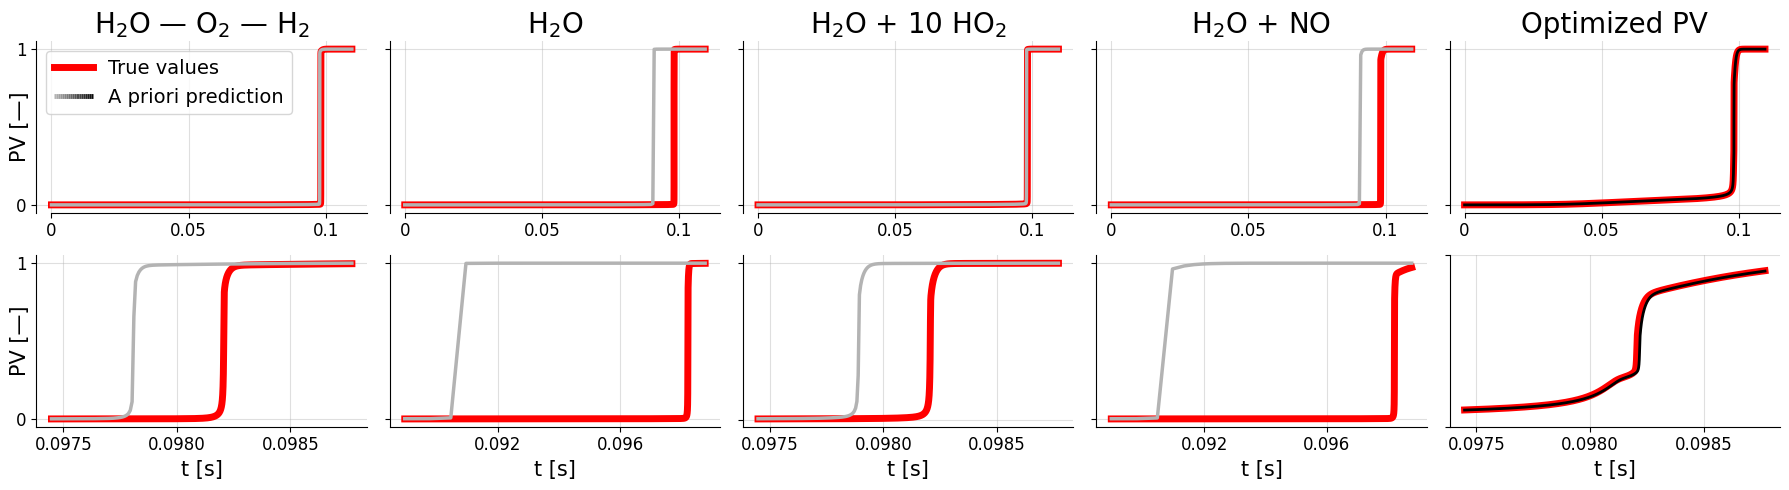

In [111]:
save = True
zoom = False
pathSave = "C:/Users/admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/A posteriori/Tabulation/"
idx_test = 4  # Use test trajectory 4
idx_start_simulation = 0

# === Prepare figure ===
fig, axes = plt.subplots(2, 5, figsize=(18, 5))
axes = axes.flatten()  # Flatten for easy access

class HandlerGradientLine(HandlerBase):
    def __init__(self, cmap, linewidth=3.5, **kwargs):
        super().__init__(**kwargs)
        self.cmap = cmap
        self.linewidth = linewidth

    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height,
                       fontsize, trans):

        n = 20
        x = np.linspace(xdescent, xdescent + width, n)
        y = np.full(n, ydescent + height / 2)

        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        lc = LineCollection(
            segments,
            cmap=self.cmap,
            linewidths=self.linewidth
        )
        lc.set_array(np.linspace(0, 1, n))
        lc.set_transform(trans)

        return [lc]

# === Load test data for trajectory 4 ===
with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
    test_trajectory = pd.DataFrame(hf[f'test_trajectory_{idx_test}'][:], columns=state_space_names)
    PV_Xu_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
    PV_Xu_test = PV_Xu_test.to_numpy().reshape(-1, 1)
    PV_Xu_test_min = PV_Xu_test.min()
    PV_Xu_test_max = PV_Xu_test.max()

    PV_heuH2O_test = test_trajectory["H2O"]
    PV_heuH2O_test = PV_heuH2O_test.to_numpy().reshape(-1, 1)
    PV_heuH2O_test_min = PV_heuH2O_test.min()
    PV_heuH2O_test_max = PV_heuH2O_test.max()

    PV_heu10HO2_test = test_trajectory["H2O"] + 10 * test_trajectory["HO2"]
    PV_heu10HO2_test = PV_heu10HO2_test.to_numpy().reshape(-1, 1)
    PV_heu10HO2_test_min = PV_heu10HO2_test.min()
    PV_heu10HO2_test_max = PV_heu10HO2_test.max()

    PV_heu1NO_test = test_trajectory["H2O"] + test_trajectory["NO"]
    PV_heu1NO_test = PV_heu1NO_test.to_numpy().reshape(-1, 1)
    PV_heu1NO_test_min = PV_heu1NO_test.min()
    PV_heu1NO_test_max = PV_heu1NO_test.max()

    state_space_test_DNS = test_trajectory[state_space_names_DNS].to_numpy()
    PV_optimized_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_test_DNS, idx_species_removed, axis=1))).detach().numpy()
    PV_min = PV_optimized_test[idx_start_simulation:].min()
    PV_max = PV_optimized_test[idx_start_simulation:].max()

with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
    test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{idx_test}'][:])

H2O_array = test_trajectory["H2O"].to_numpy()
max_val = H2O_array.max()

# Heuristic Zoom thresholds
min_perc_heur = 0.0028 #0.003
max_perc_heur = 0.999 #0.995
lower_threshold_heur = min_perc_heur * max_val
upper_threshold_heur = max_perc_heur * max_val
idx_1_heur = np.searchsorted(H2O_array, lower_threshold_heur, side='left')
idx_99_heur = np.searchsorted(H2O_array, upper_threshold_heur, side='left')

min_perc_heurShort = 0.001 #0.003
max_perc_heurShort = 0.999 #0.995
lower_threshold_heurShort = min_perc_heurShort * max_val
upper_threshold_heurShort = max_perc_heurShort * max_val
idx_1_heurShort = np.searchsorted(H2O_array, lower_threshold_heurShort, side='left')
idx_99_heurShort = np.searchsorted(H2O_array, upper_threshold_heurShort, side='left')

# Optimized Zoom thresholds
min_perc_opt = 0.0028
max_perc_opt = 0.999
lower_threshold_opt = min_perc_opt * max_val
upper_threshold_opt = max_perc_opt * max_val
idx_1_opt = np.searchsorted(H2O_array, lower_threshold_opt, side='left')
idx_99_opt = np.searchsorted(H2O_array, upper_threshold_opt, side='left')

grey_black = LinearSegmentedColormap.from_list(
    "grey_black", ["0.7", "0.0"]
)

true_handle, = axes[0].plot(
    [], [], color="red", linestyle="-", linewidth=5,
    label="True values"
)

gradient_handle, = axes[0].plot(
    [], [], label="A priori prediction"
)

# === Plotting ===

# 0: Heuristic Full
ax = axes[0]
ax.plot(test_trajectory_time[idx_start_simulation:], (PV_Xu_test[idx_start_simulation:] - PV_Xu_test_min) / (PV_Xu_test_max - PV_Xu_test_min),
        label="True", color="red", linestyle="-", linewidth=5)
ax.plot(test_trajectory_time[idx_start_simulation:], (list_simulations_Xu[idx_test][:, 1] - PV_Xu_test_min) / (PV_Xu_test_max - PV_Xu_test_min),
        label="Predicted", color="0.7", linewidth=2.5)
ax.set_title("H$_2$O \u2014 O$_2$ \u2014 H$_2$", fontsize = 20)
ax.set_ylabel('PV [—]', fontsize=15, labelpad = -10)
ax.grid(True, linestyle='-', alpha=0.4)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: "0" if np.isclose(x, 0) else f"{x:g}")
)
ax.tick_params(axis='x', labelsize=12)
ax.set_yticks([0, 1])
ax.tick_params(axis='y', labelsize=12)
ax.legend(handles=[true_handle, gradient_handle],
    handler_map={gradient_handle: HandlerGradientLine(grey_black)}, labels = labels, ncol=1, fontsize=14, frameon=True)

ax = axes[1]
ax.plot(test_trajectory_time[idx_start_simulation:], (PV_heuH2O_test[idx_start_simulation:] - PV_heuH2O_test_min) / (PV_heuH2O_test_max - PV_heuH2O_test_min),
        label="True", color="red", linestyle="-", linewidth=5)
ax.plot(test_trajectory_time[idx_start_simulation:], (list_simulations_heuH2O[idx_test][:, 1] - PV_heuH2O_test_min) / (PV_heuH2O_test_max - PV_heuH2O_test_min),
        label="Predicted", color="0.7", linewidth=2.5)
ax.set_title("H$_2$O", fontsize = 20)
ax.grid(True, linestyle='-', alpha=0.4)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: "0" if np.isclose(x, 0) else f"{x:g}")
)
ax.tick_params(axis='x', labelsize=12)
ax.set_yticks([0, 1])
ax.set_yticklabels("")

ax = axes[2]
ax.plot(test_trajectory_time[idx_start_simulation:], (PV_heu10HO2_test[idx_start_simulation:] - PV_heu10HO2_test_min) / (PV_heu10HO2_test_max - PV_heu10HO2_test_min),
        label="True", color="red", linestyle="-", linewidth=5)
ax.plot(test_trajectory_time[idx_start_simulation:], (list_simulations_heu10HO2[idx_test][:, 1] - PV_heu10HO2_test_min) / (PV_heu10HO2_test_max - PV_heu10HO2_test_min),
        label="Predicted", color="0.7", linewidth=2.5)
ax.set_title("H$_2$O + 10 HO$_2$", fontsize = 20)
ax.grid(True, linestyle='-', alpha=0.4)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: "0" if np.isclose(x, 0) else f"{x:g}")
)
ax.tick_params(axis='x', labelsize=12)
ax.set_yticks([0, 1])
ax.set_yticklabels("")

ax = axes[3]
ax.plot(test_trajectory_time[idx_start_simulation:], (PV_heu1NO_test[idx_start_simulation:] - PV_heu1NO_test_min) / (PV_heu1NO_test_max - PV_heu1NO_test_min),
        label="True", color="red", linestyle="-", linewidth=5)
ax.plot(test_trajectory_time[idx_start_simulation:], (list_simulations_heu1NO[idx_test][:, 1] - PV_heu1NO_test_min) / (PV_heu1NO_test_max - PV_heu1NO_test_min),
        label="Predicted", color="0.7", linewidth=2.5)
ax.set_title("H$_2$O + NO", fontsize = 20)
ax.grid(True, linestyle='-', alpha=0.4)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: "0" if np.isclose(x, 0) else f"{x:g}")
)
ax.tick_params(axis='x', labelsize=12)
ax.set_yticks([0, 1])
ax.set_yticklabels("")

# 1: Optimized Full
ax = axes[4]
ax.plot(test_trajectory_time[idx_start_simulation:], (PV_optimized_test[idx_start_simulation:] - PV_min) / (PV_max - PV_min),
        label="True optimized PV", color="red", linestyle="-", linewidth=5)
ax.plot(test_trajectory_time[idx_start_simulation:], (list_simulations_optimized[idx_test][:, 1] - PV_min) / (PV_max - PV_min),
        label="Predicted optimized PV", color="black", linewidth=2)
ax.set_title("Optimized PV", fontsize = 20)
ax.grid(True, linestyle='-', alpha=0.4)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: "0" if np.isclose(x, 0) else f"{x:g}")
)
ax.tick_params(axis='x', labelsize=12)
ax.set_yticks([0, 1])
ax.set_yticklabels("")

# 2: Heuristic Zoom
ax = axes[5]
ax.plot(test_trajectory_time[idx_1_heur:idx_99_heur], (PV_Xu_test[idx_1_heur:idx_99_heur] - PV_Xu_test_min) / (PV_Xu_test_max - PV_Xu_test_min),
        label="True heuristic PV", color="red", linestyle="-", linewidth=5)
ax.plot(test_trajectory_time[idx_1_heur:idx_99_heur], (list_simulations_Xu[idx_test][idx_1_heur:idx_99_heur, 1] - PV_Xu_test_min) / (PV_Xu_test_max - PV_Xu_test_min),
        label="Predicted heuristic PV", color="0.7", linewidth=2.5)
ax.set_xlabel("t [s]", fontsize=15)
ax.set_ylabel('PV [—]', fontsize=15, labelpad = -10)
ax.grid(True, linestyle='-', alpha=0.4)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
ax.tick_params(axis='x', labelsize=12)
ax.set_yticks([0, 1])
ax.tick_params(axis='y', labelsize=12)
ylims = ax.get_ylim()
xlims = ax.get_xlim()

ax = axes[6]
ax.plot(test_trajectory_time[idx_1_heurShort:idx_99_heurShort], (PV_heuH2O_test[idx_1_heurShort:idx_99_heurShort] - PV_heuH2O_test_min) / (PV_heuH2O_test_max - PV_heuH2O_test_min),
        label="True heuristic PV", color="red", linestyle="-", linewidth=5)
ax.plot(test_trajectory_time[idx_1_heurShort:idx_99_heurShort], (list_simulations_heuH2O[idx_test][idx_1_heurShort:idx_99_heurShort, 1] - PV_heuH2O_test_min) / (PV_heuH2O_test_max - PV_heuH2O_test_min),
        label="Predicted heuristic PV", color="0.7", linewidth=2.5)
ax.set_xlabel("t [s]", fontsize=15)
ax.grid(True, linestyle='-', alpha=0.4)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
ax.tick_params(axis='x', labelsize=12)
ax.set_yticks([0, 1])
ylims = ax.get_ylim()
xlims = ax.get_xlim()
ax.set_yticklabels("")

ax = axes[7]
ax.plot(test_trajectory_time[idx_1_heur:idx_99_heur], (PV_heu10HO2_test[idx_1_heur:idx_99_heur] - PV_heu10HO2_test_min) / (PV_heu10HO2_test_max - PV_heu10HO2_test_min),
        label="True heuristic PV", color="red", linestyle="-", linewidth=5)
ax.plot(test_trajectory_time[idx_1_heur:idx_99_heur], (list_simulations_heu10HO2[idx_test][idx_1_heur:idx_99_heur, 1] - PV_heu10HO2_test_min) / (PV_heu10HO2_test_max - PV_heu10HO2_test_min),
        label="Predicted heuristic PV", color="0.7", linewidth=2.5)
ax.set_xlabel("t [s]", fontsize=15)
ax.grid(True, linestyle='-', alpha=0.4)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
ax.tick_params(axis='x', labelsize=12)
ax.set_yticks([0, 1])
ylims = ax.get_ylim()
xlims = ax.get_xlim()
ax.set_yticklabels("")

ax = axes[8]
ax.plot(test_trajectory_time[idx_1_heurShort:idx_99_heurShort], (PV_heu1NO_test[idx_1_heurShort:idx_99_heurShort] - PV_heu1NO_test_min) / (PV_heu1NO_test_max - PV_heu1NO_test_min),
        label="True heuristic PV", color="red", linestyle="-", linewidth=5)
ax.plot(test_trajectory_time[idx_1_heurShort:idx_99_heurShort], (list_simulations_heu1NO[idx_test][idx_1_heurShort:idx_99_heurShort, 1] - PV_heu1NO_test_min) / (PV_heu1NO_test_max - PV_heu1NO_test_min),
        label="Predicted heuristic PV", color="0.7", linewidth=2.5)
ax.set_xlabel("t [s]", fontsize=15)
ax.grid(True, linestyle='-', alpha=0.4)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
ax.tick_params(axis='x', labelsize=12)
ax.set_yticks([0, 1])
ylims = ax.get_ylim()
xlims = ax.get_xlim()
ax.set_yticklabels("")

# 3: Optimized Zoom
ax = axes[9]
ax.plot(test_trajectory_time[idx_1_opt:idx_99_opt], (PV_optimized_test[idx_1_opt:idx_99_opt] - PV_min) / (PV_max - PV_min),
        label="True optimized PV", color="red", linestyle="-", linewidth=5)
ax.plot(test_trajectory_time[idx_1_opt:idx_99_opt], (list_simulations_optimized[idx_test][idx_1_opt:idx_99_opt, 1] - PV_min) / (PV_max - PV_min),
        label="Predicted optimized PV", color="black", linewidth=2)
ax.set_xlabel("t [s]", fontsize=15)
ax.grid(True, linestyle='-', alpha=0.4)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
ax.tick_params(axis='x', labelsize=12)
#ax.set_ylim(ylims)
#ax.set_xlim(xlims)
ax.set_yticks([0, 1])
ax.set_yticklabels("")

# === Legend ===
handles, labels = axes[0].get_legend_handles_labels()
custom_handles = [
    Line2D([0], [0], color=handle.get_color(),
           linestyle=handle.get_linestyle(),
           linewidth=handle.get_linewidth(),
           label=label)
    for handle, label in zip(handles, labels)
]

fig.subplots_adjust(
    hspace=0.3,  # Increase vertical space between rows (default ~0.2)
    wspace=0.1    # Decrease horizontal space between columns (default ~0.2)
)

# === Highlight zoom region with rectangle and connecting lines ===

# Coordinates for the zoom frame
x0, x1 = 0.095, 0.102
y0, y1 = -0.03, 1.03

zorder_rect = 10
zorder_line = 11

if zoom:
        # --- Heuristic frame on subplot [0] ---
        rect0 = Rectangle((x0, y0), x1 - x0, y1 - y0,
                        linewidth=1.5, edgecolor='black', facecolor='none', zorder=zorder_rect, linestyle='--')
        axes[0].add_patch(rect0)

        # Compute transformed corners from axes[0] to axes[2]
        p0 = axes[0].transData.transform((x0, y0))  # top-left of rect
        p1 = axes[0].transData.transform((x1, y0))  # top-right of rect

        p0_2 = axes[2].transData.inverted().transform(p0)
        p1_2 = axes[2].transData.inverted().transform(p1)

        # Draw connection lines on axes[2]
        # axes[2].add_line(Line2D([p0_2[0], xlims[0]], [p0_2[1], ylims[1]], color='black', linewidth=1, zorder=zorder_line, clip_on=False))
        # axes[2].add_line(Line2D([p1_2[0], xlims[1]], [p1_2[1], ylims[1]], color='black', linewidth=1, zorder=zorder_line, clip_on=False))

        # --- Optimized frame on subplot [1] ---
        rect1 = Rectangle((x0, y0), x1 - x0, y1 - y0,
                        linewidth=1.5, edgecolor='black', facecolor='none', zorder=zorder_rect, linestyle='--')
        axes[1].add_patch(rect1)

        p0 = axes[1].transData.transform((x0, y0))  # top-left
        p1 = axes[1].transData.transform((x1, y0))  # top-right

        p0_3 = axes[3].transData.inverted().transform(p0)
        p1_3 = axes[3].transData.inverted().transform(p1)

        # axes[3].add_line(Line2D([p0_3[0], xlims[0]], [p0_3[1], ylims[1]], color='black', linewidth=1, zorder=zorder_line, clip_on=False))
        # axes[3].add_line(Line2D([p1_3[0], xlims[1]], [p1_3[1], ylims[1]], color='black', linewidth=1, zorder=zorder_line, clip_on=False))

        fig_coords_p0 = fig.transFigure.inverted().transform(axes[0].transData.transform((x0, y0)))
        fig_coords_p1 = fig.transFigure.inverted().transform(axes[0].transData.transform((x1, y0)))
        fig_coords_q0 = fig.transFigure.inverted().transform(axes[2].transData.transform((xlims[0], ylims[1])))
        fig_coords_q1 = fig.transFigure.inverted().transform(axes[2].transData.transform((xlims[1], ylims[1])))

        # Add lines to the figure
        fig.lines.append(Line2D([fig_coords_p0[0], fig_coords_q0[0]], [fig_coords_p0[1], fig_coords_q0[1]],
                                transform=fig.transFigure, color='black', linewidth=1, zorder=zorder_line))
        fig.lines.append(Line2D([fig_coords_p1[0], fig_coords_q1[0]], [fig_coords_p1[1], fig_coords_q1[1]],
                                transform=fig.transFigure, color='black', linewidth=1, zorder=zorder_line))

        # --- For Optimized connection lines (axes[1] to axes[3]) ---
        fig_coords_p0 = fig.transFigure.inverted().transform(axes[1].transData.transform((x0, y0)))
        fig_coords_p1 = fig.transFigure.inverted().transform(axes[1].transData.transform((x1, y0)))
        fig_coords_q0 = fig.transFigure.inverted().transform(axes[3].transData.transform((xlims[0], ylims[1])))
        fig_coords_q1 = fig.transFigure.inverted().transform(axes[3].transData.transform((xlims[1], ylims[1])))

        fig.lines.append(Line2D([fig_coords_p0[0], fig_coords_q0[0]], [fig_coords_p0[1], fig_coords_q0[1]],
                                transform=fig.transFigure, color='black', linewidth=1, zorder=zorder_line))
        fig.lines.append(Line2D([fig_coords_p1[0], fig_coords_q1[0]], [fig_coords_p1[1], fig_coords_q1[1]],
                                transform=fig.transFigure, color='black', linewidth=1, zorder=zorder_line))

for i in range(len(axes)):
    ax = axes[i]
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    if(i <=4):
         xmin, xmax = ax.get_xlim()
         ax.spines["bottom"].set_bounds(0, xmax)

# === Final layout and save ===
plt.tight_layout()
if save:
    filename = f"PV_comparison_trajectory_{idx_test}_{'zoom' if zoom else ''}"
    plt.savefig(pathSave + filename + ".png", dpi=300, bbox_inches="tight")
    plt.savefig(pathSave + filename + ".pdf", bbox_inches="tight")
plt.show()

In [55]:
time_test = test_trajectory_time[idx_start_simulation:]

PV_heuristic_true = (PV_Xu_test[idx_start_simulation:] - PV_Xu_test_min) / (PV_Xu_test_max - PV_Xu_test_min)
PV_heurisitc_pred = (list_simulations_Xu[idx_test][:, 1] - PV_Xu_test_min) / (PV_Xu_test_max - PV_Xu_test_min)
        

PV_optimized_true = (PV_optimized_test[idx_start_simulation:] - PV_min) / (PV_max - PV_min)
PV_optimized_pred = (list_simulations_optimized[idx_test][:, 1] - PV_min) / (PV_max - PV_min)

np.savez("data-files/autoignition/A_posteriori_tabulation_4_1_traj4/saved_arrays.npz",
         time_test=time_test,
         PV_heuristic_true=PV_heuristic_true,
         PV_heuristic_pred=PV_heurisitc_pred,
         PV_optimized_true=PV_optimized_true,
         PV_optimized_pred=PV_optimized_pred)

In [56]:
def ignition_time_difference(time_array, pv_true, pv_pred, threshold=0.9):
    """
    Compute the time difference between true and predicted PV ignition times.
    
    Parameters
    ----------
    time_array : np.ndarray
        1D array of time values.
    pv_true : np.ndarray
        1D array of true PV values (same length as time_array).
    pv_pred : np.ndarray
        1D array of predicted PV values (same length as time_array).
    threshold : float, optional
        The PV threshold for ignition (default: 0.99).
    
    Returns
    -------
    float or None
        The time difference (predicted - true) when both trajectories reach
        the threshold. Returns None if either trajectory never reaches it.
    """
    # Find first index where true PV >= threshold
    true_idx = np.argmax(pv_true >= threshold) if np.any(pv_true >= threshold) else None
    # Find first index where predicted PV >= threshold
    pred_idx = np.argmax(pv_pred >= threshold) if np.any(pv_pred >= threshold) else None

    if true_idx is None or pred_idx is None:
        return None  # one of them never reaches threshold

    true_time = time_array[true_idx]
    pred_time = time_array[pred_idx]

    return pred_time - true_time, np.abs(pred_time - true_time)/true_time*100

list_dt_perc_Xu = []
list_dt_perc_heuH2O = []
list_dt_perc_heu10HO2 = []
list_dt_perc_heu1NO = []
list_dt_perc_optimized = []

for i in range(10):
    #test state space
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)
        PV_Xu_test = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
        PV_Xu_test = PV_Xu_test.to_numpy().reshape(-1,1)
        f_PV_Xu_test = np.hstack((np.full(PV_Xu_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_Xu_test))

        PV_heuH2O_test = test_trajectory["H2O"]
        PV_heuH2O_test = PV_heuH2O_test.to_numpy().reshape(-1,1)
        f_PV_heuH2O_test = np.hstack((np.full(PV_heuH2O_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_heuH2O_test))

        PV_heu10HO2_test = test_trajectory["H2O"] + 10 * test_trajectory["HO2"]
        PV_heu10HO2_test = PV_heu10HO2_test.to_numpy().reshape(-1,1)
        f_PV_heu10HO2_test = np.hstack((np.full(PV_heu10HO2_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_heu10HO2_test))

        PV_heu1NO_test = test_trajectory["H2O"] + test_trajectory["NO"]
        PV_heu1NO_test = PV_heu1NO_test.to_numpy().reshape(-1,1)
        f_PV_heu1NO_test = np.hstack((np.full(PV_heu1NO_test.shape[0], mixture_fractions_test[i]).reshape(-1,1), PV_heu1NO_test))

        state_space_test_DNS = test_trajectory[state_space_names_DNS].to_numpy()
        PV_optimized_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_test_DNS, idx_species_removed, axis=1))).detach().numpy()

    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{i}'][:])
    
    test_trajectory_time = test_trajectory_time.to_numpy().ravel()
    test_trajectory_time = torch.tensor(test_trajectory_time)

    min_PV_Xu = PV_Xu_test.min()
    max_PV_Xu = PV_Xu_test.max()

    min_PV_heuH2O = PV_heuH2O_test.min()
    max_PV_heuH2O = PV_heuH2O_test.max()

    min_PV_heu10HO2 = PV_heu10HO2_test.min()
    max_PV_heu10HO2 = PV_heu10HO2_test.max()

    min_PV_heu1NO = PV_heu1NO_test.min()
    max_PV_heu1NO = PV_heu1NO_test.max()

    min_PV_optimized = PV_optimized_test.min()
    max_PV_optimized = PV_optimized_test.max()

    true_PV_Xu_norm = (PV_Xu_test - min_PV_Xu) / (max_PV_Xu - min_PV_Xu)
    pred_PV_Xu_norm = (list_simulations_Xu[i][:,1] - min_PV_Xu) / (max_PV_Xu - min_PV_Xu)

    true_PV_heuH2O_norm = (PV_heuH2O_test - min_PV_heuH2O) / (max_PV_heuH2O - min_PV_heuH2O)
    pred_PV_heuH2O_norm = (list_simulations_heuH2O[i][:,1] - min_PV_heuH2O) / (max_PV_heuH2O - min_PV_heuH2O)

    true_PV_heu10HO2_norm = (PV_heu10HO2_test - min_PV_heu10HO2) / (max_PV_heu10HO2 - min_PV_heu10HO2)
    pred_PV_heu10HO2_norm = (list_simulations_heu10HO2[i][:,1] - min_PV_heu10HO2) / (max_PV_heu10HO2 - min_PV_heu10HO2)

    true_PV_heu1NO_norm = (PV_heu1NO_test - min_PV_heu1NO) / (max_PV_heu1NO - min_PV_heu1NO)
    pred_PV_heu1NO_norm = (list_simulations_heu1NO[i][:,1] - min_PV_heu1NO) / (max_PV_heu1NO - min_PV_heu1NO)

    true_PV_optimized_norm = (PV_optimized_test - min_PV_optimized) / (max_PV_optimized - min_PV_optimized)
    pred_PV_optimized_norm = (list_simulations_optimized[i].squeeze()[:,1] - min_PV_optimized) / (max_PV_optimized - min_PV_optimized)

    # Compute ignition time difference
    dt_Xu, perc_Xu = ignition_time_difference(np.array(test_trajectory_time), true_PV_Xu_norm, pred_PV_Xu_norm)
    list_dt_perc_Xu.append(perc_Xu)
    print(f"Ignition time difference of traj {i}: {dt_Xu:.6f} s - {perc_Xu}%")

    dt_heuH2O, perc_heuH2O = ignition_time_difference(np.array(test_trajectory_time), true_PV_heuH2O_norm, pred_PV_heuH2O_norm)
    list_dt_perc_heuH2O.append(perc_heuH2O)
    print(f"Ignition time difference of traj {i}: {dt_heuH2O:.6f} s - {perc_heuH2O}%")

    dt_heu10HO2, perc_heu10HO2 = ignition_time_difference(np.array(test_trajectory_time), true_PV_heu10HO2_norm, pred_PV_heu10HO2_norm)
    list_dt_perc_heu10HO2.append(perc_heu10HO2)
    print(f"Ignition time difference of traj {i}: {dt_heu10HO2:.6f} s - {perc_heu10HO2}%")

    dt_heu1NO, perc_heu1NO = ignition_time_difference(np.array(test_trajectory_time), true_PV_heu1NO_norm, pred_PV_heu1NO_norm)
    list_dt_perc_heu1NO.append(perc_heu1NO)
    print(f"Ignition time difference of traj {i}: {dt_heu1NO:.6f} s - {perc_heu1NO}%")

    dt_optimized, perc_optimized = ignition_time_difference(np.array(test_trajectory_time), true_PV_optimized_norm, pred_PV_optimized_norm)
    list_dt_perc_optimized.append(perc_optimized)
    print(f"Ignition time difference of traj {i}: {dt_optimized:.6f} s - {perc_optimized}%")

Ignition time difference of traj 0: -0.000487 s - 0.4541007978592178%
Ignition time difference of traj 0: -0.006816 s - 6.349250457885878%
Ignition time difference of traj 0: -0.000337 s - 0.3141696524752721%
Ignition time difference of traj 0: -0.006943 s - 6.460106327156866%
Ignition time difference of traj 0: 0.000000 s - 0.0%
Ignition time difference of traj 1: -0.000463 s - 0.4434303920935518%
Ignition time difference of traj 1: -0.007510 s - 7.199364163338549%
Ignition time difference of traj 1: -0.000358 s - 0.3434929837967496%
Ignition time difference of traj 1: -0.007591 s - 7.2715752024990294%
Ignition time difference of traj 1: 0.000000 s - 0.0%
Ignition time difference of traj 2: -0.001125 s - 1.1041634064697723%
Ignition time difference of traj 2: -0.007429 s - 7.290628616370329%
Ignition time difference of traj 2: -0.000345 s - 0.33823979031671547%
Ignition time difference of traj 2: -0.007478 s - 7.3354860540254645%
Ignition time difference of traj 2: 0.000000 s - 0.0%
I

In [57]:
data = {
    "Xu": list_dt_perc_Xu,
    "Heu H2O": list_dt_perc_heuH2O,
    "Heu 10HO2": list_dt_perc_heu10HO2,
    "Heu 1NO": list_dt_perc_heu1NO,
    "Optimized": list_dt_perc_optimized
}

print(r"\begin{tabular}{l c}")
print(r"\hline")
print(r"PV & Mean $\pm$ Std \\")
print(r"\hline")

for name, values in data.items():
    if len(values) > 0:
        mean = np.mean(values)
        std = np.std(values)
        print(f"{name} & {mean:.4f} {{\\footnotesize $\\pm$ {std:.4f}}} \\\\")
    else:
        print(f"{name} & --- \\\\")

print(r"\hline")
print(r"\end{tabular}")

\begin{tabular}{l c}
\hline
PV & Mean $\pm$ Std \\
\hline
Xu & 0.4853 {\footnotesize $\pm$ 0.2071} \\
Heu H2O & 6.1746 {\footnotesize $\pm$ 1.4991} \\
Heu 10HO2 & 0.3215 {\footnotesize $\pm$ 0.0169} \\
Heu 1NO & 6.2060 {\footnotesize $\pm$ 1.5123} \\
Optimized & 0.0087 {\footnotesize $\pm$ 0.0064} \\
\hline
\end{tabular}


## Visualize what is happening during the 0D simulation which causes error

In [58]:
def linearInterpolation(t, time_array, PV_array, PV_source_array):

    if t < time_array[0]:
        raise ValueError("t is outside the bounds of the time array")
    
    elif  t > time_array[-1]:
        return float(PV_array[-1]), float(PV_source_array[-1])

    for i in range(len(time_array)):
        if t == time_array[i]:
            return float(PV_array[i]), float(PV_source_array[i])

    # Binary search for lower index
    low = 0
    high = len(time_array) - 1

    while low <= high:
        mid = (low + high) // 2
        if time_array[mid] < t:
            low = mid + 1
        else:
            high = mid - 1

    idx_below = high
    idx_above = high + 1

    PV_interpolated = PV_array[idx_below] + (t - time_array[idx_below])/(time_array[idx_above] - time_array[idx_below])*(PV_array[idx_above] - PV_array[idx_below])
    PV_source_interpolated = PV_source_array[idx_below] + (t - time_array[idx_below])/(time_array[idx_above] - time_array[idx_below])*(PV_source_array[idx_above] - PV_source_array[idx_below])

    return float(PV_interpolated), float(PV_source_interpolated)

In [59]:
idx_traj = 4

with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
    test_trajectory = pd.DataFrame(hf[f'test_trajectory_{idx_traj}'][:], columns = state_space_names)
    state_space_test_DNS = test_trajectory[state_space_names_DNS].to_numpy()
    
    PV_Xu_test_4 = test_trajectory["H2O"] - test_trajectory["H2"] - test_trajectory["O2"]
    PV_Xu_test_4 = PV_Xu_test_4.to_numpy().reshape(-1,1)
    PV_Xu_test_4_scaled = (PV_Xu_test_4 - PV_Xu_test_4.min())/(PV_Xu_test_4.max() - PV_Xu_test_4.min())
    
    PV_optimized_test_4 = PV_model.get_PV(torch.from_numpy(np.delete(state_space_test_DNS, idx_species_removed, axis=1))).detach().numpy()
    PV_optimized_test_4_scaled = (PV_optimized_test_4 - PV_optimized_test_4.min())/(PV_optimized_test_4.max() - PV_optimized_test_4.min())

#test source terms
with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
    test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{idx_traj}'][:], columns = state_space_names)

    PV_Xu_source_test_4 = test_trajectory_source["H2O"] - test_trajectory_source["H2"] - test_trajectory_source["O2"]
    PV_Xu_source_test_4 = PV_Xu_source_test_4.to_numpy()
    
    state_space_source_test_DNS = test_trajectory_source[state_space_names_DNS].to_numpy()
    PV_optimized_source_test_4 = PV_model.get_PV(torch.from_numpy(np.delete(state_space_source_test_DNS, idx_species_removed, axis=1))).detach().numpy()
    
#test time trajectories
with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
    test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{idx_traj}'][:])

t_coordinates = test_trajectory_time.to_numpy().ravel()

time_predicted_Xu = list_predicted_timesteps_Xu[idx_traj]
PV_Xu_predicted_4 = list_predicted_PV_Xu[idx_traj]
PV_Xu_predicted_4_scaled = (PV_Xu_predicted_4 - PV_Xu_test_4.min())/(PV_Xu_test_4.max() - PV_Xu_test_4.min())
PV_source_Xu_predicted_4 = list_predicted_PV_source_Xu[idx_traj]

time_predicted_optimized = list_predicted_timesteps_optimized[idx_traj]
PV_optimized_predicted_4 = list_predicted_PV_optimized[idx_traj]
PV_optimized_predicted_4_scaled = (PV_optimized_predicted_4 - PV_optimized_test_4.min())/(PV_optimized_test_4.max() - PV_optimized_test_4.min())
PV_source_optimized_predicted_4 = list_predicted_PV_source_optimized[idx_traj]

print(linearInterpolation(time_predicted_Xu[150], t_coordinates, PV_Xu_test_4_scaled, PV_Xu_source_test_4))
print(linearInterpolation(time_predicted_optimized[150], t_coordinates, PV_optimized_test_4_scaled, PV_optimized_source_test_4))
    

(0.0030999815694968767, 0.22463185555092186)
(0.0017480012941989305, 2.1888197478409435)


C:\Windows\Temp\ipykernel_22248\1867290300.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(PV_interpolated), float(PV_source_interpolated)


In [60]:
PV_Xu_true_4_scaled = np.zeros_like(PV_Xu_predicted_4_scaled)
PV_source_Xu_true_4 = np.zeros_like(PV_source_Xu_predicted_4)

for idx in range(len(PV_Xu_predicted_4_scaled)):
    PV_Xu_true_4_scaled[idx], PV_source_Xu_true_4[idx] = linearInterpolation(time_predicted_Xu[idx], t_coordinates, PV_Xu_test_4_scaled, PV_Xu_source_test_4)

PV_optimized_true_4_scaled = np.zeros_like(PV_optimized_predicted_4_scaled)
PV_source_optimized_true_4 = np.zeros_like(PV_source_optimized_predicted_4)

for idx in range(len(PV_optimized_predicted_4_scaled)):
    PV_optimized_true_4_scaled[idx], PV_source_optimized_true_4[idx] = linearInterpolation(time_predicted_optimized[idx], t_coordinates, PV_optimized_test_4_scaled, PV_optimized_source_test_4)

C:\Windows\Temp\ipykernel_22248\1867290300.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(PV_array[i]), float(PV_source_array[i])
C:\Windows\Temp\ipykernel_22248\1867290300.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(PV_interpolated), float(PV_source_interpolated)
C:\Windows\Temp\ipykernel_22248\1867290300.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(PV_array[-1]), float(PV_source_array[-1])


No access to the predicted PV source terms at the exact time steps </br>
</br>
Maybe visualize the theoretical PV source at time step t vs theoretical PV source with current PV at time step t</br>
Visualize also delta PV in range 0-1? And compare between heuristic and optimized, see that although similar error in PV, error amplified due to steep gradient?

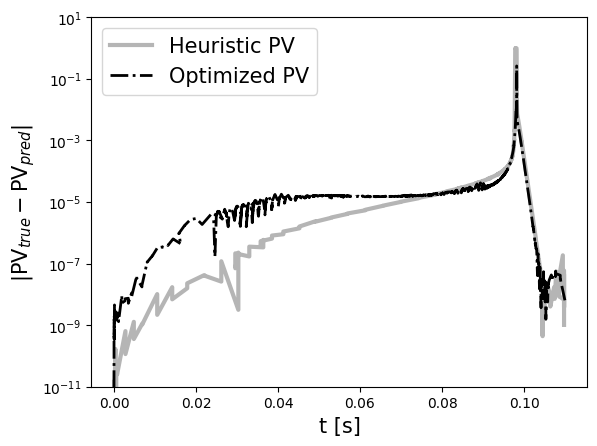

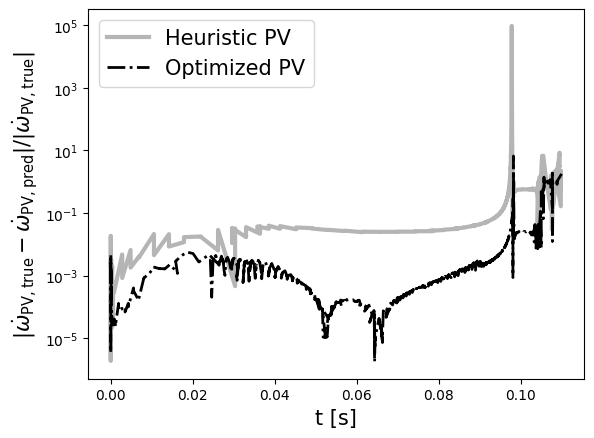

In [61]:
plt.plot(time_predicted_Xu, np.abs(PV_Xu_true_4_scaled - PV_Xu_predicted_4_scaled), label = "Heuristic PV", color = greys(0.4), linewidth = 3, linestyle = "-")
plt.plot(time_predicted_optimized, np.abs(PV_optimized_true_4_scaled - PV_optimized_predicted_4_scaled), label = "Optimized PV", color = "k", linewidth = 2, linestyle = "-.")

plt.xlabel("t [s]", fontsize = 15)
plt.ylabel("$|\mathrm{PV}_{true} - \mathrm{PV}_{pred}|$", fontsize = 15)
plt.yscale("log")
plt.ylim(1e-11, 10)
plt.legend(fontsize = 15)
plt.show()

plt.plot(time_predicted_Xu, np.abs((PV_source_Xu_true_4-PV_source_Xu_predicted_4)/PV_source_Xu_true_4), label = "Heuristic PV", color = greys(0.4), linewidth = 3, linestyle = "-")
plt.plot(time_predicted_optimized, np.abs((PV_source_optimized_true_4 - PV_source_optimized_predicted_4)/PV_source_optimized_true_4), label = "Optimized PV", color = "k", linewidth = 2, linestyle = "-.")
plt.xlabel("t [s]", fontsize = 15)
plt.ylabel("$|\dot{\omega}_{\mathrm{PV, true}} - \dot{\omega}_{\mathrm{PV, pred}}|/|\dot{\omega}_{\mathrm{PV, true}}|$", fontsize = 15)
plt.yscale("log")
plt.legend(fontsize = 15)
plt.show()

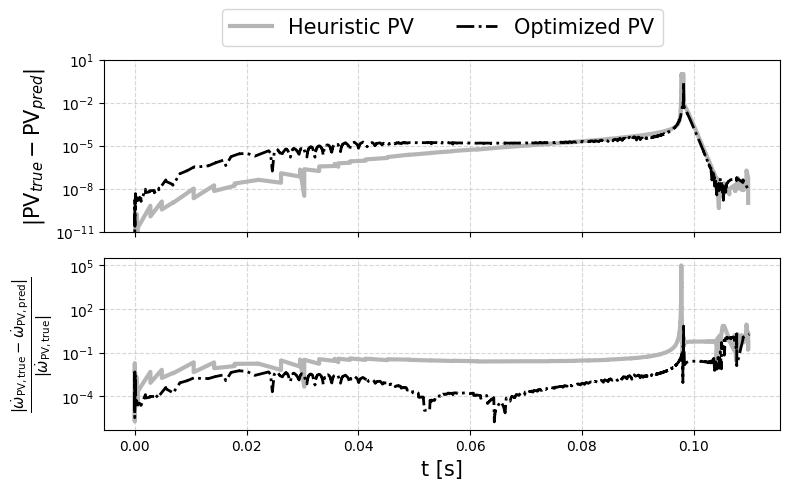

In [62]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled tabulation/A posteriori analysis/"
name = f"Heuristic vs optimized {id_model} - A posteriori analysis - Scaled tabulation"

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 5), sharex=True)

# --- First subplot ---

sorted_indices_Xu = np.argsort(time_predicted_Xu)
sorted_indices_optimized = np.argsort(time_predicted_optimized)

axs[0].plot(time_predicted_Xu[sorted_indices_Xu], np.abs(PV_Xu_true_4_scaled[sorted_indices_Xu] - PV_Xu_predicted_4_scaled[sorted_indices_Xu]),
            label="Heuristic PV", color=greys(0.4), linewidth=3, linestyle="-")
axs[0].plot(time_predicted_optimized[sorted_indices_optimized], np.abs(PV_optimized_true_4_scaled[sorted_indices_optimized] - PV_optimized_predicted_4_scaled[sorted_indices_optimized]),
            label="Optimized PV", color="k", linewidth=2, linestyle="-.")

axs[0].set_ylabel(r"$|\mathrm{PV}_{true} - \mathrm{PV}_{pred}|$", fontsize=15)
axs[0].set_yscale("log")
axs[0].set_ylim(1e-11, 10)
axs[0].legend(
    fontsize=15,
    ncols=2,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02)
)
axs[0].grid(True, which="both", linestyle="--", alpha=0.5)

# --- Second subplot ---
axs[1].plot(time_predicted_Xu[sorted_indices_Xu], np.abs((PV_source_Xu_true_4[sorted_indices_Xu] - PV_source_Xu_predicted_4[sorted_indices_Xu]) / PV_source_Xu_true_4[sorted_indices_Xu]),
            label="Heuristic PV", color=greys(0.4), linewidth=3, linestyle="-")
axs[1].plot(time_predicted_optimized[sorted_indices_optimized], np.abs((PV_source_optimized_true_4[sorted_indices_optimized] - PV_source_optimized_predicted_4[sorted_indices_optimized]) / PV_source_optimized_true_4[sorted_indices_optimized]),
            label="Optimized PV", color="k", linewidth=2, linestyle="-.")
axs[1].set_xlabel("t [s]", fontsize=15)
axs[1].set_ylabel(r"$\frac{|\dot{\omega}_{\mathrm{PV, true}} - \dot{\omega}_{\mathrm{PV, pred}}|}{|\dot{\omega}_{\mathrm{PV, true}}|}$", fontsize=15)
axs[1].set_yscale("log")
axs[1].grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
plt.show()

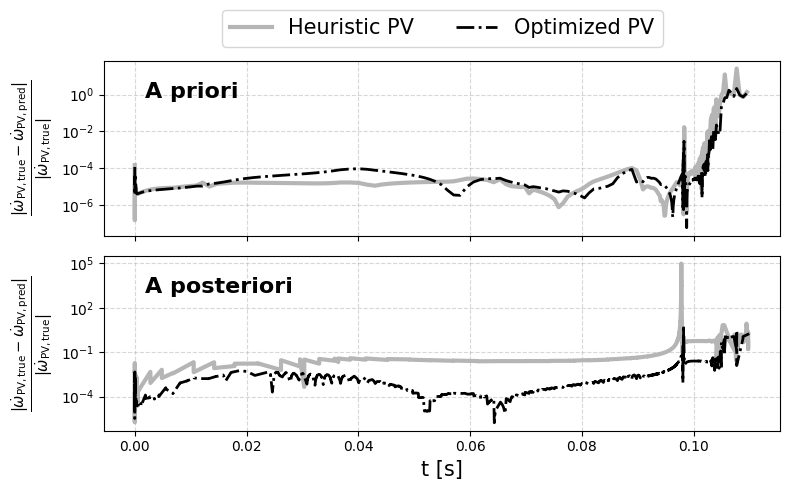

In [63]:
#test source terms
with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-sources-test-trajectories.h5", 'r') as hf:
    test_trajectory_source = pd.DataFrame(hf[f'test_trajectory_{4}'][:], columns = state_space_names)
    state_space_source_test_DNS = test_trajectory_source[state_space_names_DNS].to_numpy()
    PV_optimized_source_test = PV_model.get_PV(torch.from_numpy(np.delete(state_space_source_test_DNS, idx_species_removed, axis=1))).detach().numpy()
    
    PV_Xu_source_test = test_trajectory_source["H2O"] - test_trajectory_source["H2"] - test_trajectory_source["O2"]
    PV_Xu_source_test = PV_Xu_source_test.to_numpy()

#test time trajectories
with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
    test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{4}'][:])

relativeErrorXu = np.abs(PV_Xu_source_test.flatten() - prediction_test_trajectories[4].flatten())/np.abs(PV_Xu_source_test.flatten())
relErrorOptimized = np.abs(prediction_test_trajectories_optimized[4].flatten() - PV_optimized_source_test.flatten())/np.abs(PV_optimized_source_test.flatten())


save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled tabulation/A posteriori analysis/"
name = f"Comparison PV source relative a priori and a posteriori - Scaled tabulation"
namePdf = f"Comparison PV source relative a priori and a posteriori - Scaled tabulation.pdf"

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 5), sharex=True)

# --- First subplot ---

sorted_indices_Xu = np.argsort(time_predicted_Xu)
sorted_indices_optimized = np.argsort(time_predicted_optimized)

axs[0].plot(test_trajectory_time, relativeErrorXu, label = "Heuristic PV", color = greys(0.4), linewidth = 3, linestyle = "-")
axs[0].plot(test_trajectory_time, relErrorOptimized, label = "Optimized PV", color = "k", linewidth = 2, linestyle = "-.")

axs[0].set_ylabel(r"$\frac{|\dot{\omega}_{\mathrm{PV, true}} - \dot{\omega}_{\mathrm{PV, pred}}|}{|\dot{\omega}_{\mathrm{PV, true}}|}$", fontsize=15)
axs[0].set_yscale("log")
axs[0].legend(
    fontsize=15,
    ncols=2,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02)
)
axs[0].grid(True, which="both", linestyle="--", alpha=0.5)

# --- Second subplot ---
axs[1].plot(time_predicted_Xu[sorted_indices_Xu], np.abs((PV_source_Xu_true_4[sorted_indices_Xu] - PV_source_Xu_predicted_4[sorted_indices_Xu]) / PV_source_Xu_true_4[sorted_indices_Xu]),
            label="Heuristic PV", color=greys(0.4), linewidth=3, linestyle="-")
axs[1].plot(time_predicted_optimized[sorted_indices_optimized], np.abs((PV_source_optimized_true_4[sorted_indices_optimized] - PV_source_optimized_predicted_4[sorted_indices_optimized]) / PV_source_optimized_true_4[sorted_indices_optimized]),
            label="Optimized PV", color="k", linewidth=2, linestyle="-.")
axs[1].set_xlabel("t [s]", fontsize=15)
axs[1].set_ylabel(r"$\frac{|\dot{\omega}_{\mathrm{PV, true}} - \dot{\omega}_{\mathrm{PV, pred}}|}{|\dot{\omega}_{\mathrm{PV, true}}|}$", fontsize=15)
axs[1].set_yscale("log")
axs[1].grid(True, which="both", linestyle="--", alpha=0.5)

axs[0].text(0.06, 0.88, "A priori", transform=axs[0].transAxes,
            fontsize=16, fontweight='bold', verticalalignment='top', horizontalalignment='left')

axs[1].text(0.06, 0.88, "A posteriori", transform=axs[1].transAxes,
            fontsize=16, fontweight='bold', verticalalignment='top', horizontalalignment='left')

plt.tight_layout()
if(save):
    plt.savefig(pathSave + name, dpi=300, bbox_inches = "tight")
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()

## Reconstruction of a posteriori simulations

In [64]:
def get_interp_indices_and_weights(mf_data, mf_limit, PV_target, PV_data):
    """Compute indices and weights for 1D PV interpolation at a given mf."""
    mask_mf = (mf_data == mf_limit)
    PV_mask = PV_data[mask_mf]

    PV_lower = PV_mask[PV_mask <= PV_target]
    PV_upper = PV_mask[PV_mask >= PV_target]

    boolNoBelow = PV_lower.size == 0
    boolNoAbove = PV_upper.size == 0

    if boolNoBelow and boolNoAbove:
        raise ValueError("No PV above or below the target.")
    elif boolNoBelow:
        idx_low = idx_high = np.where(mask_mf)[0][np.argmin(np.abs(PV_mask - PV_target))]
        weight_low, weight_high = 0.0, 1.0
    elif boolNoAbove:
        idx_low = idx_high = np.where(mask_mf)[0][np.argmin(np.abs(PV_mask - PV_target))]
        weight_low, weight_high = 1.0, 0.0
    else:
        PV_low = PV_lower.max()
        PV_high = PV_upper.min()
        idx_low = np.where(mask_mf)[0][np.where(PV_mask == PV_low)[0][0]]
        idx_high = np.where(mask_mf)[0][np.where(PV_mask == PV_high)[0][0]]

        if PV_high == PV_low:
            weight_low, weight_high = 0.5, 0.5
        else:
            weight_low = (PV_high - PV_target) / (PV_high - PV_low)
            weight_high = (PV_target - PV_low) / (PV_high - PV_low)

    return idx_low, idx_high, weight_low, weight_high


def predict_species_all(mf_target, PV_target, mf_data, PV_data, multi_data):
    """Interpolates multiple species from the table for a given (mf, PV) point."""

    unique_mf = np.unique(mf_data)
    mf_below_all = unique_mf[unique_mf <= mf_target]
    mf_above_all = unique_mf[unique_mf >= mf_target]

    if mf_below_all.size == 0 or mf_above_all.size == 0:
        raise ValueError("Target mixture fraction outside bounds.")

    mf_low = mf_below_all.max()
    mf_high = mf_above_all.min()

    # Get indices and weights at mf_low and mf_high
    idx_low_mf_low, idx_high_mf_low, w1_low, w2_low = get_interp_indices_and_weights(mf_data, mf_low, PV_target, PV_data)
    idx_low_mf_high, idx_high_mf_high, w1_high, w2_high = get_interp_indices_and_weights(mf_data, mf_high, PV_target, PV_data)

    # Interpolate species values at mf_low and mf_high
    values_mf_low = w1_low * multi_data[idx_low_mf_low, :] + w2_low * multi_data[idx_high_mf_low, :] 
    values_mf_high = w1_high * multi_data[idx_low_mf_high, :]  + w2_high * multi_data[idx_high_mf_high, :] 

    if mf_high == mf_low:
        return values_mf_low  # or values_mf_high; they should be the same

    # Final interpolation in mf dimension
    final_weights = (mf_target - mf_low) / (mf_high - mf_low)
    result = values_mf_low * (1 - final_weights) + values_mf_high * final_weights

    return result

In [65]:
i = 0
with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)

QoIs = ["H2O2", "H2O", "H2", "HO2", "N2O", "NO2", "NO", "O2", "OH", "T"]

qoi_train_data = np.hstack([state_space_train[qoi].values[:, np.newaxis] for qoi in QoIs])

reconstruction_Xu = []

for idxSimulations in range(len(list_simulations_Xu)):
    reconstruction_simulation = []

    PV_traj_min = list_simulations_Xu[idxSimulations][:, 1].min()
    PV_traj_max =  list_simulations_Xu[idxSimulations][:, 1].max()

    for idx in range(len(list_simulations_Xu[idxSimulations])):
        PV_predicted_scaled = (list_simulations_Xu[idxSimulations][idx][1] - PV_traj_min)/(PV_traj_max - PV_traj_min)
        reconstruction_simulation.append(predict_species_all(list_simulations_Xu[idxSimulations][idx][0], PV_predicted_scaled,
                                                             mixture_fractions_train, PV_Xu_scaled, qoi_train_data))
    reconstruction_Xu.append(reconstruction_simulation)

reconstruction_Xu = [np.vstack(inner_list) for inner_list in reconstruction_Xu]

In [66]:
reconstruction_heuH2O = []

for idxSimulations in range(len(list_simulations_heuH2O)):
    reconstruction_simulation = []

    PV_traj_min = list_simulations_heuH2O[idxSimulations][:, 1].min()
    PV_traj_max =  list_simulations_heuH2O[idxSimulations][:, 1].max()

    for idx in range(len(list_simulations_heuH2O[idxSimulations])):
        PV_predicted_scaled = (list_simulations_heuH2O[idxSimulations][idx][1] - PV_traj_min)/(PV_traj_max - PV_traj_min)
        reconstruction_simulation.append(predict_species_all(list_simulations_heuH2O[idxSimulations][idx][0], PV_predicted_scaled,
                                                             mixture_fractions_train, PV_heuH2O_scaled, qoi_train_data))
    reconstruction_heuH2O.append(reconstruction_simulation)

reconstruction_heuH2O = [np.vstack(inner_list) for inner_list in reconstruction_heuH2O]

In [67]:
reconstruction_heu10HO2 = []

for idxSimulations in range(len(list_simulations_heu10HO2)):
    reconstruction_simulation = []

    PV_traj_min = list_simulations_heu10HO2[idxSimulations][:, 1].min()
    PV_traj_max =  list_simulations_heu10HO2[idxSimulations][:, 1].max()

    for idx in range(len(list_simulations_heu10HO2[idxSimulations])):
        PV_predicted_scaled = (list_simulations_heu10HO2[idxSimulations][idx][1] - PV_traj_min)/(PV_traj_max - PV_traj_min)
        reconstruction_simulation.append(predict_species_all(list_simulations_heu10HO2[idxSimulations][idx][0], PV_predicted_scaled,
                                                             mixture_fractions_train, PV_heu10HO2_scaled, qoi_train_data))
    reconstruction_heu10HO2.append(reconstruction_simulation)

reconstruction_heu10HO2 = [np.vstack(inner_list) for inner_list in reconstruction_heu10HO2]

In [68]:
reconstruction_heu1NO = []

for idxSimulations in range(len(list_simulations_heu1NO)):
    reconstruction_simulation = []

    PV_traj_min = list_simulations_heu1NO[idxSimulations][:, 1].min()
    PV_traj_max =  list_simulations_heu1NO[idxSimulations][:, 1].max()

    for idx in range(len(list_simulations_heu1NO[idxSimulations])):
        PV_predicted_scaled = (list_simulations_heu1NO[idxSimulations][idx][1] - PV_traj_min)/(PV_traj_max - PV_traj_min)
        reconstruction_simulation.append(predict_species_all(list_simulations_heu1NO[idxSimulations][idx][0], PV_predicted_scaled,
                                                             mixture_fractions_train, PV_heu1NO_scaled, qoi_train_data))
    reconstruction_heu1NO.append(reconstruction_simulation)

reconstruction_heu1NO = [np.vstack(inner_list) for inner_list in reconstruction_heu1NO]

In [69]:
reconstruction_optimized = []

for idxSimulations in range(len(list_simulations_optimized)):
    reconstruction_simulation = []

    PV_traj_min = list_simulations_optimized[idxSimulations][:, 1].min()
    PV_traj_max =  list_simulations_optimized[idxSimulations][:, 1].max()

    for idx in range(len(list_simulations_optimized[idxSimulations])):
        PV_predicted_scaled = (list_simulations_optimized[idxSimulations][idx][1] - PV_traj_min)/(PV_traj_max - PV_traj_min)
        reconstruction_simulation.append(predict_species_all(list_simulations_optimized[idxSimulations][idx][0], PV_predicted_scaled,
                                                             mixture_fractions_train, PV_optimized_scaled, qoi_train_data))
    reconstruction_optimized.append(reconstruction_simulation)

reconstruction_optimized = [np.vstack(inner_list) for inner_list in reconstruction_optimized]

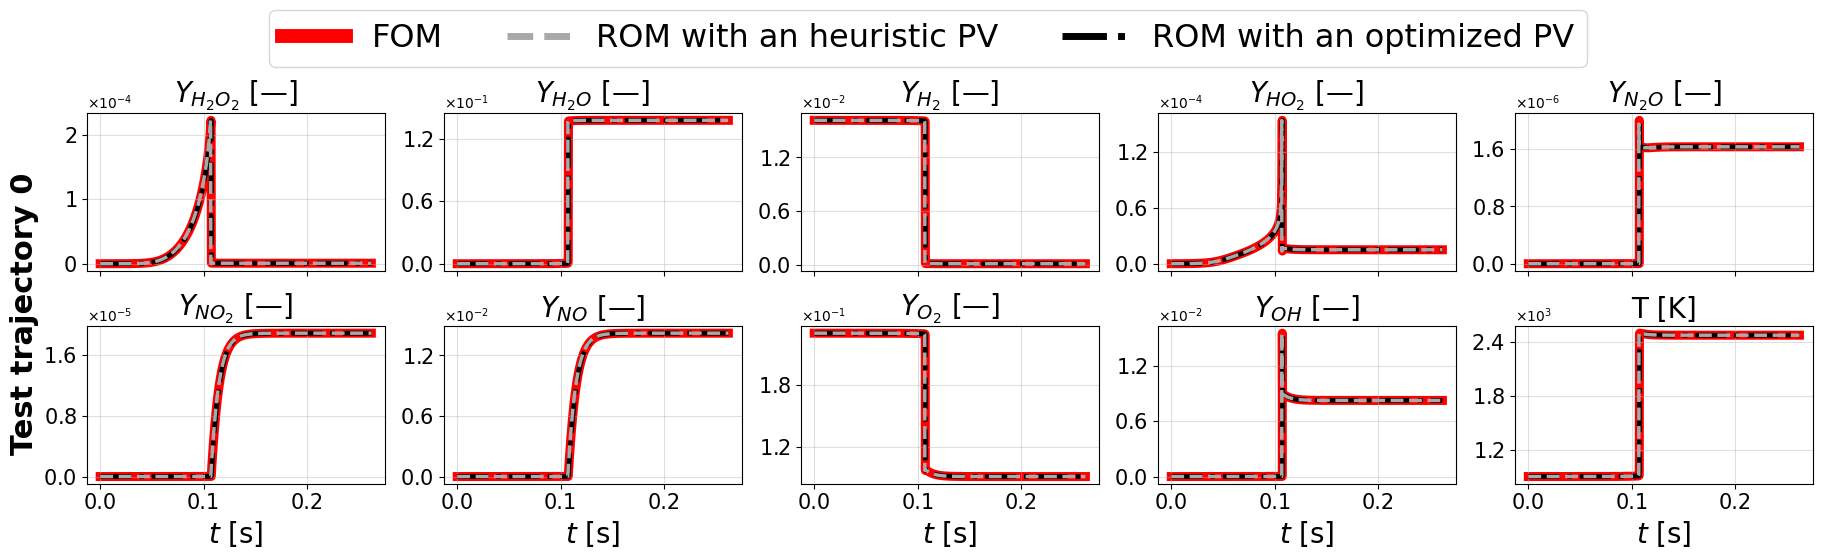

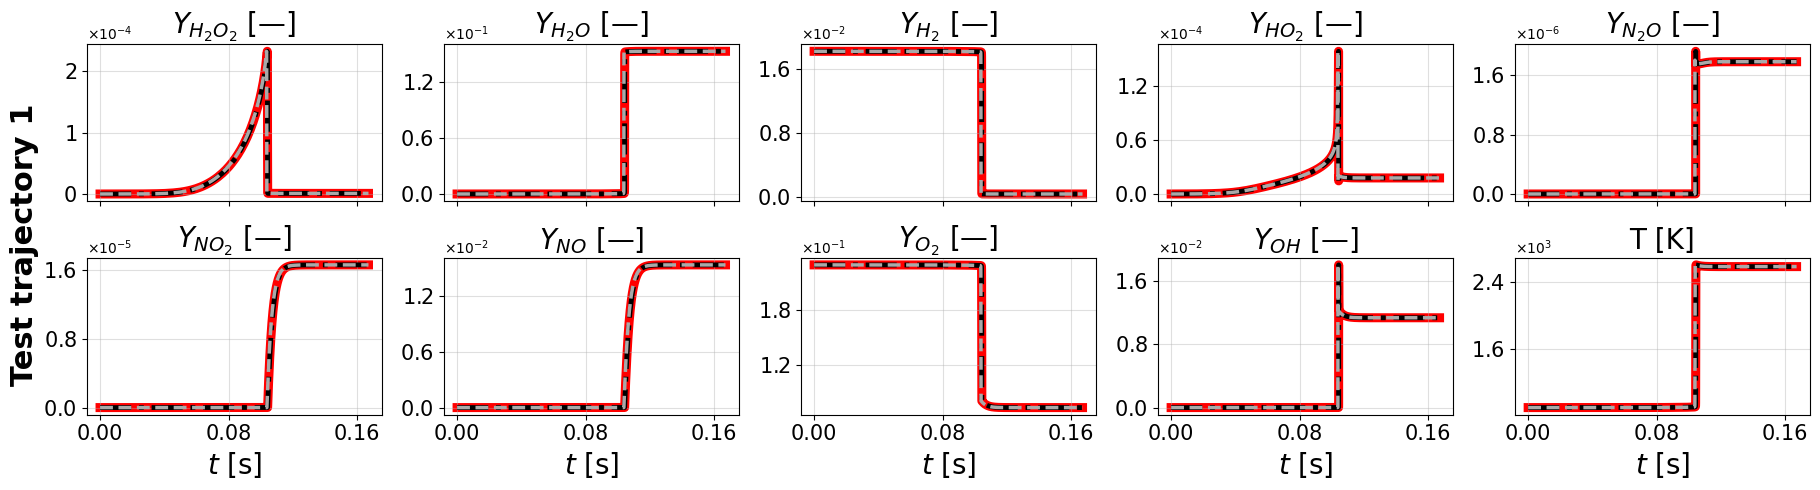

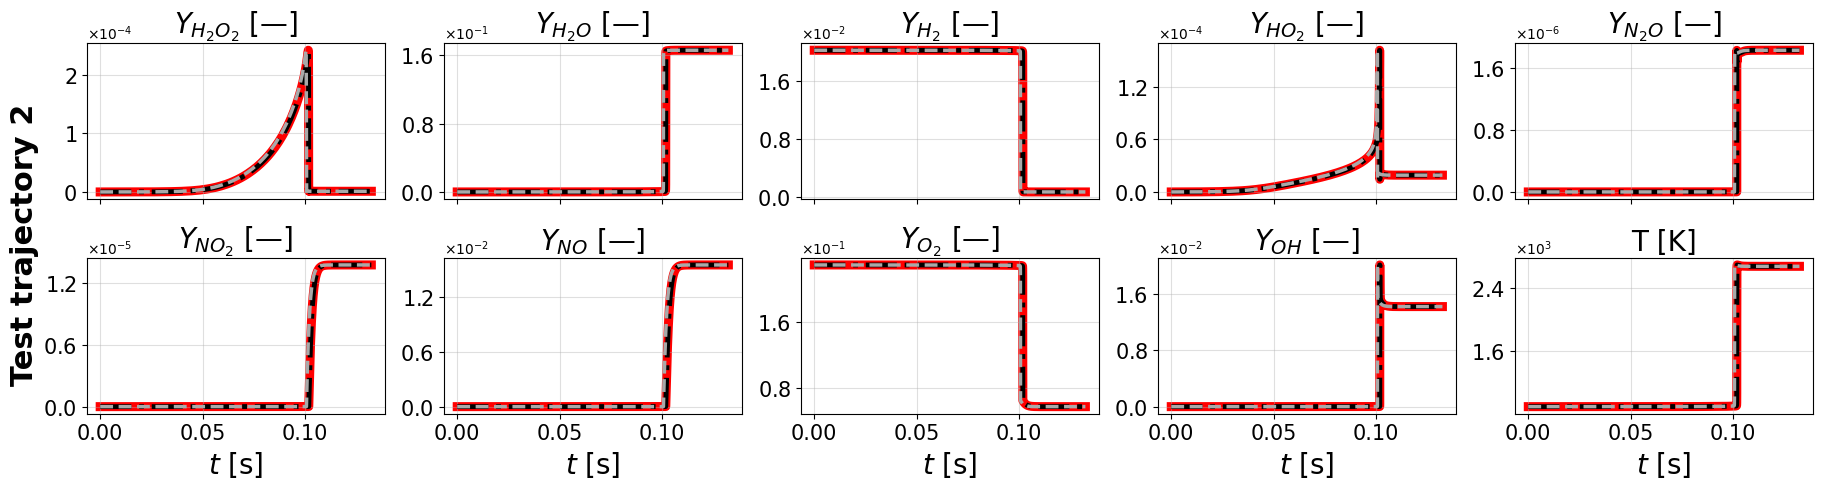

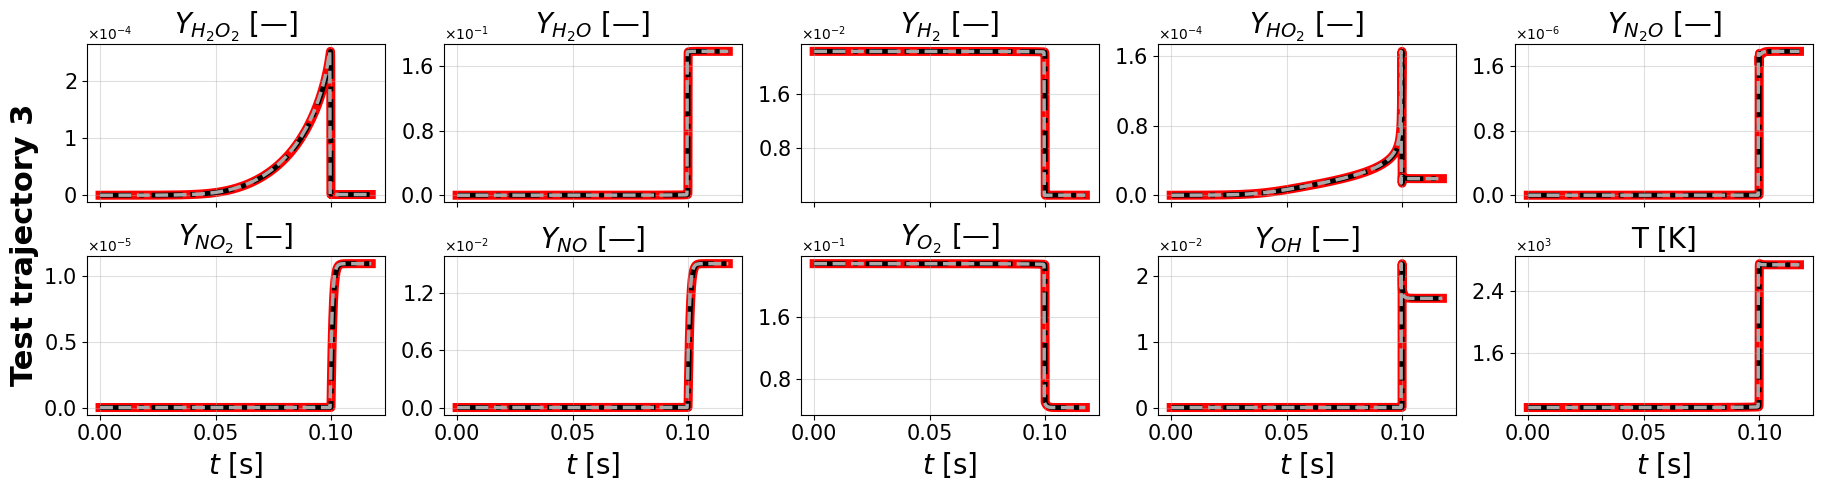

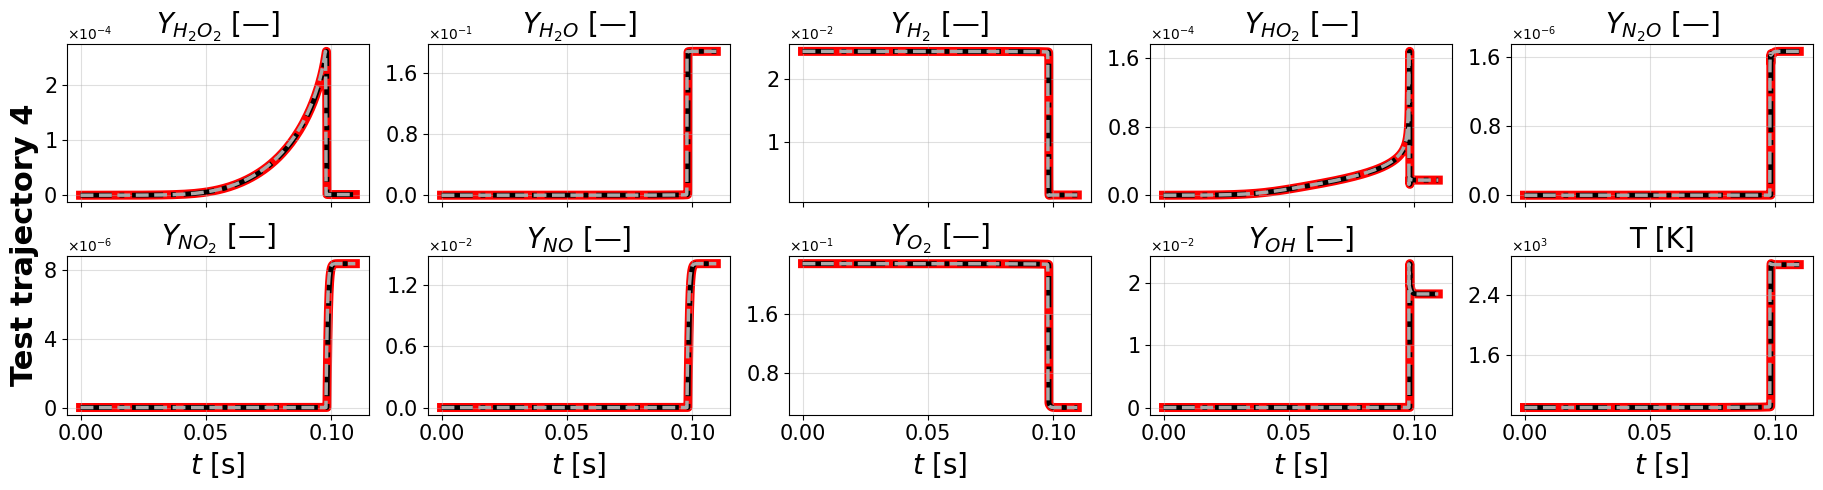

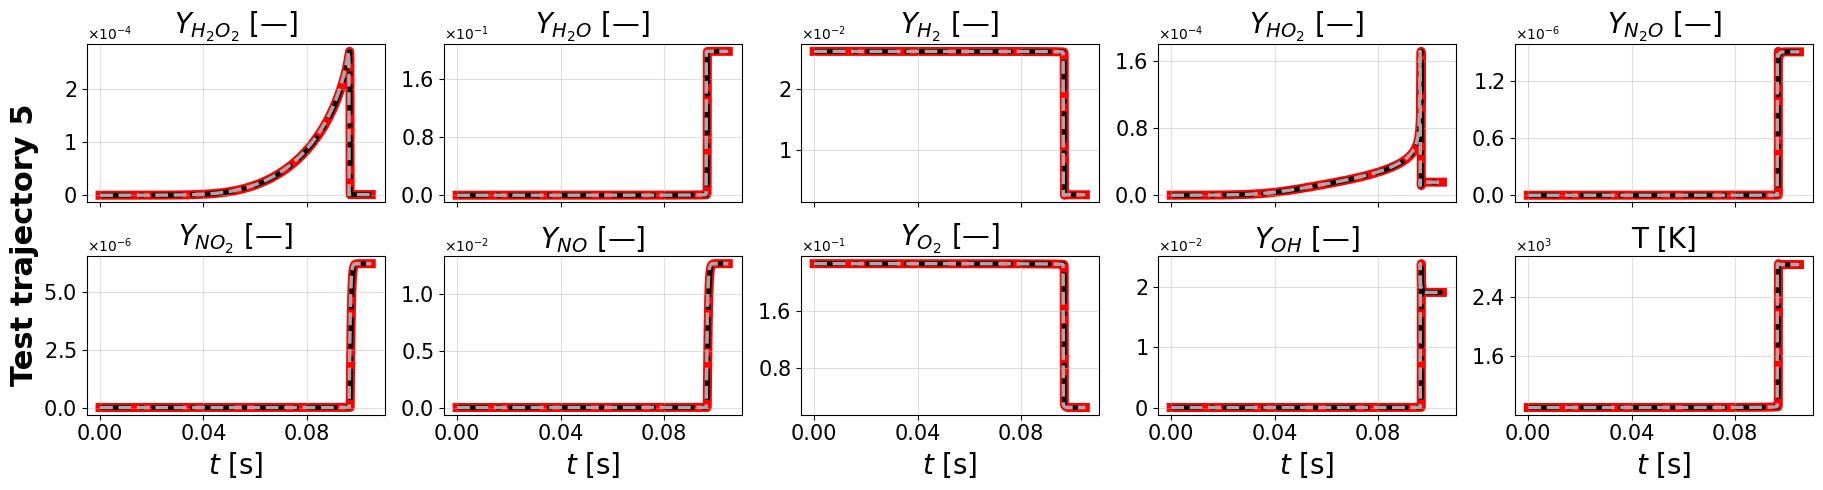

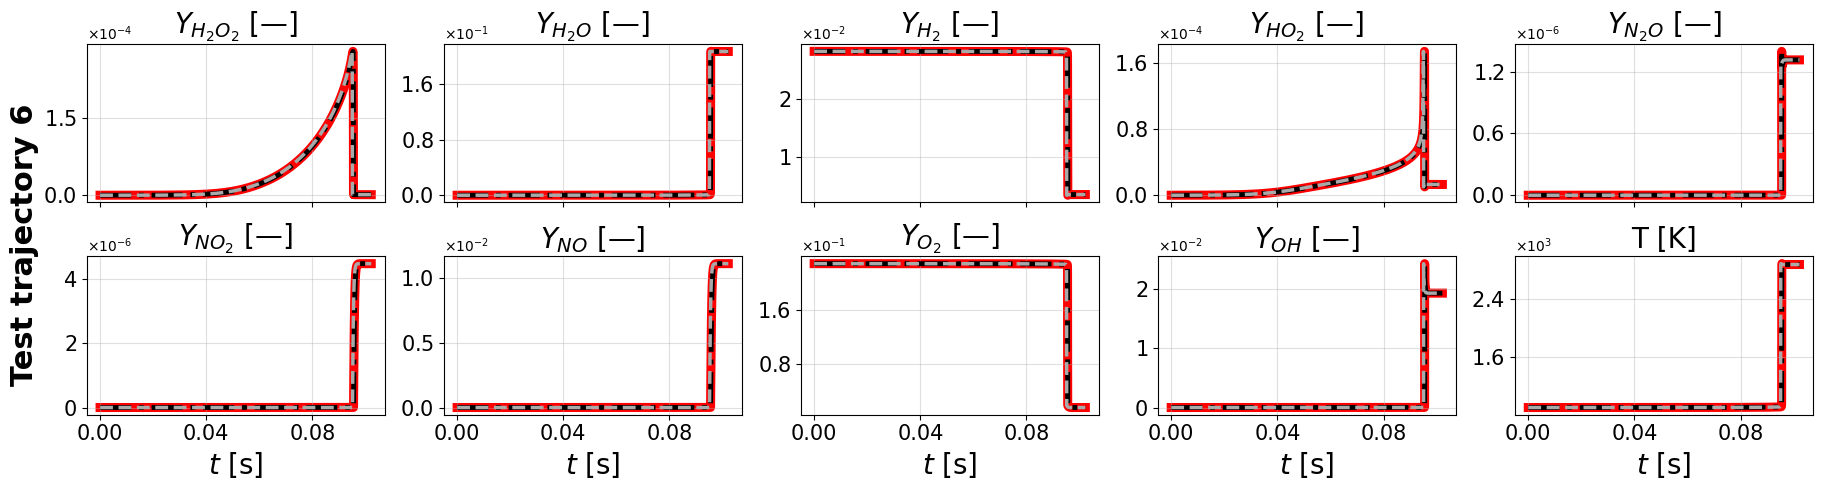

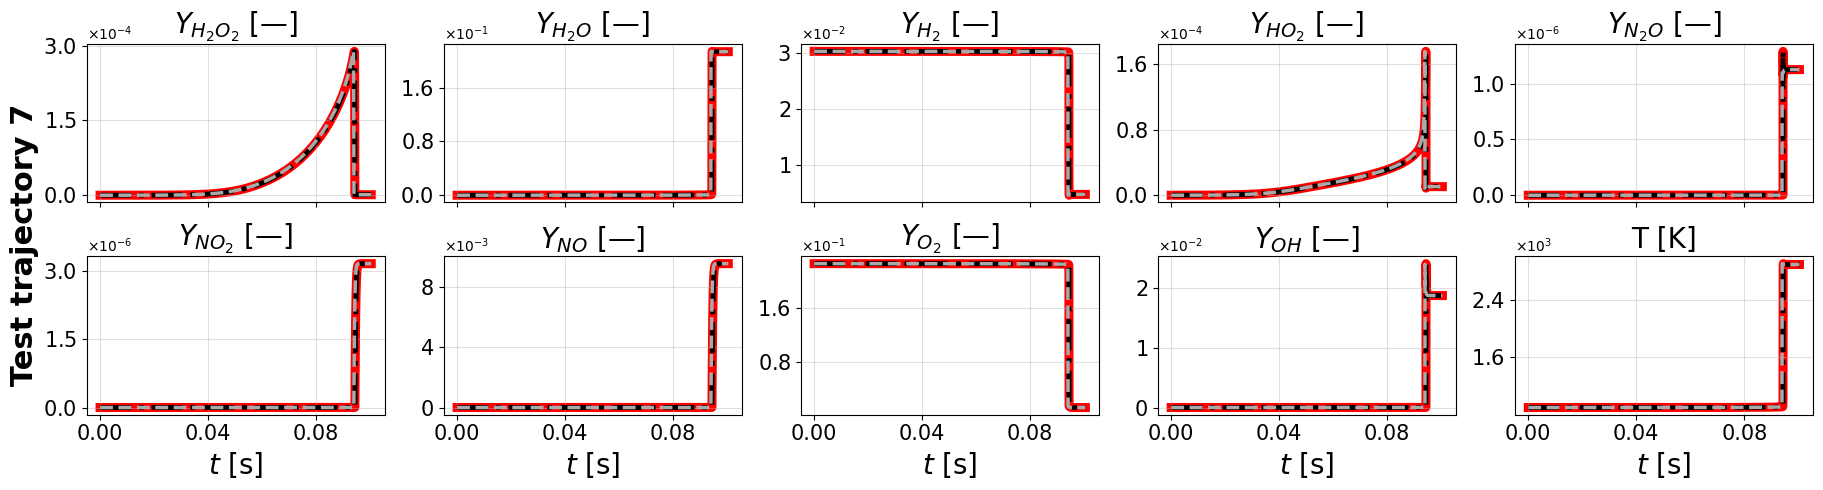

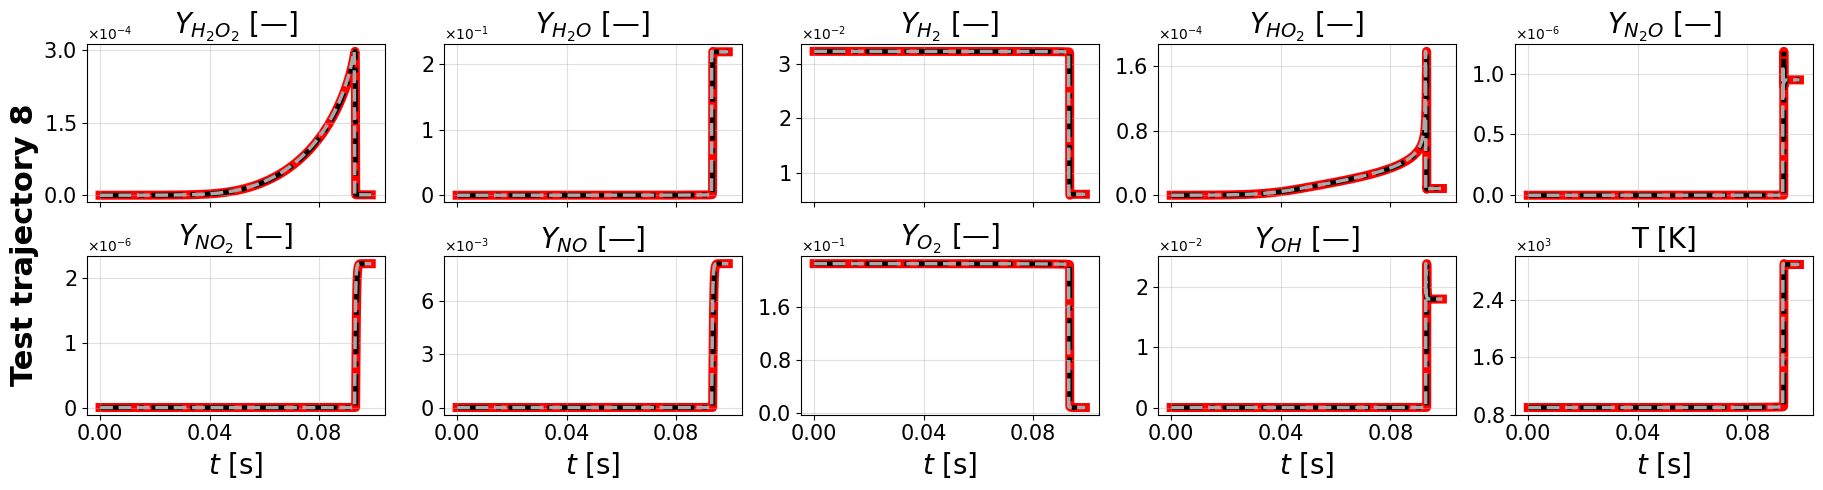

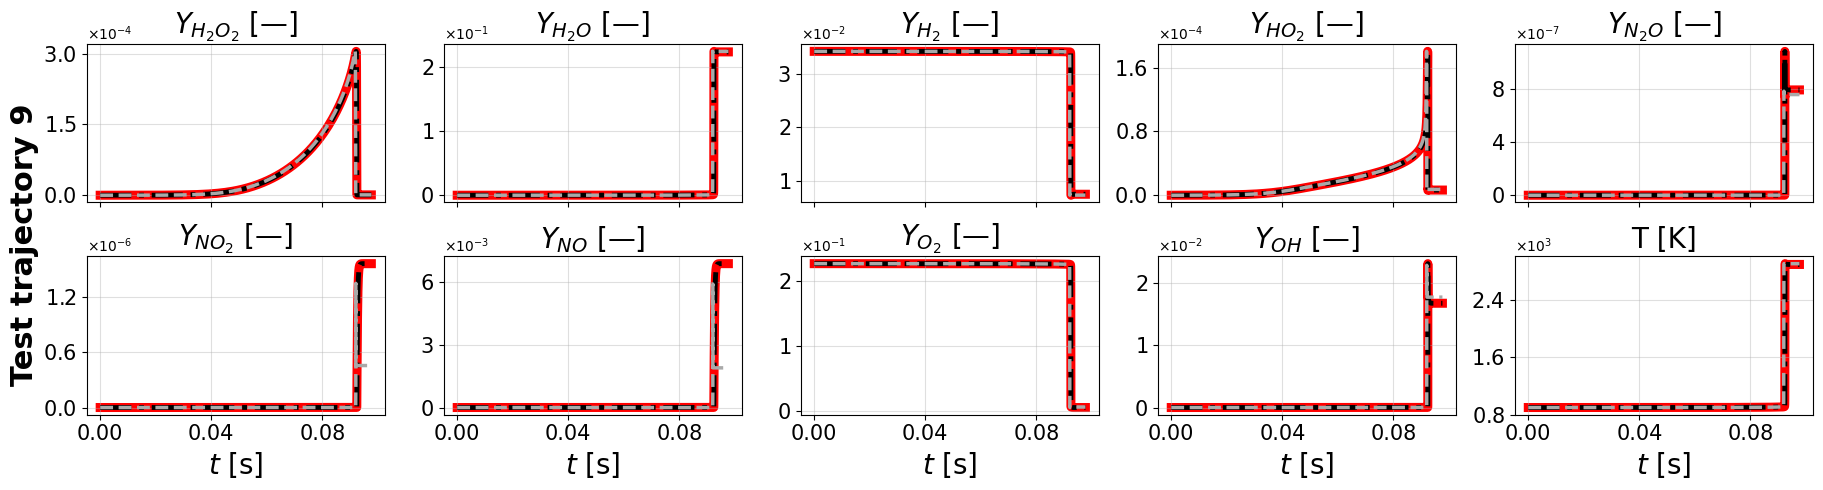

In [70]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled tabulation/A posteriori/"
name = f"Heuristic vs optimized {id_model} - A posteriori - Scaled tabulation"

Output_species_Latex = [species.replace('2', '_2') for species in QoIs]

for idxSimulation in range(num_test_trajectories):

    rows, cols = 2, 5

    fig, axes = plt.subplots(rows, cols, figsize=(18, 5))
    axes = axes.flatten()

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
            test_trajectory = pd.DataFrame(hf[f'test_trajectory_{idxSimulation}'][:], columns = state_space_names)
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{idxSimulation}'][:])
    
    for idxQoI in range(len(QoIs)): 
      ax = axes[idxQoI]
      
      ax.plot(test_trajectory_time[idx_start_simulation:], test_trajectory[QoIs[idxQoI]].iloc[idx_start_simulation:], label = "FOM", c="red", linestyle="-", linewidth=6.5, zorder = 1)  # True trajectory
      ax.plot(test_trajectory_time[idx_start_simulation:], reconstruction_Xu[idxSimulation][:, idxQoI], label = "ROM with an heuristic PV", c="darkgrey", linestyle="--", linewidth=2.5, zorder = 3)
      ax.plot(test_trajectory_time[idx_start_simulation:], reconstruction_optimized[idxSimulation][:, idxQoI], label = "ROM with an optimized PV", c="k", linestyle="dashdot", linewidth=3.5, zorder = 2)
      
      if(QoIs[idxQoI] == "T"):
        ax.set_title(f"T [K]", fontsize = 20)
      else:
         ax.set_title(f"$Y_{{{Output_species_Latex[idxQoI]}}}$ [\u2014]", fontsize = 20)


      ax.tick_params(axis='x', labelsize=15) 
      ax.tick_params(axis='y', labelsize=15)

      ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
      ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
      if(idxQoI>= num_test_trajectories-cols):
        ax.set_xlabel(f"$t$ [s]", fontsize = 20)
        
      else:
        ax.set_xticklabels([])
      
      formatter = ScalarFormatter(useMathText=True)
      formatter.set_powerlimits((0, 0))
      ax.yaxis.set_major_formatter(formatter)
      ax.grid(True, linestyle='-', alpha=0.4)
          
    for j in range(len(QoIs), len(axes)): #disables axes of plots not used
      axes[j].axis("off")
    
    handles, labels = axes[0].get_legend_handles_labels()
    legend_handles = [
        Line2D([0], [0], color='red', linestyle='-', linewidth=10, label='FOM'),
        Line2D([0], [0], color='darkgrey', linestyle='--', linewidth=5, label='ROM with an heuristic PV'),
        Line2D([0], [0], color='k', linestyle='dashdot', linewidth=5, label='ROM with an optimized PV'),
    ]
    if(idxSimulation == 0):
       
      fig.legend(legend_handles, labels,
                  loc='upper center', 
                  bbox_to_anchor=(0.5, 1.14), 
                  ncol=3, 
                  fontsize=23,
                  frameon=True
              )
    
    fig.text(-0.01, 0.5, f"Test trajectory {idxSimulation}", va='center', rotation='vertical', fontsize=22, fontweight='bold')

    plt.tight_layout() #h_pad = 0

    if(save):
        plt.savefig(f"{pathSave}{name}_testTraj{idxSimulation}.png", dpi=300, bbox_inches="tight")
        plt.savefig(f"{pathSave}{name}_testTraj{idxSimulation}.pdf", bbox_inches="tight")

    if(i==0):
        plt.show()

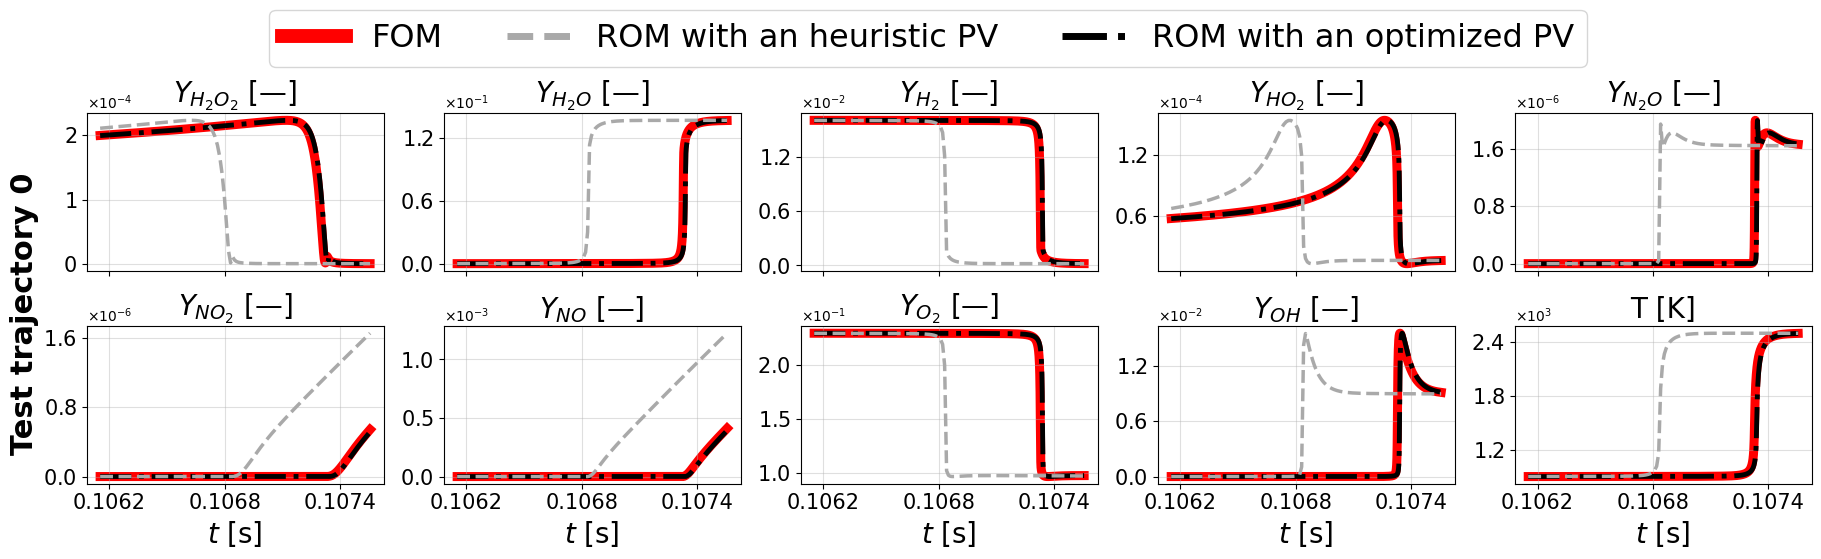

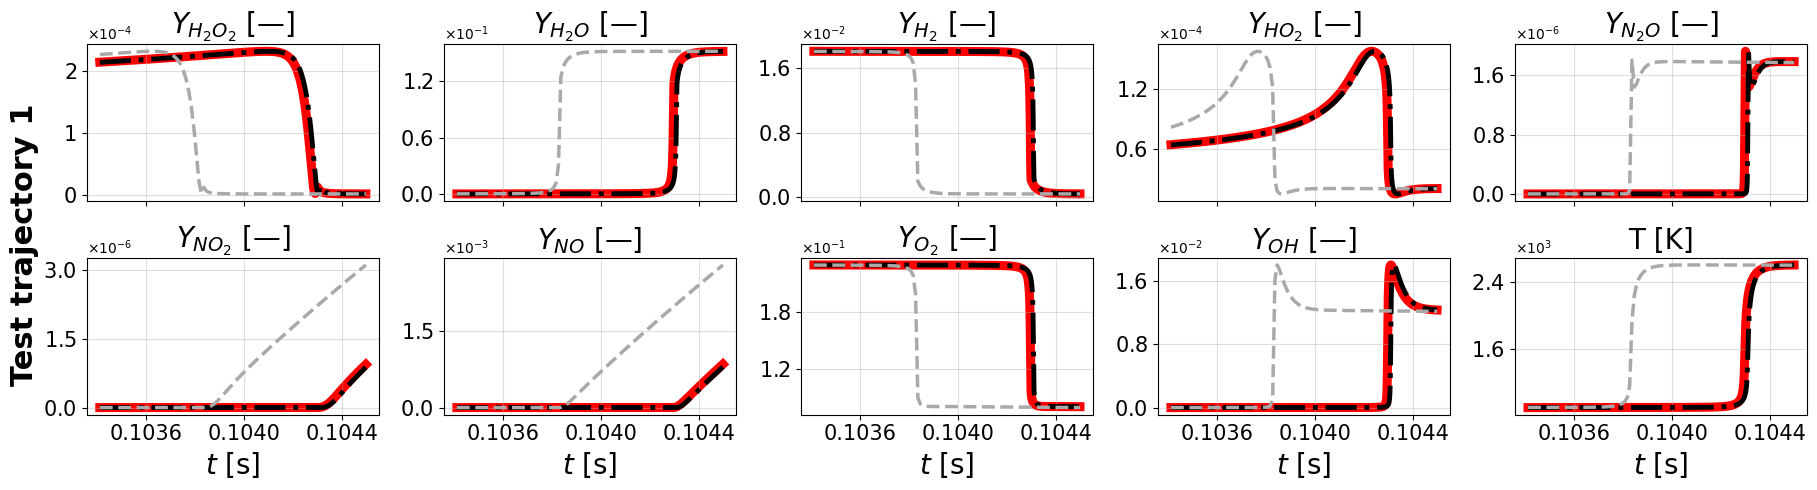

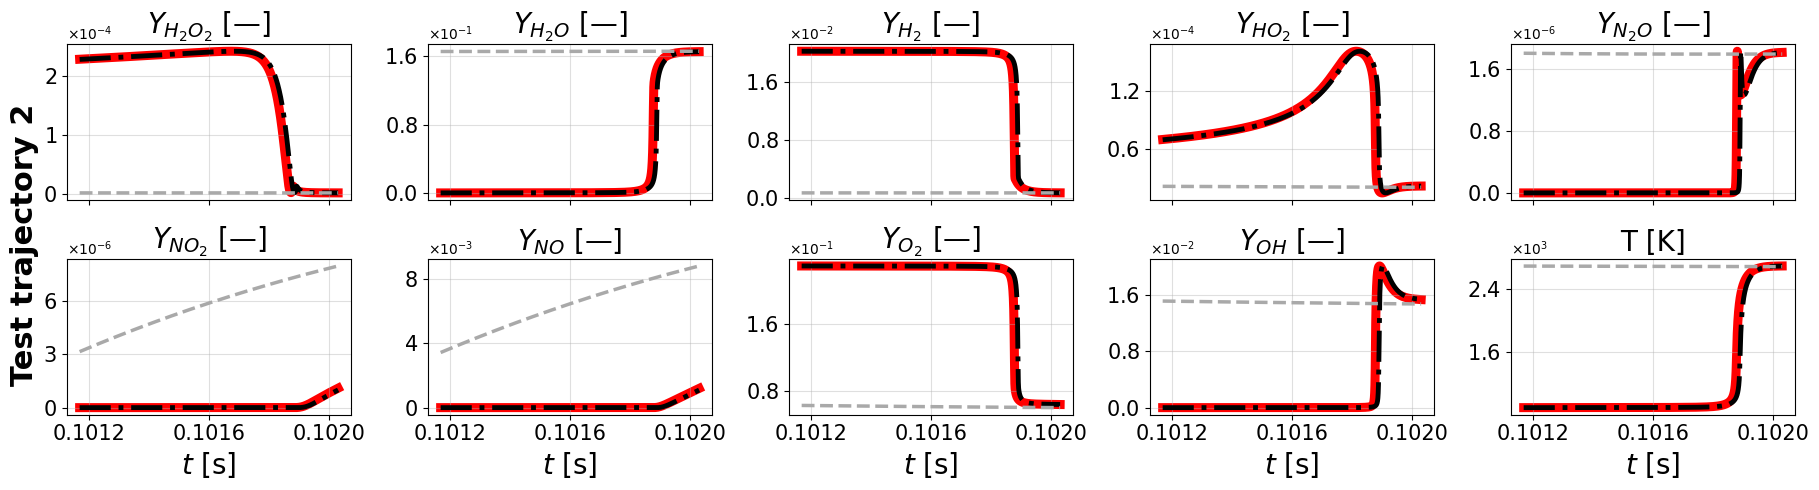

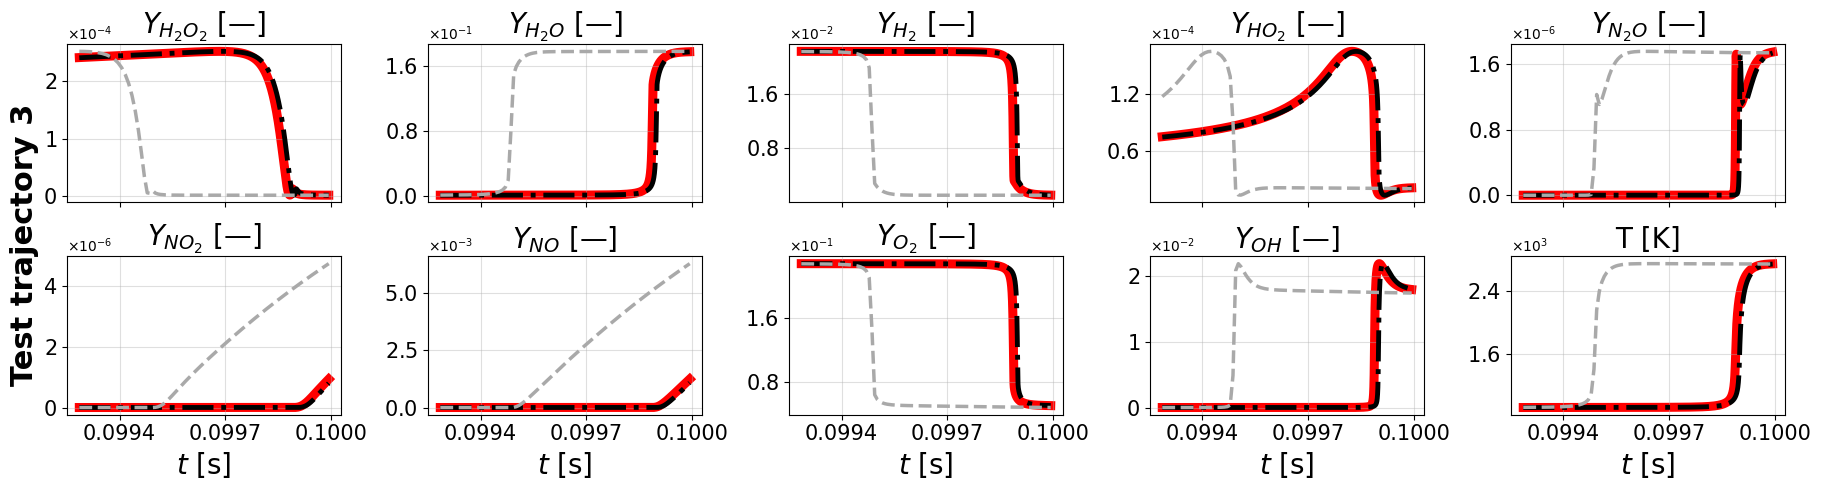

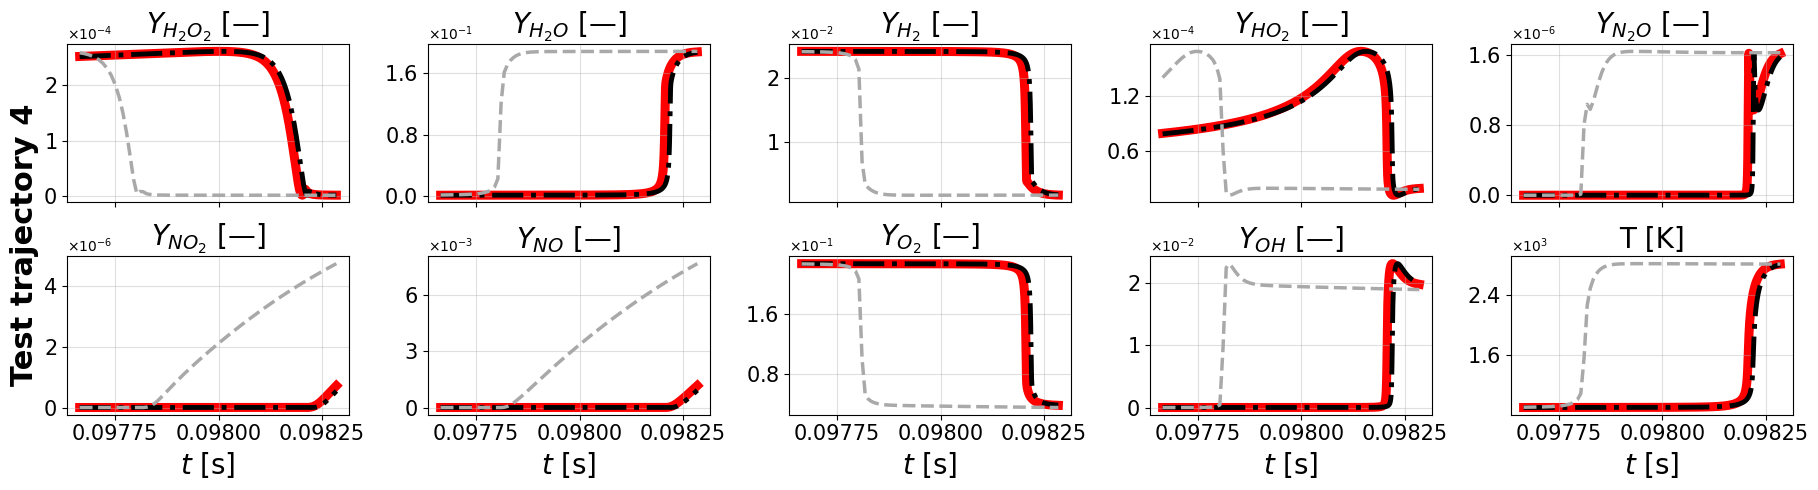

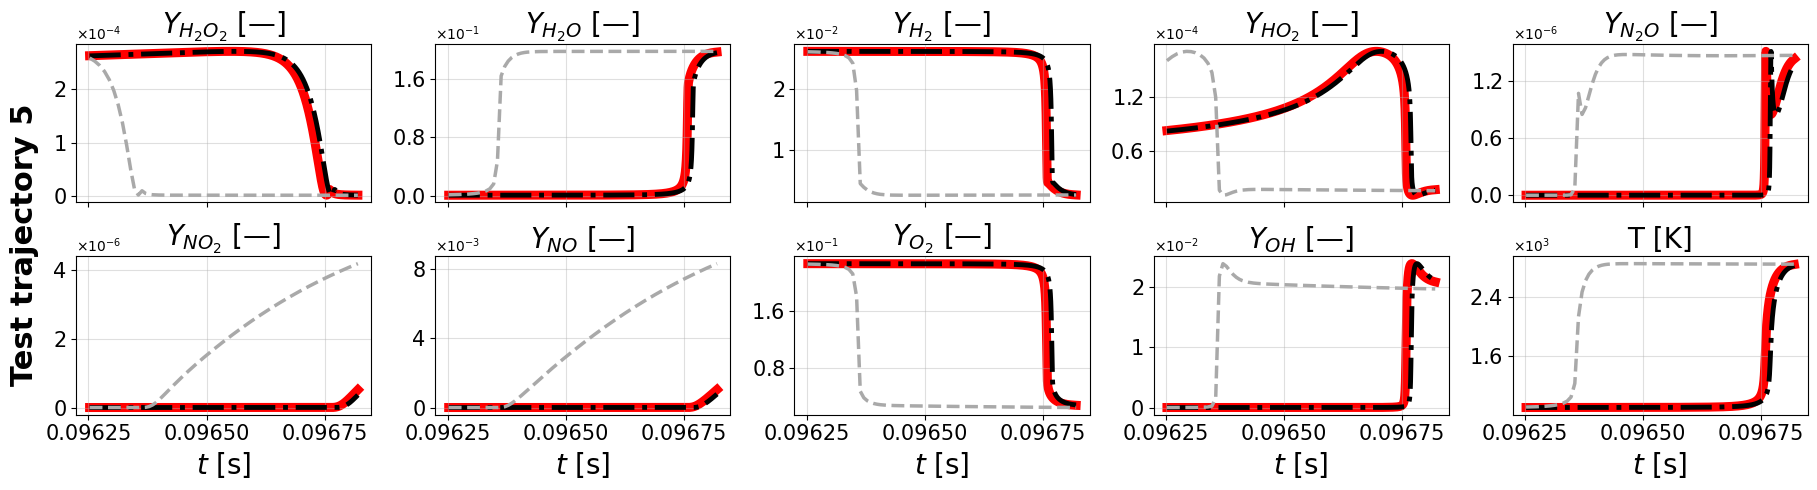

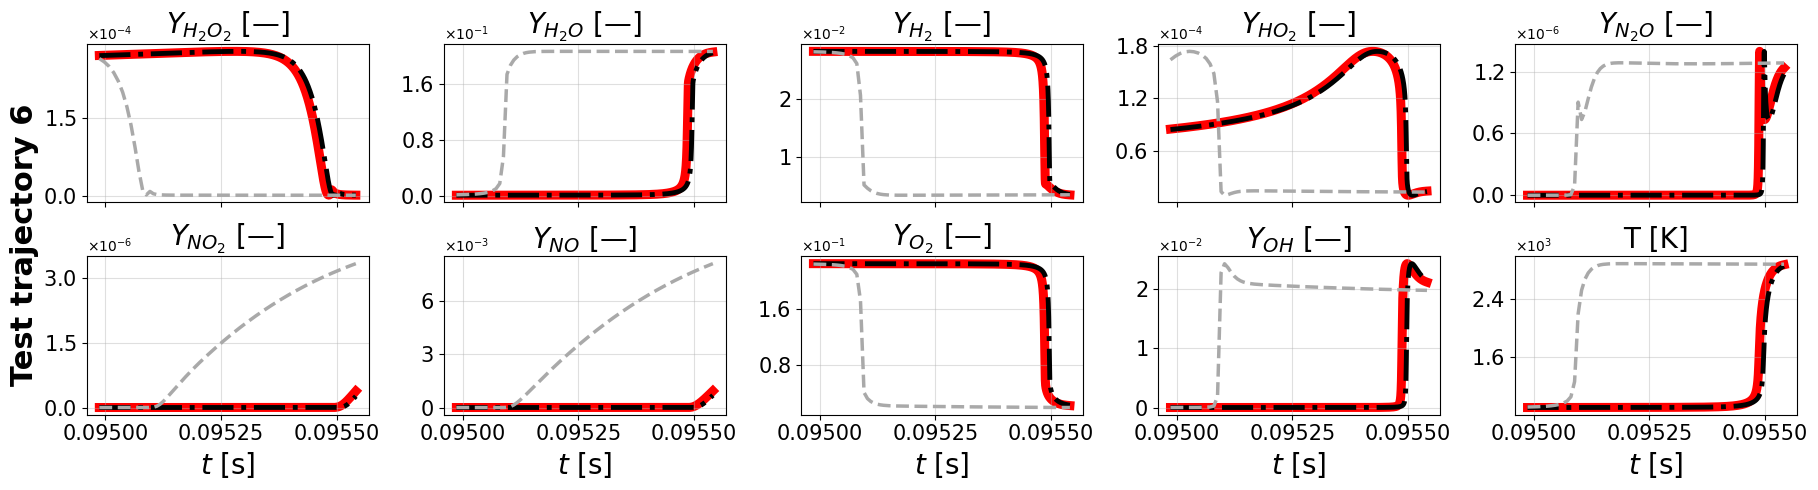

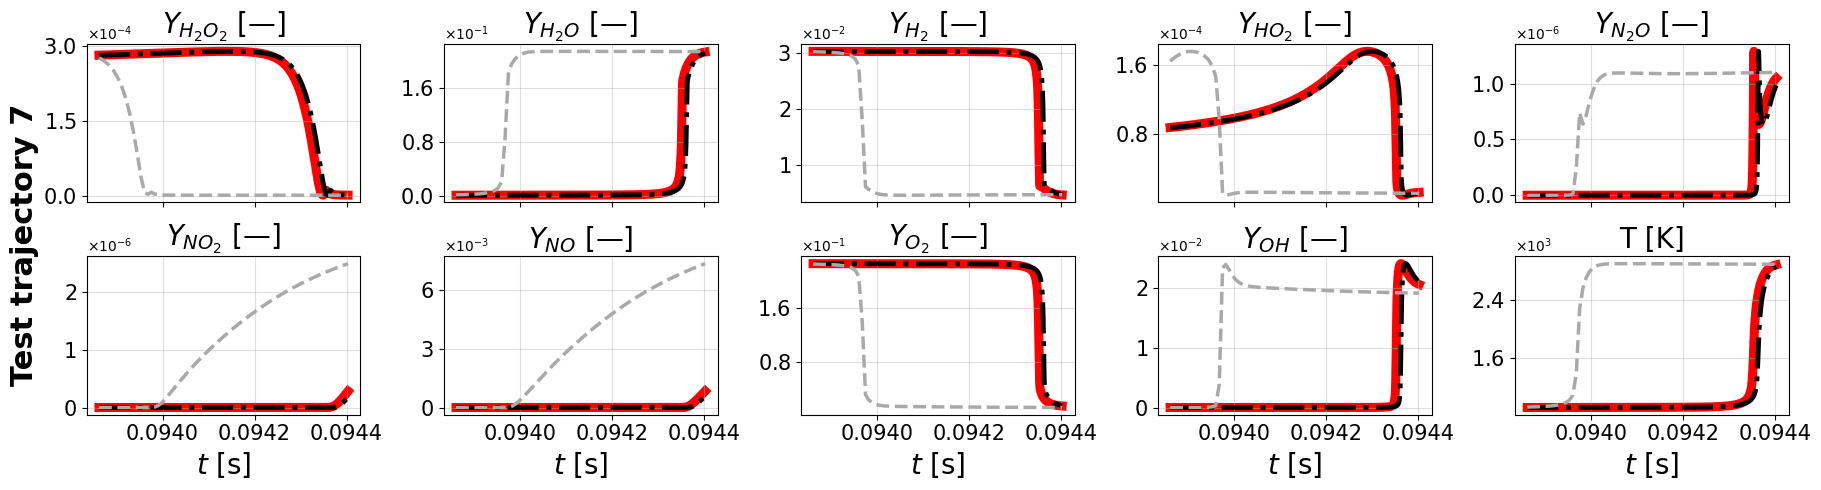

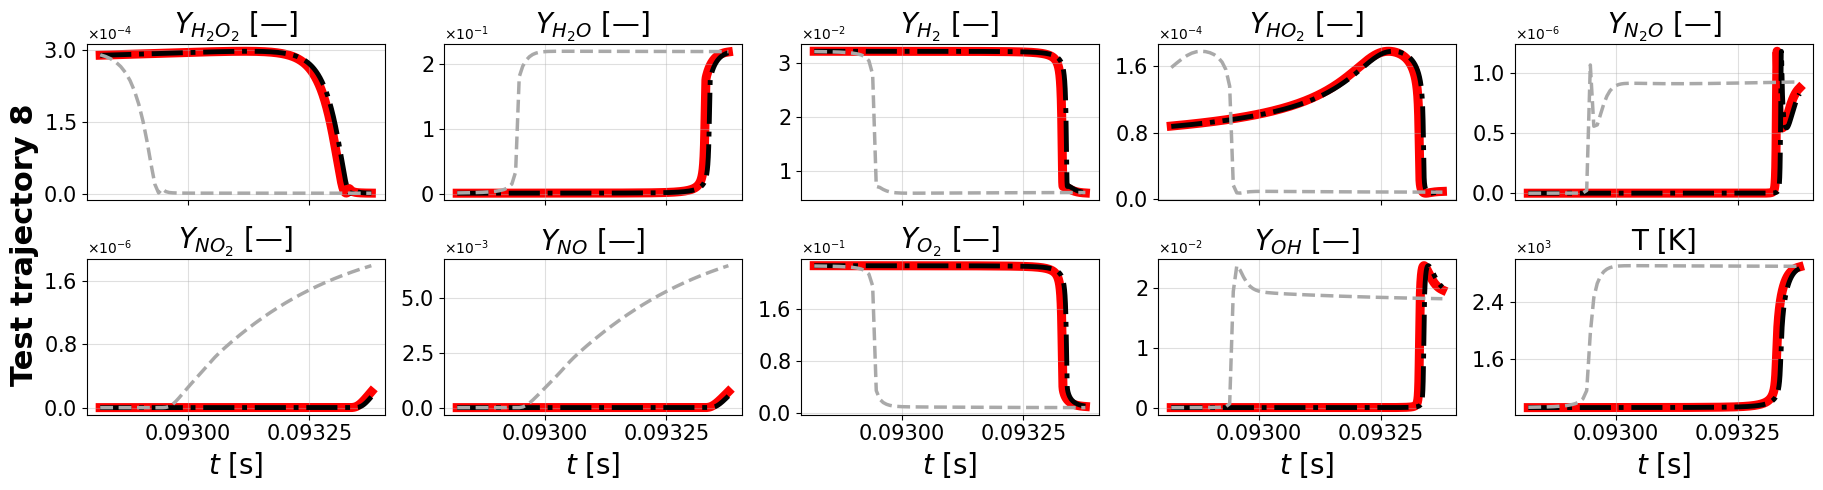

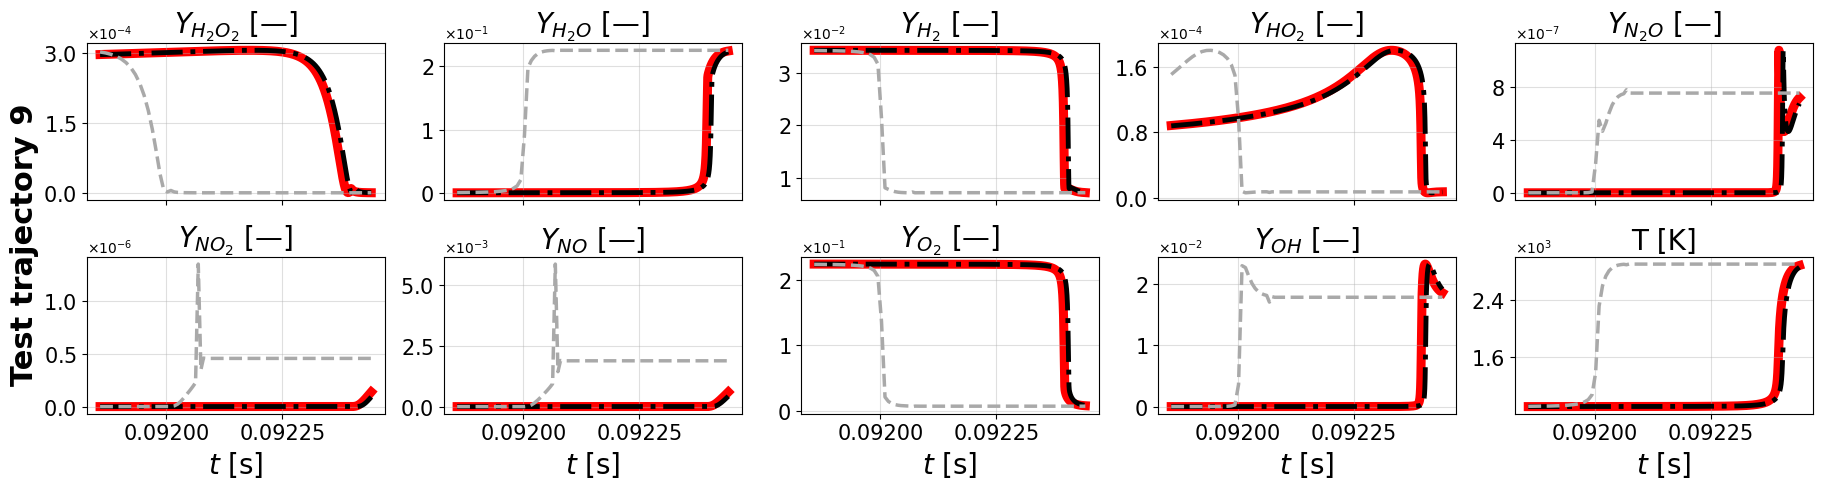

In [71]:
save = False
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled tabulation/A posteriori zoom/"

Output_species_Latex = [species.replace('2', '_2') for species in QoIs]

for idxSimulation in range(num_test_trajectories):

    rows, cols = 2, 5

    fig, axes = plt.subplots(rows, cols, figsize=(18, 5))
    axes = axes.flatten()

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
            test_trajectory = pd.DataFrame(hf[f'test_trajectory_{idxSimulation}'][:], columns = state_space_names)
    #test time trajectories
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
        test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{idxSimulation}'][:])

    ##############################################
    # Get the first and last index of the ignition
    ##############################################

    H2O_array = test_trajectory["H2O"].to_numpy()
    
    max_val = H2O_array.max()

    perc_lower = 0.003
    perc_upper = 0.995

    lower_threshold = perc_lower * max_val
    upper_threshold = perc_upper * max_val

    idx_1 = np.searchsorted(H2O_array, lower_threshold, side='left')
    idx_99 = np.searchsorted(H2O_array, upper_threshold, side='left')
    
    for idxQoI in range(len(QoIs)): 
      ax = axes[idxQoI]
      
      ax.plot(test_trajectory_time[idx_1:idx_99], test_trajectory[QoIs[idxQoI]].iloc[idx_1:idx_99], label = "FOM", c="red", linestyle="-", linewidth=6.5, zorder = 1)  # True trajectory
      ax.plot(test_trajectory_time[idx_1:idx_99], reconstruction_Xu[idxSimulation][idx_1:idx_99, idxQoI], label = "ROM with an heuristic PV", c="darkgrey", linestyle="--", linewidth=2.5, zorder = 3)
      ax.plot(test_trajectory_time[idx_1:idx_99], reconstruction_optimized[idxSimulation][idx_1:idx_99, idxQoI], label = "ROM with an optimized PV", c="k", linestyle="dashdot", linewidth=3.5, zorder = 2)
      
      if(QoIs[idxQoI] == "T"):
        ax.set_title(f"T [K]", fontsize = 20)
      else:
         ax.set_title(f"$Y_{{{Output_species_Latex[idxQoI]}}}$ [\u2014]", fontsize = 20)


      ax.tick_params(axis='x', labelsize=15) 
      ax.tick_params(axis='y', labelsize=15)

      ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
      ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
      if(idxQoI>= num_test_trajectories-cols):
        ax.set_xlabel(f"$t$ [s]", fontsize = 20)
        
      else:
        ax.set_xticklabels([])
      
      formatter = ScalarFormatter(useMathText=True)
      formatter.set_powerlimits((0, 0))
      ax.yaxis.set_major_formatter(formatter)
      ax.grid(True, linestyle='-', alpha=0.4)
          
    for j in range(len(QoIs), len(axes)): #disables axes of plots not used
      axes[j].axis("off")
    
    handles, labels = axes[0].get_legend_handles_labels()
    legend_handles = [
        Line2D([0], [0], color='red', linestyle='-', linewidth=10, label='FOM'),
        Line2D([0], [0], color='darkgrey', linestyle='--', linewidth=5, label='ROM with an heuristic PV'),
        Line2D([0], [0], color='k', linestyle='dashdot', linewidth=5, label='ROM with an optimized PV'),
    ]
    if(idxSimulation == 0):
       
      fig.legend(legend_handles, labels,
                  loc='upper center', 
                  bbox_to_anchor=(0.5, 1.14), 
                  ncol=3, 
                  fontsize=23,
                  frameon=True
              )
    
    fig.text(-0.01, 0.5, f"Test trajectory {idxSimulation}", va='center', rotation='vertical', fontsize=22, fontweight='bold')

    plt.tight_layout() #h_pad = 0

    name = f"Heuristic vs optimized {id_model} - A posteriori - Scaled tabulation - zoom {perc_lower}-{perc_upper}"

    if(save):
        plt.savefig(f"{pathSave}{name}_testTraj{idxSimulation}.png", dpi=300, bbox_inches="tight")
        plt.savefig(f"{pathSave}{name}_testTraj{idxSimulation}.pdf", bbox_inches="tight")

    if(i==0):
        plt.show()


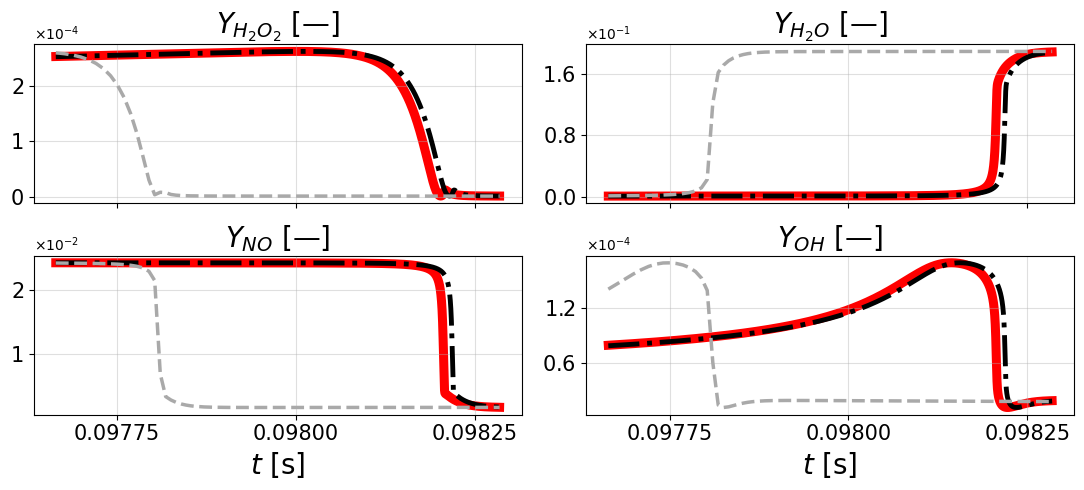

In [72]:
save = False
zoom = True
pathSave = "C:/Users/admin/Documents/Parente/Figures/2024-PV-optimization/Paper/Results/Autoignition/A posteriori simulations/4.1 - Scaled tabulation/A posteriori/"
name = f"Heuristic vs optimized {id_model}- A posteriori - Scaled tabulation - PRESENTATION{' - zoom' if zoom else ''}"

smallQoIs = ["H2O2", "H2O","NO", "OH"]

Output_species_Latex = [species.replace('2', '_2') for species in smallQoIs]

idxSimulation = 4

rows, cols = 2, 2

fig, axes = plt.subplots(rows, cols, figsize=(11, 5))
axes = axes.flatten()

with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{idxSimulation}'][:], columns = state_space_names)
#test time trajectories
with h5py.File(f"{path_data_autoignition}{filename_autoignition}time-test-trajectories.h5", 'r') as hf:
    test_trajectory_time = pd.DataFrame(hf[f'test_trajectory_{idxSimulation}'][:])

for idxQoI in range(len(smallQoIs)): 
    ax = axes[idxQoI]

    idxFullQoI = QoIs.index(smallQoIs[idxQoI])
    
    if zoom:
        H2O_array = test_trajectory["H2O"].to_numpy()
    
        max_val = H2O_array.max()

        perc_lower = 0.003
        perc_upper = 0.995

        lower_threshold = perc_lower * max_val
        upper_threshold = perc_upper * max_val

        idx_1 = np.searchsorted(H2O_array, lower_threshold, side='left')
        idx_99 = np.searchsorted(H2O_array, upper_threshold, side='left')

        ax.plot(test_trajectory_time[idx_1:idx_99], test_trajectory[QoIs[idxQoI]].iloc[idx_1:idx_99], label = "FOM", c="red", linestyle="-", linewidth=6.5, zorder = 1)  # True trajectory
        ax.plot(test_trajectory_time[idx_1:idx_99], reconstruction_Xu[idxSimulation][idx_1:idx_99, idxQoI], label = "ROM with an heuristic PV", c="darkgrey", linestyle="--", linewidth=2.5, zorder = 3)
        ax.plot(test_trajectory_time[idx_1:idx_99], reconstruction_optimized[idxSimulation][idx_1:idx_99, idxQoI], label = "ROM with an optimized PV", c="k", linestyle="dashdot", linewidth=3.5, zorder = 2)
      
        
    else:
        ax.plot(test_trajectory_time[idx_start_simulation:], test_trajectory[smallQoIs[idxQoI]].iloc[idx_start_simulation:], label = "FOM", c="red", linestyle="-", linewidth=6.5, zorder = 1)  # True trajectory
        ax.plot(test_trajectory_time[idx_start_simulation:], reconstruction_Xu[idxSimulation][:, idxFullQoI], label = "ROM with an heuristic PV", c="darkgrey", linestyle="--", linewidth=2.5, zorder = 3)
        ax.plot(test_trajectory_time[idx_start_simulation:], reconstruction_optimized[idxSimulation][:, idxFullQoI], label = "ROM with an optimized PV", c="k", linestyle="dashdot", linewidth=3.5, zorder = 2)
        
    if(QoIs[idxQoI] == "T"):
        ax.set_title(f"T [K]", fontsize = 20)
    else:
        ax.set_title(f"$Y_{{{Output_species_Latex[idxQoI]}}}$ [\u2014]", fontsize = 20)


    ax.tick_params(axis='x', labelsize=15) 
    ax.tick_params(axis='y', labelsize=15)

    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3))

    if(idxQoI>=len(smallQoIs)-cols):
        ax.set_xlabel(f"$t$ [s]", fontsize = 20)
    else:
        ax.set_xticklabels([])
    
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))
    ax.yaxis.set_major_formatter(formatter)
    ax.grid(True, linestyle='-', alpha=0.4)
        

handles, labels = axes[0].get_legend_handles_labels()
legend_handles = [
    Line2D([0], [0], color='red', linestyle='-', linewidth=10, label='FOM'),
    Line2D([0], [0], color='darkgrey', linestyle='--', linewidth=5, label='ROM with an heuristic PV'),
    Line2D([0], [0], color='k', linestyle='dashdot', linewidth=5, label='ROM with an optimized PV'),
]
if(idxSimulation == 0):
    
    fig.legend(legend_handles, labels,
                loc='upper center', 
                bbox_to_anchor=(0.5, 1.14), 
                ncol=3, 
                fontsize=23,
                frameon=True
            )

plt.tight_layout() #h_pad = 0

if(save):
    plt.savefig(f"{pathSave}{name}_testTraj{idxSimulation}.png", dpi=300, bbox_inches="tight")

if(i==0):
    plt.show()

In [73]:
from collections import defaultdict
import numpy as np

# Store errors per species
errors_max_heuristic = defaultdict(list)
errors_last_heuristic = defaultdict(list)
errors_max_heuSophH2O = defaultdict(list)
errors_last_heuSophH2O = defaultdict(list)
errors_max_heuSoph10HO2 = defaultdict(list)
errors_last_heuSoph10HO2 = defaultdict(list)
errors_max_heuSoph1NO = defaultdict(list)
errors_last_heuSoph1NO = defaultdict(list)
errors_max_optimized = defaultdict(list)
errors_last_optimized = defaultdict(list)

for i in range(10):

    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns = state_space_names)

    # --- Ground truth trajectory ---
    with h5py.File(f"{path_data_autoignition}{filename_autoignition}state-space-test-trajectories.h5", 'r') as hf:
        test_trajectory = pd.DataFrame(hf[f'test_trajectory_{i}'][:], columns=state_space_names)

    for j, species in enumerate(QoIs):
        trueValues = test_trajectory[species].to_numpy()

        max_true = np.max(trueValues)
        last_true = trueValues[-1]

        
        max_pred_heuristic = np.max(reconstruction_Xu[i][:, j])
        last_pred_heuristic = reconstruction_Xu[i][-1, j]

        max_pred_heuSophH2O = np.max(reconstruction_heuH2O[i][:, j])
        last_pred_heuSophH2O = reconstruction_heuH2O[i][-1, j]

        max_pred_heuSoph10HO2 = np.max(reconstruction_heu10HO2[i][:, j])
        last_pred_heuSoph10HO2 = reconstruction_heu10HO2[i][-1, j]

        max_pred_heuSoph1NO = np.max(reconstruction_heu1NO[i][:, j])
        last_pred_heuSoph1NO = reconstruction_heu1NO[i][-1, j]

        max_pred_optimized = np.max(reconstruction_optimized[i][:, j])
        last_pred_optimized = reconstruction_optimized[i][-1, j]

        # --- Relative errors (normalize by |max_true|) ---
        if max_true != 0:
            err_max_h = abs(max_true - max_pred_heuristic) / abs(max_true)
            err_last_h = abs(last_true - last_pred_heuristic) / abs(max_true)

            err_max_hsH2O = abs(max_true - max_pred_heuSophH2O) / abs(max_true)
            err_last_hsH2O = abs(last_true - last_pred_heuSophH2O) / abs(max_true)

            err_max_hs10HO2 = abs(max_true - max_pred_heuSoph10HO2) / abs(max_true)
            err_last_hs10HO2 = abs(last_true - last_pred_heuSoph10HO2) / abs(max_true)

            err_max_hs1NO = abs(max_true - max_pred_heuSoph1NO) / abs(max_true)
            err_last_hs1NO = abs(last_true - last_pred_heuSoph1NO) / abs(max_true)

            err_max_o = abs(max_true - max_pred_optimized) / abs(max_true)
            err_last_o = abs(last_true - last_pred_optimized) / abs(max_true)

            errors_max_heuristic[species].append(err_max_h)
            errors_last_heuristic[species].append(err_last_h)
            errors_max_heuSophH2O[species].append(err_max_hsH2O)
            errors_last_heuSophH2O[species].append(err_last_hsH2O)
            errors_max_heuSoph10HO2[species].append(err_max_hs10HO2)
            errors_last_heuSoph10HO2[species].append(err_last_hs10HO2)
            errors_max_heuSoph1NO[species].append(err_max_hs1NO)
            errors_last_heuSoph1NO[species].append(err_last_hs1NO)
            errors_max_optimized[species].append(err_max_o)
            errors_last_optimized[species].append(err_last_o)

# --- Aggregate results ---
results = {}
for species in QoIs:
    results[species] = {
        "heuristic": {
            "max_error": {
                "min": float(np.min(errors_max_heuristic[species])),
                "median": float(np.median(errors_max_heuristic[species])),
                "max": float(np.max(errors_max_heuristic[species]))
            },
            "last_error": {
                "min": float(np.min(errors_last_heuristic[species])),
                "median": float(np.median(errors_last_heuristic[species])),
                "max": float(np.max(errors_last_heuristic[species]))
            },
        },
        "heuSophH2O": {
            "max_error": {
                "min": float(np.min(errors_max_heuSophH2O[species])),
                "median": float(np.median(errors_max_heuSophH2O[species])),
                "max": float(np.max(errors_max_heuSophH2O[species]))
            },
            "last_error": {
                "min": float(np.min(errors_last_heuSophH2O[species])),
                "median": float(np.median(errors_last_heuSophH2O[species])),
                "max": float(np.max(errors_last_heuSophH2O[species]))
            },
        },
        "heuSoph10HO2": {
            "max_error": {
                "min": float(np.min(errors_max_heuSoph10HO2[species])),
                "median": float(np.median(errors_max_heuSoph10HO2[species])),
                "max": float(np.max(errors_max_heuSoph10HO2[species]))
            },
            "last_error": {
                "min": float(np.min(errors_last_heuSoph10HO2[species])),
                "median": float(np.median(errors_last_heuSoph10HO2[species])),
                "max": float(np.max(errors_last_heuSoph10HO2[species]))
            },
        },
        "heuSoph1NO": {
            "max_error": {
                "min": float(np.min(errors_max_heuSoph1NO[species])),
                "median": float(np.median(errors_max_heuSoph1NO[species])),
                "max": float(np.max(errors_max_heuSoph1NO[species]))
            },
            "last_error": {
                "min": float(np.min(errors_last_heuSoph1NO[species])),
                "median": float(np.median(errors_last_heuSoph1NO[species])),
                "max": float(np.max(errors_last_heuSoph1NO[species]))
            },
        },
        "optimized": {
            "max_error": {
                "min": float(np.min(errors_max_optimized[species])),
                "median": float(np.median(errors_max_optimized[species])),
                "max": float(np.max(errors_max_optimized[species]))
            },
            "last_error": {
                "min": float(np.min(errors_last_optimized[species])),
                "median": float(np.median(errors_last_optimized[species])),
                "max": float(np.max(errors_last_optimized[species]))
            },
        }
    }

# Print nicely
import pprint
pprint.pprint(results, width=120)

{'H2': {'heuSoph10HO2': {'last_error': {'max': 0.0052855720344658005,
                                        'median': 9.48146366805242e-06,
                                        'min': 6.594558825617388e-06},
                         'max_error': {'max': 2.022600837463794e-16, 'median': 0.0, 'min': 0.0}},
        'heuSoph1NO': {'last_error': {'max': 9.495187033837399e-06,
                                      'median': 7.867398734112247e-06,
                                      'min': 4.149399239396739e-06},
                       'max_error': {'max': 2.022600837463794e-16, 'median': 0.0, 'min': 0.0}},
        'heuSophH2O': {'last_error': {'max': 0.005285347617001646,
                                      'median': 9.479457702631894e-06,
                                      'min': 6.594558825617388e-06},
                       'max_error': {'max': 2.022600837463794e-16, 'median': 0.0, 'min': 0.0}},
        'heuristic': {'last_error': {'max': 0.004866937815680867,
                

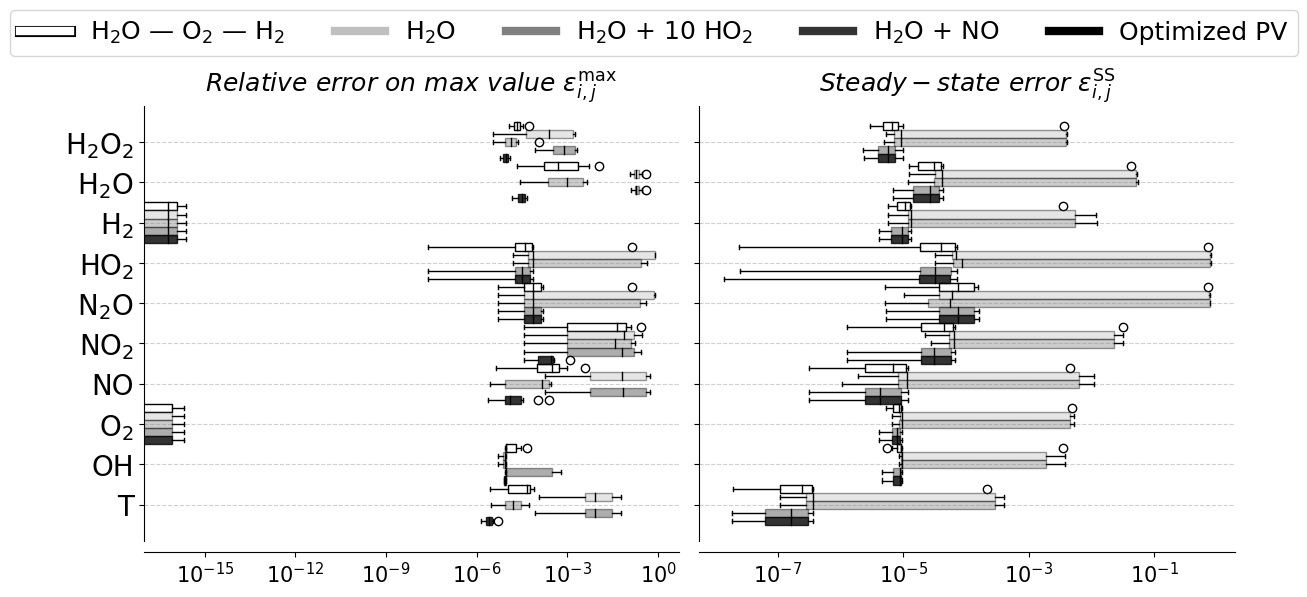

In [74]:
save = True
name = "Suppl. mat. - Boxplots max and SS error - tabulation a posteriori 0D.png"
namePdf = "Suppl. mat. - Boxplots max and SS error - tabulation a posteriori 0D.pdf"
pathSave = "C:/Users/admin/Documents/PhD-ULB/Figures/2024-PV-optimization/Paper/EnergyAndAI/Supplementary-material/A posteriori/Tabulation/"

# --- Prepare data ---
qois = list(results.keys())
n_qoi = len(qois)

# Collect errors in the order of QoIs
SS_heu = [errors_last_heuristic[qoi] for qoi in qois]
SS_heuSophH2O = [errors_last_heuSophH2O[qoi] for qoi in qois]
SS_heuSoph10HO2 = [errors_last_heuSoph10HO2[qoi] for qoi in qois]
SS_heuSoph1NO = [errors_last_heuSoph1NO[qoi] for qoi in qois]
SS_opt = [errors_last_optimized[qoi] for qoi in qois]
max_heu   = [errors_max_heuristic[qoi] for qoi in qois]
max_heuSophH2O   = [errors_max_heuSophH2O[qoi] for qoi in qois]
max_heuSoph10HO2   = [errors_max_heuSoph10HO2[qoi] for qoi in qois]
max_heuSoph1NO   = [errors_max_heuSoph1NO[qoi] for qoi in qois]
max_opt   = [errors_max_optimized[qoi] for qoi in qois]

# Positions for horizontal boxplots
y_pos = np.arange(n_qoi)
width = 0.2  # distance between boxes

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)

# --- Left subplot: Last error ---
for i in range(n_qoi):
    axes[0].boxplot(max_heu[i], positions=[y_pos[i] + 2*width], vert=False, widths=width, patch_artist=True,
                    boxprops=dict(facecolor='1', alpha=1),
                    medianprops=dict(color='black'))
    axes[0].boxplot(max_heuSophH2O[i], positions=[y_pos[i] + width], vert=False, widths=width, patch_artist=True,
                    boxprops=dict(facecolor='0.75', alpha=0.4),
                    medianprops=dict(color='black'))
    axes[0].boxplot(max_heuSoph10HO2[i], positions=[y_pos[i]], vert=False, widths=width, patch_artist=True,
                    boxprops=dict(facecolor='0.5', alpha=0.4),
                    medianprops=dict(color='black'))
    axes[0].boxplot(max_heuSoph1NO[i], positions=[y_pos[i] - width], vert=False, widths=width, patch_artist=True,
                    boxprops=dict(facecolor='0.2', alpha=0.4),
                    medianprops=dict(color='black'))
    axes[0].boxplot(max_opt[i], positions=[y_pos[i] - 2*width], vert=False, widths=width, patch_artist=True,
                    boxprops=dict(facecolor='black', alpha=0.8),
                    medianprops=dict(color='black'))

axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(qois)
axes[0].set_title(r"$\mathit{Relative\ error\ on\ max\ value}\ \varepsilon^{\max}_{i,j}$", fontsize = 18)
axes[0].set_xscale("log")
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

# --- Right subplot: Steady-state error ---
for i in range(n_qoi):
    axes[1].boxplot(SS_heu[i], positions=[y_pos[i] + 2*width], vert=False, widths=width, patch_artist=True,
                    boxprops=dict(facecolor='1', alpha=1),
                    medianprops=dict(color='black'))
    axes[1].boxplot(SS_heuSophH2O[i], positions=[y_pos[i] + width], vert=False, widths=width, patch_artist=True,
                    boxprops=dict(facecolor='0.75', alpha=0.4),
                    medianprops=dict(color='black'))
    axes[1].boxplot(SS_heuSoph10HO2[i], positions=[y_pos[i]], vert=False, widths=width, patch_artist=True,
                    boxprops=dict(facecolor='0.5', alpha=0.4),
                    medianprops=dict(color='black'))
    axes[1].boxplot(SS_heuSoph1NO[i], positions=[y_pos[i] - width], vert=False, widths=width, patch_artist=True,
                    boxprops=dict(facecolor='0.2', alpha=0.4),
                    medianprops=dict(color='black'))
    axes[1].boxplot(SS_opt[i], positions=[y_pos[i] - 2*width], vert=False, widths=width, patch_artist=True,
                    boxprops=dict(facecolor='black', alpha=0.8),
                    medianprops=dict(color='black'))

axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([q.replace("2", "$_2$") for q in qois[::-1]])
axes[1].set_title(r"$\mathit{Steady-state\ error}\ \varepsilon^{\mathrm{SS}}_{i,j}$", fontsize = 18)
axes[1].set_xscale("log")
axes[0].tick_params(axis='both', labelsize=20)  # y-tick labels
axes[0].tick_params(axis='x', labelsize=15)
axes[1].tick_params(axis='x', labelsize=15)
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

for i in range(len(axes)):
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

offset = 8

axes[0].spines['bottom'].set_position(('outward', offset))
axes[1].spines['bottom'].set_position(('outward', offset))

# --- Legend ---
handles = [
    (
        mlines.Line2D([0], [0], color='black', lw=8),   # border (thicker)
        mlines.Line2D([0], [0], color='1', lw=6)        # inner line
    ),
    mlines.Line2D([0], [0], color='0.75', lw=6),
    mlines.Line2D([0], [0], color='0.5', lw=6),
    mlines.Line2D([0], [0], color='0.2', lw=6),
    mlines.Line2D([0], [0], color='black', lw=6)
]

labels = ['H$_2$O \u2014 O$_2$ \u2014 H$_2$', 'H$_2$O', 'H$_2$O + 10 HO$_2$', 'H$_2$O + NO', 'Optimized PV']

# Add legend to the figure (not tied to any subplot)
fig.legend(handles, labels, bbox_to_anchor=(1.05, 1.1), ncol=5, fontsize=18)

plt.tight_layout()
if save:
    plt.savefig(pathSave + name, bbox_inches = "tight", dpi = 300)
    plt.savefig(pathSave + namePdf, bbox_inches = "tight")
plt.show()